[KNN](#knn) | [Random Forest](#rf) | [Extreme Gradient Boosting](#xgboost) | [Comparison and Feature Importance](#comparison)

<a id="knn"></a>
# K-Nearest Neighbors (KNN)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import sklearn
from sklearn.neighbors import KNeighborsClassifier as KNN
import pandas as pd
import os
import sys

Best binary KNN params: {'knn__n_neighbors': 31, 'knn__p': 2, 'knn__weights': 'uniform'} | best CV score: 0.9862
Best multiclass KNN params: {'knn__n_neighbors': 1, 'knn__p': 2, 'knn__weights': 'uniform'} | best CV score: 0.45

Top metrics for kilonova vs non-kilonova:


,metric,balanced_acc_mean,balanced_acc_std,roc_auc_mean,roc_auc_std
0,ztfi_fade_rate,0.784277,0.094889,0.795976,0.109673
1,ztfg_peak_mag,0.775714,0.056170,0.952442,0.027813
2,ztfi_peak_ri_color,0.763984,0.079909,0.903963,0.076101
3,ztfg_peak_gi_color,0.763529,0.079491,0.890589,0.087105
4,ztfi_peak_gi_color,0.763529,0.080133,0.942349,0.046179
5,ztfr_peak_ri_color,0.762848,0.080981,0.868749,0.066883
6,ztfi_peak_mag,0.762620,0.080936,0.941108,0.027896
7,ztfg_fwhm,0.741905,0.101134,0.896050,0.058727
8,ztfr_fwhm,0.740952,0.064583,0.909850,0.039355
9,ztfr_peak_gr_color,0.708160,0.094813,0.879784,0.044370



Top metrics for all-type grouping (rare classes collapsed to 'Other'):


,metric,balanced_acc_mean,balanced_acc_std,f1_macro_mean,f1_macro_std
0,ztfg_peak_mag,0.543027,0.064890,0.522845,0.045798
1,ztfr_peak_mag,0.517742,0.118083,0.481385,0.098101
2,ztfi_peak_mag,0.320871,0.024267,0.280870,0.012164
3,ztfr_fade_hwhm,0.271024,0.078435,0.261918,0.077571
4,ztfg_fwhm,0.247811,0.031395,0.211029,0.012946
5,ztfr_fwhm,0.246825,0.060056,0.249151,0.061669
6,ztfr_peak_gr_color,0.216994,0.036069,0.205466,0.014838
7,ztfi_fwhm,0.200408,0.032611,0.124449,0.040067
8,ztfi_peak_gi_color,0.198864,0.000279,0.112625,0.001236
9,ztfi_fade_hwhm,0.191355,0.042501,0.149166,0.022664


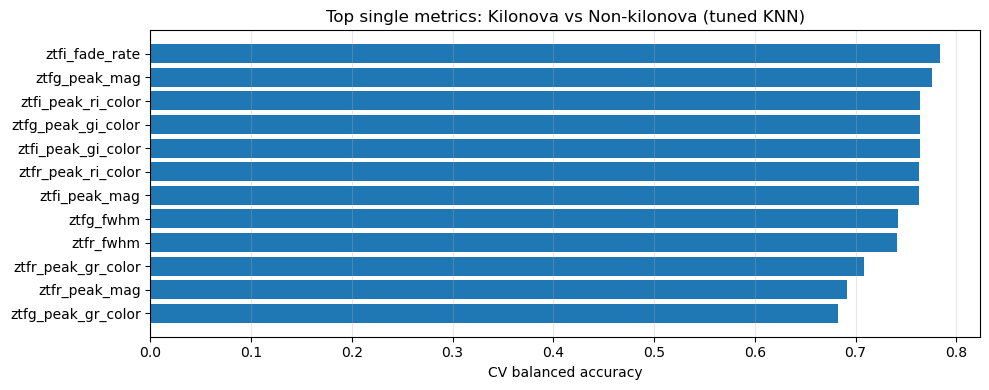

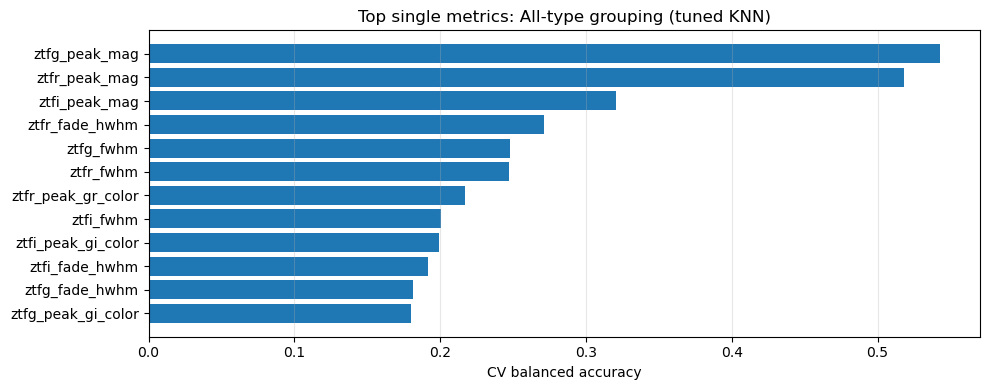

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Ensure data exists (reuse if already loaded)
if "gp" not in globals():
    gp = pd.read_csv(os.path.join("data", "gp_objects_rates.csv"))
    gp = gp.drop(columns=[col for col in gp.columns if "peak_time" in str(col)], errors="ignore")
if "bulla" not in globals():
    bulla = pd.read_csv(os.path.join("data", "bulla_2019_rates.csv"))
    bulla = bulla.drop(columns=[col for col in bulla.columns if "peak_time" in str(col)], errors="ignore")

# Shared numeric metrics
common_numeric = sorted(
    set(gp.select_dtypes(include=np.number).columns)
    & set(bulla.select_dtypes(include=np.number).columns)
)
if not common_numeric:
    raise ValueError("No shared numeric columns found.")

# Binary label: kilonova (1) vs not kilonova (0)
gp_is_kilonova = gp["type"].astype(str).str.contains("kilonova", case=False, na=False).astype(int)
bulla_is_kilonova = np.ones(len(bulla), dtype=int)

X_all = pd.concat([gp[common_numeric], bulla[common_numeric]], ignore_index=True)
y_bin = np.r_[gp_is_kilonova.values, bulla_is_kilonova]

# Multiclass labels for "all types" grouping
all_types = pd.concat(
    [gp["type"].fillna("Unknown"), pd.Series(["bulla_kilonova_model"] * len(bulla))],
    ignore_index=True
)

# Collapse rare classes to avoid unstable CV
min_support = 3
type_counts = all_types.value_counts()
y_multi = all_types.where(all_types.map(type_counts) >= min_support, "Other")

def make_cv(y, max_splits=5):
    min_count = pd.Series(y).value_counts().min()
    n_splits = max(2, min(max_splits, int(min_count)))
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

def tune_knn(X_df, y, mode="binary"):
    cv = make_cv(y)
    max_k = min(31, len(X_df) - 1)
    k_grid = sorted(set([k for k in range(1, max_k + 1, 2)]))  # odd k
    
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("knn", KNN())
    ])
    
    param_grid = {
        "knn__n_neighbors": k_grid,
        "knn__weights": ["uniform", "distance"],
        "knn__p": [1, 2],  # Manhattan / Euclidean
    }
    
    scoring = "roc_auc" if mode == "binary" else "balanced_accuracy"
    
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    gs.fit(X_df, y)
    return gs.best_params_, gs.best_score_

def feature_scores(X_df, y, knn_params, mode="binary"):
    rows = []
    cv = make_cv(y)

    for col in X_df.columns:
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("knn", KNN(
                n_neighbors=knn_params["knn__n_neighbors"],
                weights=knn_params["knn__weights"],
                p=knn_params["knn__p"]
            ))
        ])

        Xi = X_df[[col]]

        if mode == "binary":
            bal = cross_val_score(pipe, Xi, y, cv=cv, scoring="balanced_accuracy")
            auc = cross_val_score(pipe, Xi, y, cv=cv, scoring="roc_auc")
            rows.append({
                "metric": col,
                "balanced_acc_mean": bal.mean(),
                "balanced_acc_std": bal.std(),
                "roc_auc_mean": auc.mean(),
                "roc_auc_std": auc.std()
            })
        else:
            bal = cross_val_score(pipe, Xi, y, cv=cv, scoring="balanced_accuracy")
            f1m = cross_val_score(pipe, Xi, y, cv=cv, scoring="f1_macro")
            rows.append({
                "metric": col,
                "balanced_acc_mean": bal.mean(),
                "balanced_acc_std": bal.std(),
                "f1_macro_mean": f1m.mean(),
                "f1_macro_std": f1m.std()
            })

    return pd.DataFrame(rows).sort_values("balanced_acc_mean", ascending=False).reset_index(drop=True)

# Tune KNN hyperparameters once per task
best_bin_params, best_bin_score = tune_knn(X_all[common_numeric], y_bin, mode="binary")
best_multi_params, best_multi_score = tune_knn(X_all[common_numeric], y_multi, mode="multiclass")

print("Best binary KNN params:", best_bin_params, "| best CV score:", round(best_bin_score, 4))
print("Best multiclass KNN params:", best_multi_params, "| best CV score:", round(best_multi_score, 4))

# 1) Binary discrimination quality per metric (using tuned KNN)
binary_results = feature_scores(X_all[common_numeric], y_bin, best_bin_params, mode="binary")
print("\nTop metrics for kilonova vs non-kilonova:")
display(binary_results.head(15))

# 2) All-type grouping quality per metric (using tuned KNN)
multi_results = feature_scores(X_all[common_numeric], y_multi, best_multi_params, mode="multiclass")
print("\nTop metrics for all-type grouping (rare classes collapsed to 'Other'):")
display(multi_results.head(15))

# Plot top metric rankings
top_n = 12

plt.figure(figsize=(10, 4))
tmp = binary_results.head(top_n).iloc[::-1]
plt.barh(tmp["metric"], tmp["balanced_acc_mean"])
plt.xlabel("CV balanced accuracy")
plt.title("Top single metrics: Kilonova vs Non-kilonova (tuned KNN)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
tmp = multi_results.head(top_n).iloc[::-1]
plt.barh(tmp["metric"], tmp["balanced_acc_mean"])
plt.xlabel("CV balanced accuracy")
plt.title("Top single metrics: All-type grouping (tuned KNN)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Augmenting data

In [11]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, f1_score
from scipy.stats import ttest_rel

def bootstrap_oversample(X_train, y_train, random_state=42):
    """
    Class-conditional bootstrap oversampling:
    resample each class with replacement up to the majority class size.
    """
    rng = np.random.default_rng(random_state)
    y_train = np.asarray(y_train)
    classes, counts = np.unique(y_train, return_counts=True)
    target_n = counts.max()

    idx_all = []
    for c in classes:
        idx_c = np.where(y_train == c)[0]
        sampled = rng.choice(idx_c, size=target_n, replace=True)
        idx_all.append(sampled)

    idx_all = np.concatenate(idx_all)
    rng.shuffle(idx_all)
    return X_train.iloc[idx_all], y_train[idx_all]

def make_repeated_cv(y, max_splits=5, n_repeats=5, random_state=42):
    min_count = pd.Series(y).value_counts().min()
    n_splits = max(2, min(max_splits, int(min_count)))
    return RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)

def evaluate_feature_augmented(X_df, y, feature, mode="binary", cv=None, seed=42):
    y = np.asarray(y)
    X1 = X_df[[feature]]

    base_scores_main, aug_scores_main = [], []
    base_scores_aux, aug_scores_aux = [], []

    for fold_i, (tr, te) in enumerate(cv.split(X1, y)):
        X_tr, X_te = X1.iloc[tr], X1.iloc[te]
        y_tr, y_te = y[tr], y[te]

        base_model = sklearn.pipeline.make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            KNN(n_neighbors=k)
        )
        aug_model = sklearn.pipeline.make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            KNN(n_neighbors=k)
        )

        # Baseline fit
        base_model.fit(X_tr, y_tr)
        yhat_base = base_model.predict(X_te)
        base_scores_main.append(balanced_accuracy_score(y_te, yhat_base))

        # Augmented fit (train fold only -> no leakage)
        X_aug, y_aug = bootstrap_oversample(X_tr, y_tr, random_state=seed + fold_i)
        aug_model.fit(X_aug, y_aug)
        yhat_aug = aug_model.predict(X_te)
        aug_scores_main.append(balanced_accuracy_score(y_te, yhat_aug))

        if mode == "binary":
            p_base = base_model.predict_proba(X_te)[:, 1]
            p_aug = aug_model.predict_proba(X_te)[:, 1]
            base_scores_aux.append(roc_auc_score(y_te, p_base))
            aug_scores_aux.append(roc_auc_score(y_te, p_aug))
        else:
            base_scores_aux.append(f1_score(y_te, yhat_base, average="macro"))
            aug_scores_aux.append(f1_score(y_te, yhat_aug, average="macro"))

    base_scores_main = np.array(base_scores_main, dtype=float)
    aug_scores_main = np.array(aug_scores_main, dtype=float)
    base_scores_aux = np.array(base_scores_aux, dtype=float)
    aug_scores_aux = np.array(aug_scores_aux, dtype=float)

    p_main = ttest_rel(aug_scores_main, base_scores_main, nan_policy="omit").pvalue
    p_aux = ttest_rel(aug_scores_aux, base_scores_aux, nan_policy="omit").pvalue

    out = {
        "metric": feature,
        "base_bal_acc_mean": np.nanmean(base_scores_main),
        "aug_bal_acc_mean": np.nanmean(aug_scores_main),
        "delta_bal_acc": np.nanmean(aug_scores_main - base_scores_main),
        "p_bal_acc": p_main
    }

    if mode == "binary":
        out.update({
            "base_roc_auc_mean": np.nanmean(base_scores_aux),
            "aug_roc_auc_mean": np.nanmean(aug_scores_aux),
            "delta_roc_auc": np.nanmean(aug_scores_aux - base_scores_aux),
            "p_roc_auc": p_aux
        })
    else:
        out.update({
            "base_f1_macro_mean": np.nanmean(base_scores_aux),
            "aug_f1_macro_mean": np.nanmean(aug_scores_aux),
            "delta_f1_macro": np.nanmean(aug_scores_aux - base_scores_aux),
            "p_f1_macro": p_aux
        })

    return out

# --- Binary: kilonova vs non-kilonova ---
max_splits = 5
cv_bin = make_repeated_cv(y_bin, max_splits=max_splits, n_repeats=5, random_state=42)
# Use tuned binary K for the single-feature binary evaluation
k = int(best_bin_params.get("knn__n_neighbors", 5))

binary_aug_rows = [
    evaluate_feature_augmented(X_all, y_bin, col, mode="binary", cv=cv_bin, seed=42)
    for col in common_numeric
]
binary_aug_results = pd.DataFrame(binary_aug_rows).sort_values(
    "aug_bal_acc_mean", ascending=False
).reset_index(drop=True)

print("Top single-feature metrics (binary) with bootstrap augmentation:")
display(binary_aug_results.head(15))

# --- Multiclass: all types (with y_multi already collapsed) ---
cv_multi = make_repeated_cv(y_multi, max_splits=max_splits, n_repeats=5, random_state=42)
multi_aug_rows = [
    evaluate_feature_augmented(X_all, y_multi.values, col, mode="multiclass", cv=cv_multi, seed=123)
    for col in common_numeric
]
multi_aug_results = pd.DataFrame(multi_aug_rows).sort_values(
    "aug_bal_acc_mean", ascending=False
).reset_index(drop=True)

print("Top single-feature metrics (multiclass) with bootstrap augmentation:")
display(multi_aug_results.head(15))

Top single-feature metrics (binary) with bootstrap augmentation:


,metric,base_bal_acc_mean,aug_bal_acc_mean,delta_bal_acc,p_bal_acc,base_roc_auc_mean,aug_roc_auc_mean,delta_roc_auc,p_roc_auc
0,ztfg_peak_mag,0.780190,0.917088,0.136898,1.502033e-10,0.952010,0.949466,-0.002544,4.354784e-01
1,ztfg_fwhm,0.742762,0.916856,0.174094,1.806992e-12,0.893453,0.898444,0.004991,3.702304e-01
2,ztfr_fwhm,0.728762,0.910624,0.181862,3.986404e-11,0.912612,0.911275,-0.001337,7.569244e-01
3,ztfg_fade_hwhm,0.646762,0.909644,0.262882,1.710124e-18,0.849323,0.895244,0.045921,2.724088e-06
4,ztfi_peak_mag,0.763394,0.897474,0.134080,8.835509e-10,0.941837,0.947439,0.005602,6.681746e-03
5,ztfr_fade_hwhm,0.645143,0.893009,0.247866,6.478941e-17,0.834859,0.885628,0.050769,3.013049e-06
6,ztfi_peak_gi_color,0.762984,0.882965,0.119981,1.994724e-11,0.939957,0.938460,-0.001497,6.180023e-01
7,ztfr_peak_mag,0.703524,0.862129,0.158605,7.721241e-09,0.924610,0.919610,-0.005000,1.462483e-02
8,ztfr_peak_gr_color,0.705394,0.860775,0.155381,6.956661e-11,0.891601,0.891860,0.000259,9.343891e-01
9,ztfi_peak_ri_color,0.763439,0.833393,0.069954,2.219017e-06,0.897473,0.893868,-0.003605,1.835393e-01


Top single-feature metrics (multiclass) with bootstrap augmentation:


,metric,base_bal_acc_mean,aug_bal_acc_mean,delta_bal_acc,p_bal_acc,base_f1_macro_mean,aug_f1_macro_mean,delta_f1_macro,p_f1_macro
0,ztfg_peak_mag,0.147619,0.524419,0.376800,4.771828e-12,0.136007,0.475581,0.339574,1.451607e-11
1,ztfr_peak_mag,0.100000,0.506769,0.406769,1.136764e-10,0.098562,0.415857,0.317295,5.181924e-11
2,ztfr_fade_rate,0.100000,0.291118,0.191118,1.453071e-08,0.098390,0.164141,0.065751,2.176484e-08
3,ztfg_fade_hwhm,0.104762,0.278867,0.174105,5.901366e-09,0.104954,0.263615,0.158661,4.893902e-09
4,ztfr_fade_hwhm,0.102857,0.278817,0.175960,1.752625e-06,0.102614,0.270821,0.168207,1.389818e-07
5,ztfi_peak_mag,0.159382,0.262071,0.102689,3.637218e-04,0.133400,0.188542,0.055142,2.195682e-03
6,ztfr_peak_gr_color,0.107619,0.259239,0.151620,1.118461e-07,0.105786,0.163719,0.057933,5.875566e-06
7,ztfg_fwhm,0.143810,0.250749,0.106940,3.344779e-05,0.139540,0.239326,0.099786,4.402821e-05
8,ztfr_fwhm,0.139048,0.249095,0.110047,8.697345e-06,0.139740,0.203829,0.064088,1.719584e-04
9,ztfi_fade_rate,0.165994,0.217480,0.051486,1.794734e-03,0.135452,0.112069,-0.023383,2.275255e-06


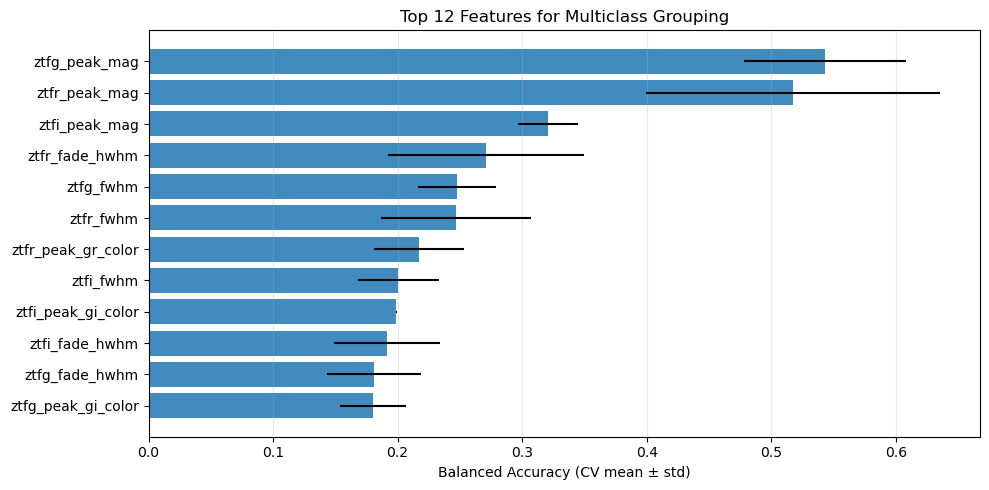

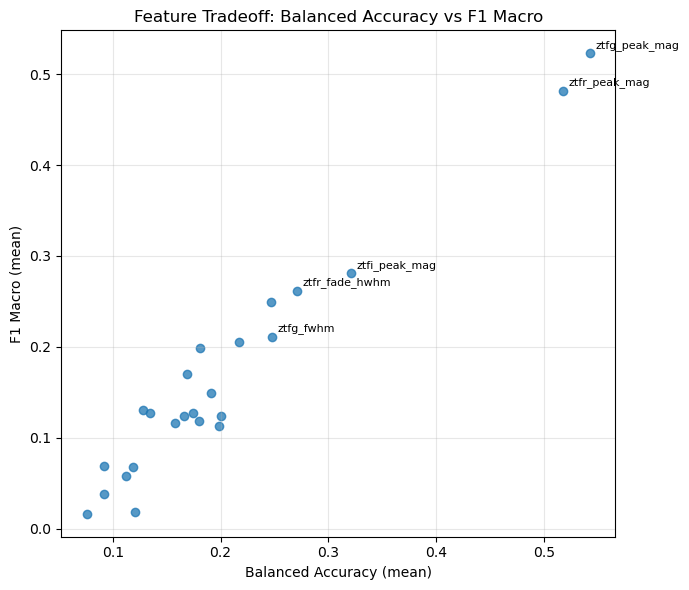

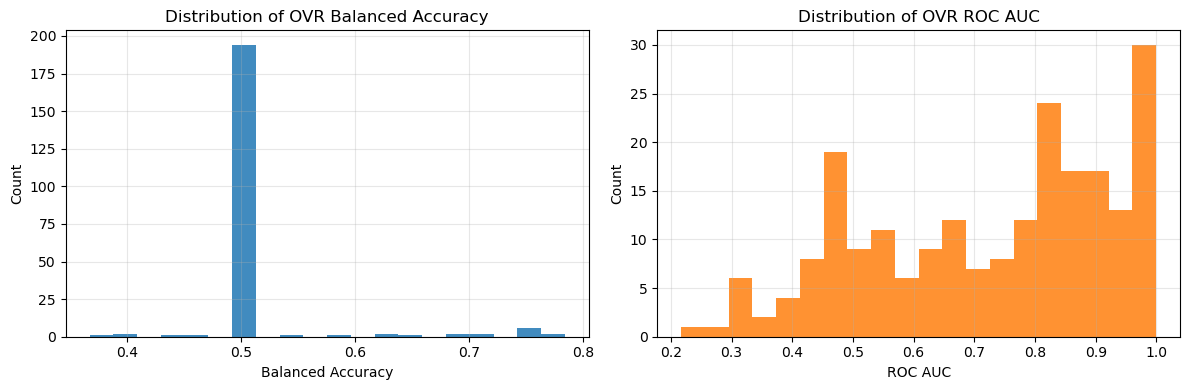

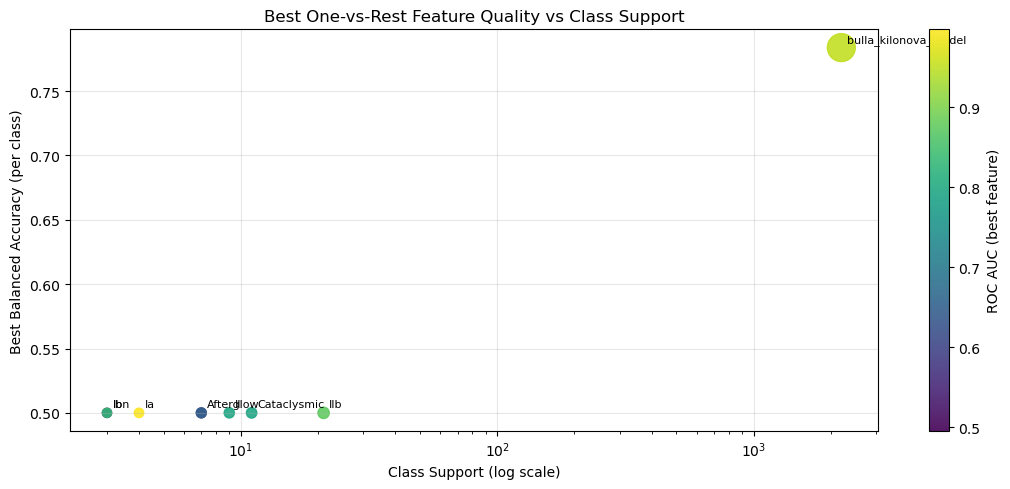

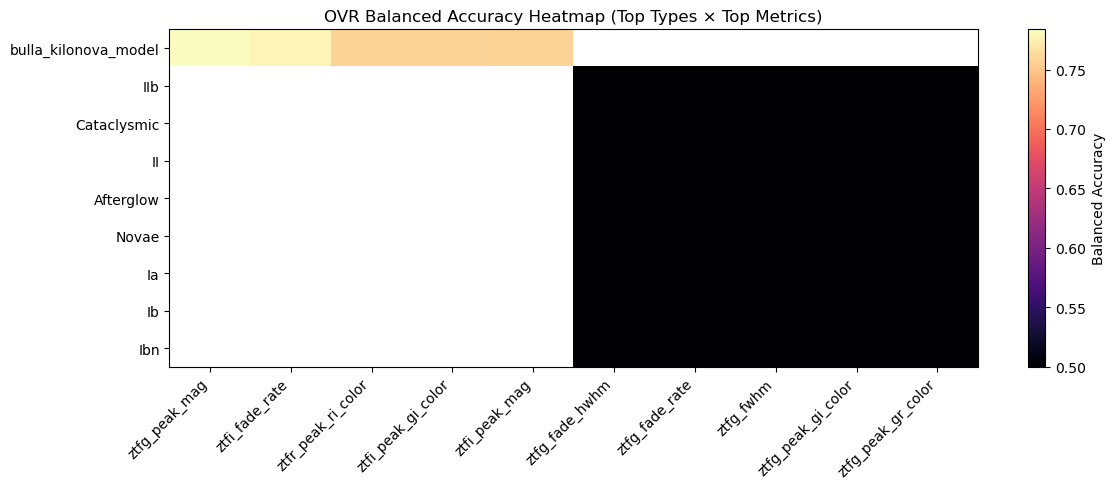

In [12]:
# Informative plots for multiclass and one-vs-rest feature analysis
# Reuses existing variables: multi_results, ovr_feature_results, top_discriminators_by_type, type_counts

if "multi_results" not in globals() or "ovr_feature_results" not in globals():
    missing = []

    if "multi_results" not in globals():
        if "multi_aug_results" in globals():
            multi_results = multi_aug_results.rename(
                columns={
                    "aug_bal_acc_mean": "balanced_acc_mean",
                    "aug_f1_macro_mean": "f1_macro_mean",
                }
            ).copy()
            multi_results["balanced_acc_std"] = np.nan
            multi_results["f1_macro_std"] = np.nan
            multi_results = multi_results[
                ["metric", "balanced_acc_mean", "balanced_acc_std", "f1_macro_mean", "f1_macro_std"]
            ].sort_values("balanced_acc_mean", ascending=False).reset_index(drop=True)
        else:
            missing.append("multi_results")

    if "ovr_feature_results" not in globals():
        if "top_discriminators_by_type" in globals():
            ovr_feature_results = top_discriminators_by_type.copy()
        elif "multi_results" in globals() and "type_counts" in globals():
            top_types = list(type_counts.index[: min(8, len(type_counts))])
            top_feats = multi_results.head(min(12, len(multi_results)))

            rows = []
            for obj_type in top_types:
                support = int(type_counts.loc[obj_type])
                for _, r in top_feats.iterrows():
                    rows.append(
                        {
                            "object_type": obj_type,
                            "support": support,
                            "metric": r["metric"],
                            "balanced_acc_mean": float(r["balanced_acc_mean"]),
                            "roc_auc_mean": np.nan,
                        }
                    )

            ovr_feature_results = pd.DataFrame(rows)
            top_discriminators_by_type = ovr_feature_results.copy()
        else:
            missing.append("ovr_feature_results")

    if "top_discriminators_by_type" not in globals() and "ovr_feature_results" in globals():
        top_discriminators_by_type = ovr_feature_results.copy()

    if missing:
        raise ValueError(
            f"Required variables are not available in the notebook state: {', '.join(missing)}"
        )

# ---------- Plot 1: Top multiclass single-feature metrics ----------
top_k = 12
mr_top = multi_results.head(top_k).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(mr_top["metric"], mr_top["balanced_acc_mean"], xerr=mr_top["balanced_acc_std"], alpha=0.85)
ax.set_xlabel("Balanced Accuracy (CV mean ± std)")
ax.set_title(f"Top {top_k} Features for Multiclass Grouping")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- Plot 2: Balanced accuracy vs F1-macro tradeoff ----------
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(multi_results["balanced_acc_mean"], multi_results["f1_macro_mean"], alpha=0.75)
ax.set_xlabel("Balanced Accuracy (mean)")
ax.set_ylabel("F1 Macro (mean)")
ax.set_title("Feature Tradeoff: Balanced Accuracy vs F1 Macro")
ax.grid(alpha=0.3)

# annotate top 5 by balanced accuracy
for _, r in multi_results.head(5).iterrows():
    ax.annotate(r["metric"], (r["balanced_acc_mean"], r["f1_macro_mean"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.show()

# ---------- Plot 3: OVR score distributions ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ovr_feature_results["balanced_acc_mean"].dropna(), bins=20, alpha=0.85)
axes[0].set_title("Distribution of OVR Balanced Accuracy")
axes[0].set_xlabel("Balanced Accuracy")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.3)

axes[1].hist(ovr_feature_results["roc_auc_mean"].dropna(), bins=20, alpha=0.85, color="tab:orange")
axes[1].set_title("Distribution of OVR ROC AUC")
axes[1].set_xlabel("ROC AUC")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- Plot 4: Best feature per class vs support ----------
best_per_type = (
    ovr_feature_results.sort_values(["object_type", "balanced_acc_mean"], ascending=[True, False])
    .groupby("object_type", as_index=False)
    .first()[["object_type", "support", "metric", "balanced_acc_mean", "roc_auc_mean"]]
    .sort_values("balanced_acc_mean", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(11, 5))
sizes = 30 + 8 * np.sqrt(best_per_type["support"].values)
sc = ax.scatter(
    best_per_type["support"],
    best_per_type["balanced_acc_mean"],
    s=sizes,
    c=best_per_type["roc_auc_mean"],
    cmap="viridis",
    alpha=0.9
)
ax.set_xscale("log")
ax.set_xlabel("Class Support (log scale)")
ax.set_ylabel("Best Balanced Accuracy (per class)")
ax.set_title("Best One-vs-Rest Feature Quality vs Class Support")
ax.grid(alpha=0.3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("ROC AUC (best feature)")

for _, r in best_per_type.head(8).iterrows():
    ax.annotate(r["object_type"], (r["support"], r["balanced_acc_mean"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.show()

# ---------- Plot 5: Heatmap of top discriminators by object type ----------
td = top_discriminators_by_type.copy()
types_order = (
    td.groupby("object_type")["support"].max()
    .sort_values(ascending=False)
    .head(10)
    .index
)
metrics_order = (
    td.groupby("metric")["balanced_acc_mean"].mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

heat = (
    td[td["object_type"].isin(types_order) & td["metric"].isin(metrics_order)]
    .pivot_table(index="object_type", columns="metric", values="balanced_acc_mean", aggfunc="mean")
    .reindex(index=types_order, columns=metrics_order)
)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heat.values, aspect="auto", cmap="magma", vmin=np.nanmin(heat.values), vmax=np.nanmax(heat.values))
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("OVR Balanced Accuracy Heatmap (Top Types × Top Metrics)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Balanced Accuracy")

plt.tight_layout()
plt.show()

Generated 220 randomized second-order metrics.

Top randomized second-order metrics (multiclass, early-aware utility):


,feature,expr,template,early_score,balanced_acc_mean,f1_macro_mean,utility_score
0,so_182,ztfr_rise_rate/|ztfi_rise_rate|,ratio,0.950,0.136496,0.061000,0.250496
1,so_199,ztfi_peak_gi_color/|ztfg_peak_gi_color|,ratio,0.700,0.166152,0.138650,0.250152
2,so_011,ztfg_peak_gr_color*ztfi_peak_gi_color,mul,0.700,0.166106,0.138255,0.250106
3,so_170,ztfg_peak_gi_color/|ztfr_peak_ri_color|,ratio,0.700,0.166076,0.137981,0.250076
4,so_102,ztfr_peak_ri_color*ztfi_peak_gi_color,mul,0.700,0.166045,0.138037,0.250045
5,so_037,ztfg_peak_gr_color/|ztfr_peak_ri_color|,ratio,0.700,0.166000,0.137418,0.250000
6,so_006,ztfi_peak_gi_color*ztfi_rise_rate,mul,0.825,0.147072,0.071430,0.246072
7,so_190,ztfi_peak_gi_color/|ztfi_rise_rate|,ratio,0.825,0.147072,0.071432,0.246072
8,so_155,ztfg_peak_gi_color/|ztfi_rise_rate|,ratio,0.825,0.146890,0.071261,0.245890
9,so_187,"harm(ztfg_peak_mag,ztfi_peak_gi_color)",harm_like,0.650,0.166197,0.140031,0.244197



Top randomized second-order metrics (binary, early-aware utility):


,feature,expr,template,early_score,balanced_acc_mean,roc_auc_mean,utility_score
0,so_179,(ztfg_peak_gr_color-ztfr_peak_mag)/|ztfg_fwhm|,diff_ratio,0.516667,0.838254,0.903396,0.900254
1,so_211,(ztfr_fwhm+ztfr_peak_mag)/|ztfg_fwhm|,sum_ratio,0.416667,0.833651,0.887541,0.883651
2,so_200,ztfg_peak_gr_color/|ztfr_fade_hwhm|,ratio,0.550000,0.787992,0.851095,0.853992
3,so_037,ztfg_peak_gr_color/|ztfr_peak_ri_color|,ratio,0.700000,0.766535,0.892482,0.850535
4,so_102,ztfr_peak_ri_color*ztfi_peak_gi_color,mul,0.700000,0.762833,0.863929,0.846833
5,so_011,ztfg_peak_gr_color*ztfi_peak_gi_color,mul,0.700000,0.762607,0.928608,0.846607
6,so_199,ztfi_peak_gi_color/|ztfg_peak_gi_color|,ratio,0.700000,0.762531,0.911873,0.846531
7,so_170,ztfg_peak_gi_color/|ztfr_peak_ri_color|,ratio,0.700000,0.762077,0.884124,0.846077
8,so_056,(ztfi_peak_mag-ztfi_fade_rate)/|ztfi_peak_ri_color|,diff_ratio,0.450000,0.791013,0.894511,0.845013
9,so_202,"harm(ztfi_peak_ri_color,ztfi_peak_mag)",harm_like,0.650000,0.765063,0.882640,0.843063


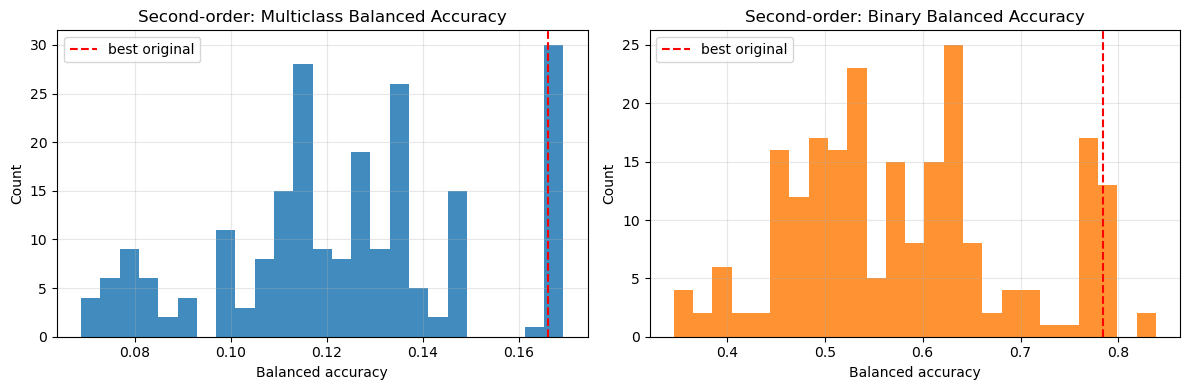

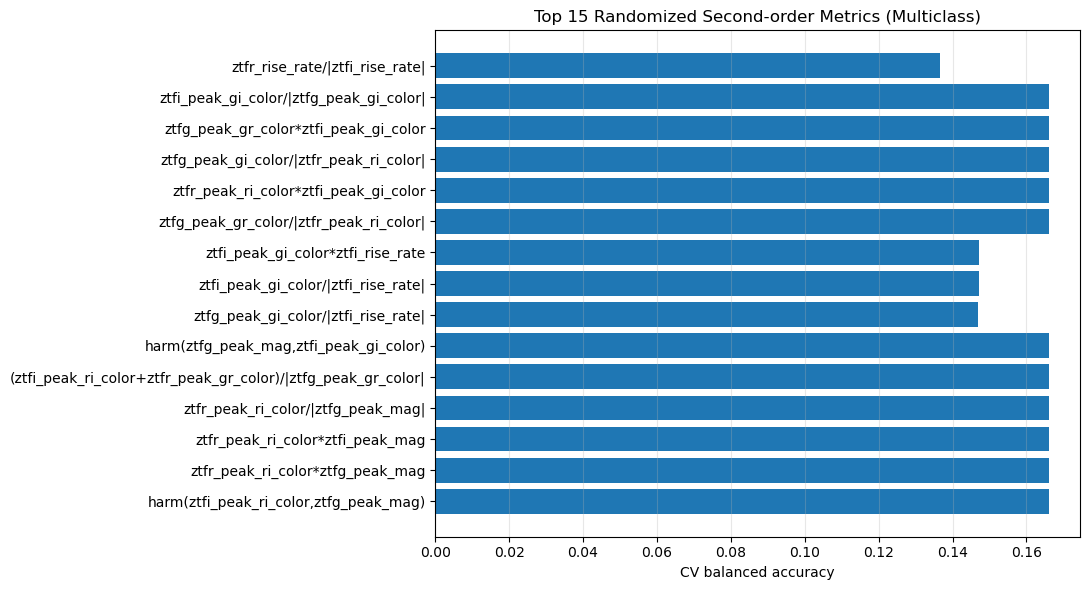

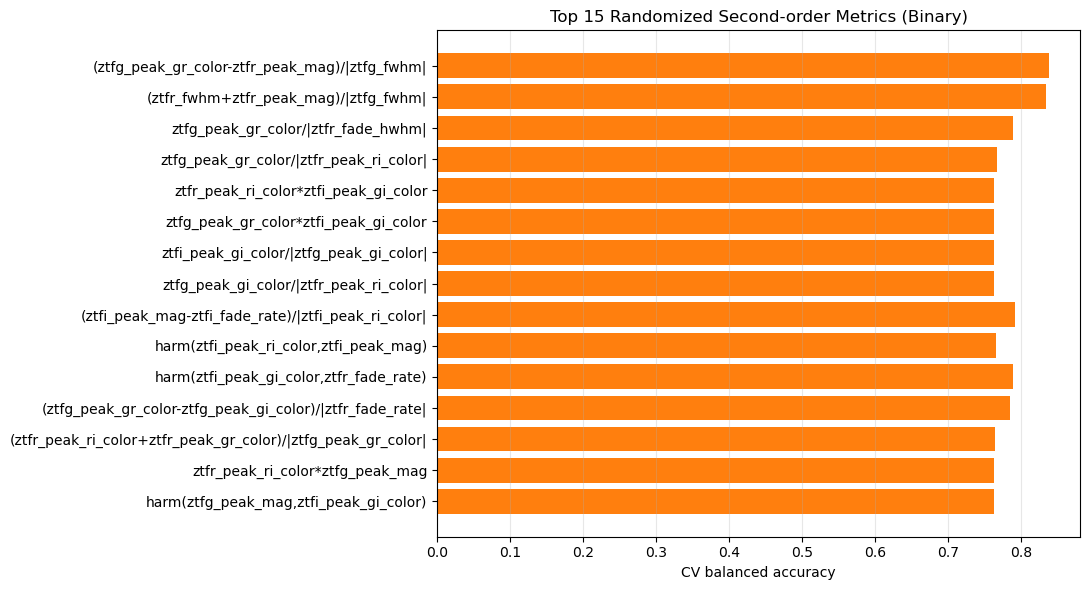

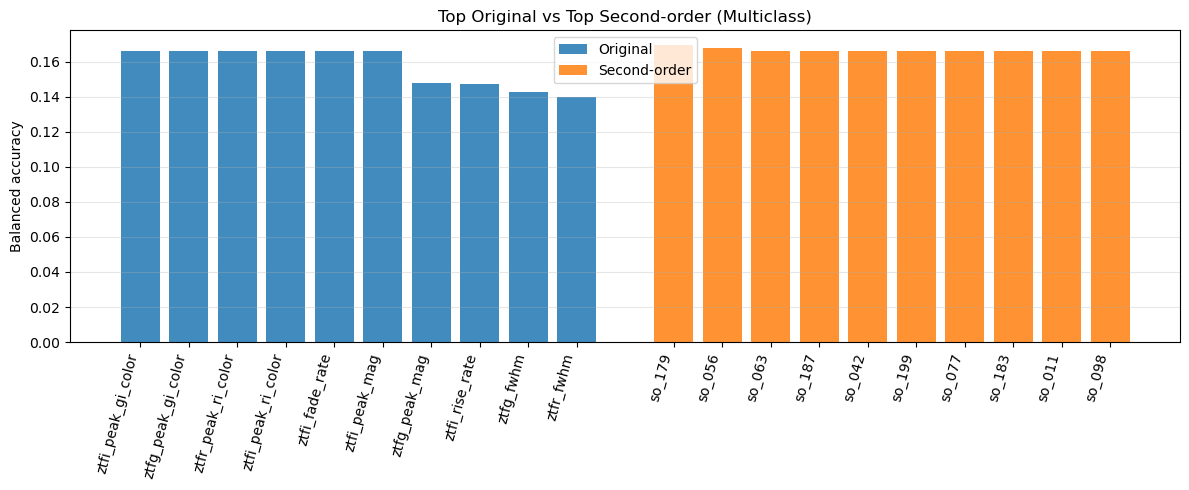

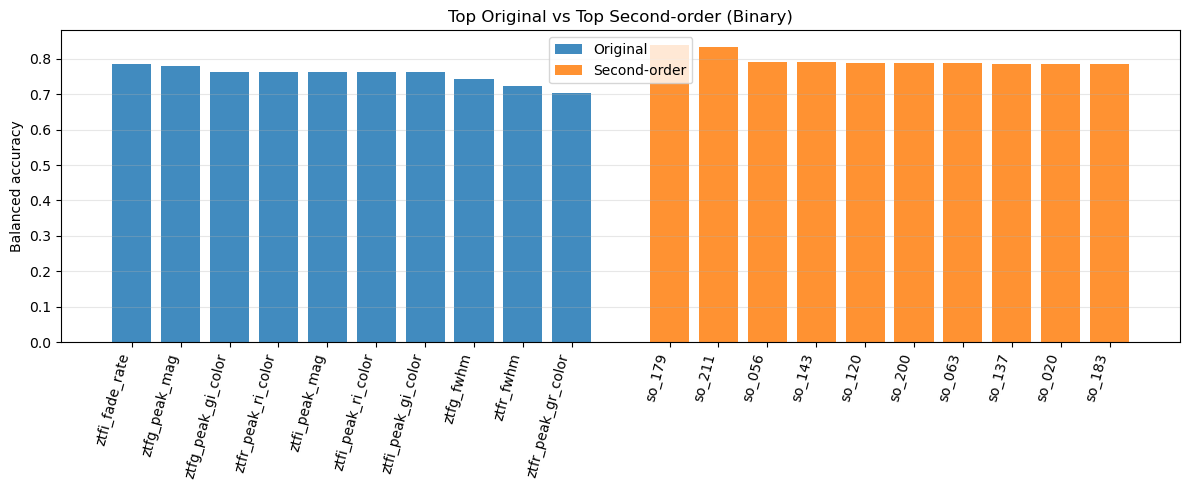

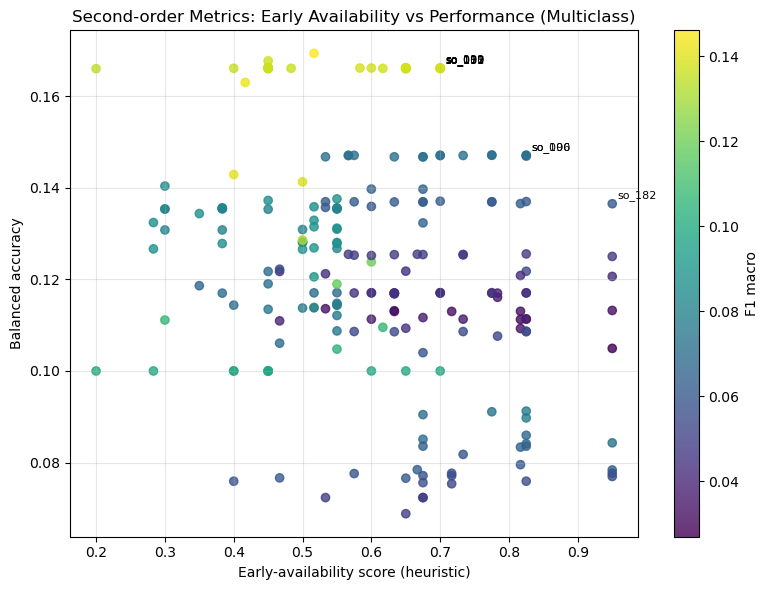

/var/folders/8_/ky643qs168ngjmhrpwcq1fdm0000gn/T/ipykernel_58070/3568226639.py:268: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


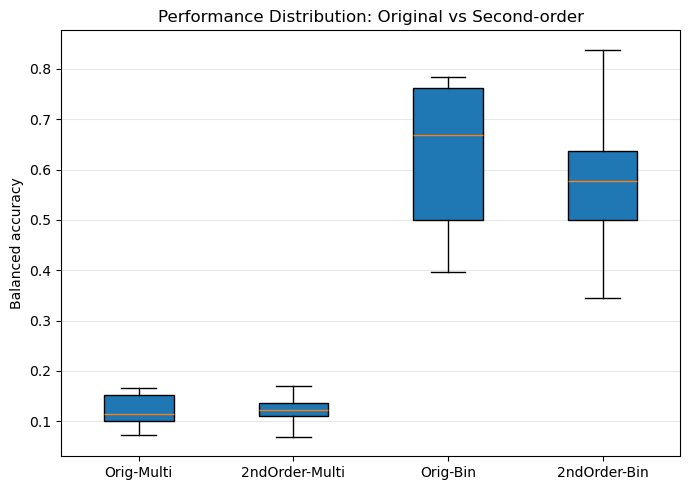

In [13]:
# -----------------------------
# 1) Build randomized 2nd-order metrics (no fragmentation)
# -----------------------------
rng = np.random.default_rng(2026)
eps = 1e-8
n_random_features = 220  # increase/decrease based on runtime budget

def metric_early_score(name: str) -> float:
    n = str(name).lower()
    if "rise" in n:
        return 1.0
    if "peak" in n and ("color" in n or "gr_color" in n or "gi_color" in n or "ri_color" in n):
        return 0.75
    if "peak" in n:
        return 0.65
    if "fwhm" in n or "hwhm" in n:
        return 0.45
    if "fade" in n:
        return 0.25
    return 0.5

templates = [
    ("mul",       lambda a, b, _c: a * b, 2),
    ("ratio",     lambda a, b, _c: a / (np.abs(b) + eps), 2),
    ("sum_ratio", lambda a, b, c: (a + b) / (np.abs(c) + eps), 3),
    ("diff_ratio",lambda a, b, c: (a - b) / (np.abs(c) + eps), 3),
    ("mul_ratio", lambda a, b, c: (a * b) / (np.abs(c) + eps), 3),
    ("harm_like", lambda a, b, _c: 2 * a * b / (np.abs(a) + np.abs(b) + eps), 2),
]

base = X_all[common_numeric].copy()
so_series = []
meta_rows = []
seen = set()

attempts = 0
max_attempts = n_random_features * 20

while len(so_series) < n_random_features and attempts < max_attempts:
    attempts += 1
    tname, tfunc, n_terms = templates[rng.integers(0, len(templates))]
    picked = list(rng.choice(common_numeric, size=n_terms, replace=False))
    key = (tname, tuple(sorted(picked)))
    if key in seen:
        continue
    seen.add(key)

    a = base[picked[0]].astype(float)
    b = base[picked[1]].astype(float)
    c = base[picked[2]].astype(float) if n_terms == 3 else pd.Series(1.0, index=base.index)

    feat = tfunc(a, b, c).replace([np.inf, -np.inf], np.nan)

    # skip near-constant / too sparse
    if feat.notna().sum() < 50:
        continue
    if np.nanstd(feat.values) < 1e-10:
        continue

    expr = (
        f"{picked[0]}*{picked[1]}" if tname == "mul" else
        f"{picked[0]}/|{picked[1]}|" if tname == "ratio" else
        f"({picked[0]}+{picked[1]})/|{picked[2]}|" if tname == "sum_ratio" else
        f"({picked[0]}-{picked[1]})/|{picked[2]}|" if tname == "diff_ratio" else
        f"({picked[0]}*{picked[1]})/|{picked[2]}|" if tname == "mul_ratio" else
        f"harm({picked[0]},{picked[1]})"
    )
    col = f"so_{len(so_series):03d}"

    so_series.append(feat.rename(col))
    early = np.mean([metric_early_score(m) for m in picked]) - 0.05 * (n_terms - 1)
    meta_rows.append(
        {
            "feature": col,
            "expr": expr,
            "template": tname,
            "n_terms": n_terms,
            "early_score": float(np.clip(early, 0, 1)),
        }
    )

second_order = pd.concat(so_series, axis=1) if so_series else pd.DataFrame(index=base.index)
so_meta = pd.DataFrame(meta_rows)

if second_order.shape[1] == 0:
    raise ValueError("No randomized second-order features were generated.")

print(f"Generated {second_order.shape[1]} randomized second-order metrics.")

# -----------------------------
# 2) Evaluate metrics (same style as prior analysis)
# -----------------------------
def make_cv_local(y, max_splits=5, n_repeats=3, random_state=42):
    if "make_repeated_cv" in globals():
        return make_repeated_cv(y, max_splits=max_splits, n_repeats=n_repeats, random_state=random_state)
    min_count = pd.Series(y).value_counts().min()
    n_splits = max(2, min(max_splits, int(min_count)))
    return sklearn.model_selection.RepeatedStratifiedKFold(
        n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
    )

def eval_single_feature_set(X_df, y, mode="binary", cv=None):
    rows = []
    for col in X_df.columns:
        Xi = X_df[[col]]
        pipe = sklearn.pipeline.make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            KNN(n_neighbors=k)
        )
        bal = cross_val_score(pipe, Xi, y, cv=cv, scoring="balanced_accuracy", error_score=np.nan)

        row = {
            "feature": col,
            "balanced_acc_mean": np.nanmean(bal),
            "balanced_acc_std": np.nanstd(bal)
        }

        if mode == "binary":
            aux = cross_val_score(pipe, Xi, y, cv=cv, scoring="roc_auc", error_score=np.nan)
            row["roc_auc_mean"] = np.nanmean(aux)
            row["roc_auc_std"] = np.nanstd(aux)
        else:
            aux = cross_val_score(pipe, Xi, y, cv=cv, scoring="f1_macro", error_score=np.nan)
            row["f1_macro_mean"] = np.nanmean(aux)
            row["f1_macro_std"] = np.nanstd(aux)

        rows.append(row)

    return pd.DataFrame(rows)

cv_bin = make_cv_local(y_bin, max_splits=5, n_repeats=3, random_state=42)
cv_multi = make_cv_local(y_multi, max_splits=5, n_repeats=3, random_state=42)

so_bin = eval_single_feature_set(second_order, y_bin, mode="binary", cv=cv_bin).merge(so_meta, on="feature", how="left")
so_multi = eval_single_feature_set(second_order, y_multi, mode="multiclass", cv=cv_multi).merge(so_meta, on="feature", how="left")

# original metrics under same CV for direct comparison
orig_bin = eval_single_feature_set(X_all[common_numeric], y_bin, mode="binary", cv=cv_bin).rename(columns={"feature": "metric"})
orig_multi = eval_single_feature_set(X_all[common_numeric], y_multi, mode="multiclass", cv=cv_multi).rename(columns={"feature": "metric"})

# utility score to prioritize "earlier" metrics (soft preference)
so_multi["utility_score"] = so_multi["balanced_acc_mean"] + 0.12 * so_multi["early_score"]
so_bin["utility_score"] = so_bin["balanced_acc_mean"] + 0.12 * so_bin["early_score"]

best_so_multi = so_multi.sort_values("utility_score", ascending=False).reset_index(drop=True)
best_so_bin = so_bin.sort_values("utility_score", ascending=False).reset_index(drop=True)

print("\nTop randomized second-order metrics (multiclass, early-aware utility):")
display(best_so_multi.head(15)[["feature", "expr", "template", "early_score", "balanced_acc_mean", "f1_macro_mean", "utility_score"]])

print("\nTop randomized second-order metrics (binary, early-aware utility):")
display(best_so_bin.head(15)[["feature", "expr", "template", "early_score", "balanced_acc_mean", "roc_auc_mean", "utility_score"]])

# -----------------------------
# 3) Plots
# -----------------------------
top_n_plot = 15

# Plot A: distribution of second-order performance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(so_multi["balanced_acc_mean"].dropna(), bins=25, alpha=0.85)
axes[0].axvline(orig_multi["balanced_acc_mean"].max(), color="r", ls="--", lw=1.5, label="best original")
axes[0].set_title("Second-order: Multiclass Balanced Accuracy")
axes[0].set_xlabel("Balanced accuracy")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].hist(so_bin["balanced_acc_mean"].dropna(), bins=25, alpha=0.85, color="tab:orange")
axes[1].axvline(orig_bin["balanced_acc_mean"].max(), color="r", ls="--", lw=1.5, label="best original")
axes[1].set_title("Second-order: Binary Balanced Accuracy")
axes[1].set_xlabel("Balanced accuracy")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot B: top multiclass second-order
tmp = best_so_multi.head(top_n_plot).iloc[::-1]
plt.figure(figsize=(11, 6))
plt.barh(tmp["expr"], tmp["balanced_acc_mean"])
plt.xlabel("CV balanced accuracy")
plt.title(f"Top {top_n_plot} Randomized Second-order Metrics (Multiclass)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot C: top binary second-order
tmp = best_so_bin.head(top_n_plot).iloc[::-1]
plt.figure(figsize=(11, 6))
plt.barh(tmp["expr"], tmp["balanced_acc_mean"], color="tab:orange")
plt.xlabel("CV balanced accuracy")
plt.title(f"Top {top_n_plot} Randomized Second-order Metrics (Binary)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot D: comparison against original metrics (multiclass top-k)
k_cmp = 10
orig_top_m = orig_multi.sort_values("balanced_acc_mean", ascending=False).head(k_cmp).copy()
so_top_m = so_multi.sort_values("balanced_acc_mean", ascending=False).head(k_cmp).copy()

fig, ax = plt.subplots(figsize=(12, 5))
x1 = np.arange(k_cmp)
x2 = np.arange(k_cmp) + k_cmp + 1
ax.bar(x1, orig_top_m["balanced_acc_mean"].values, label="Original", alpha=0.85)
ax.bar(x2, so_top_m["balanced_acc_mean"].values, label="Second-order", alpha=0.85)
ax.set_xticks(np.r_[x1, x2])
ax.set_xticklabels(
    list(orig_top_m["metric"].values) + list(so_top_m["feature"].values),
    rotation=75, ha="right"
)
ax.set_ylabel("Balanced accuracy")
ax.set_title("Top Original vs Top Second-order (Multiclass)")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Plot E: comparison against original metrics (binary top-k)
orig_top_b = orig_bin.sort_values("balanced_acc_mean", ascending=False).head(k_cmp).copy()
so_top_b = so_bin.sort_values("balanced_acc_mean", ascending=False).head(k_cmp).copy()

fig, ax = plt.subplots(figsize=(12, 5))
x1 = np.arange(k_cmp)
x2 = np.arange(k_cmp) + k_cmp + 1
ax.bar(x1, orig_top_b["balanced_acc_mean"].values, label="Original", alpha=0.85)
ax.bar(x2, so_top_b["balanced_acc_mean"].values, label="Second-order", alpha=0.85, color="tab:orange")
ax.set_xticks(np.r_[x1, x2])
ax.set_xticklabels(
    list(orig_top_b["metric"].values) + list(so_top_b["feature"].values),
    rotation=75, ha="right"
)
ax.set_ylabel("Balanced accuracy")
ax.set_title("Top Original vs Top Second-order (Binary)")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Plot F: early-score tradeoff (multiclass)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    so_multi["early_score"],
    so_multi["balanced_acc_mean"],
    c=so_multi["f1_macro_mean"],
    cmap="viridis",
    alpha=0.8
)
ax.set_xlabel("Early-availability score (heuristic)")
ax.set_ylabel("Balanced accuracy")
ax.set_title("Second-order Metrics: Early Availability vs Performance (Multiclass)")
ax.grid(alpha=0.3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("F1 macro")

for _, rr in best_so_multi.head(8).iterrows():
    ax.annotate(rr["feature"], (rr["early_score"], rr["balanced_acc_mean"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.show()

# Plot G: boxplot distribution comparison
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(
    [
        orig_multi["balanced_acc_mean"].dropna().values,
        so_multi["balanced_acc_mean"].dropna().values,
        orig_bin["balanced_acc_mean"].dropna().values,
        so_bin["balanced_acc_mean"].dropna().values
    ],
    labels=["Orig-Multi", "2ndOrder-Multi", "Orig-Bin", "2ndOrder-Bin"],
    patch_artist=True
)
ax.set_ylabel("Balanced accuracy")
ax.set_title("Performance Distribution: Original vs Second-order")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Keep outputs accessible for later cells
second_order_metrics = second_order
second_order_meta = so_meta
second_order_results_binary = so_bin.sort_values("balanced_acc_mean", ascending=False).reset_index(drop=True)
second_order_results_multi = so_multi.sort_values("balanced_acc_mean", ascending=False).reset_index(drop=True)

=== TABLE 1: Top binary features by balanced accuracy ===


,feature,expr,template,balanced_acc_mean,roc_auc_mean,early_score,utility_score
0,so_179,(ztfg_peak_gr_color-ztfr_peak_mag)/|ztfg_fwhm|,diff_ratio,0.838254,0.903396,0.516667,0.900254
1,so_211,(ztfr_fwhm+ztfr_peak_mag)/|ztfg_fwhm|,sum_ratio,0.833651,0.887541,0.416667,0.883651
2,so_056,(ztfi_peak_mag-ztfi_fade_rate)/|ztfi_peak_ri_color|,diff_ratio,0.791013,0.894511,0.450000,0.845013
3,so_143,"harm(ztfr_fade_rate,ztfi_fade_rate)",harm_like,0.790641,0.840281,0.200000,0.814641
4,so_120,"harm(ztfi_peak_gi_color,ztfr_fade_rate)",harm_like,0.788790,0.906478,0.450000,0.842790
5,so_200,ztfg_peak_gr_color/|ztfr_fade_hwhm|,ratio,0.787992,0.851095,0.550000,0.853992
6,so_063,ztfg_peak_gi_color/|ztfi_fade_rate|,ratio,0.786788,0.929336,0.450000,0.840788
7,so_137,(ztfi_peak_mag*ztfi_peak_gi_color)/|ztfr_fade_rate|,mul_ratio,0.784710,0.926972,0.450000,0.838710
8,so_020,(ztfg_peak_gr_color-ztfg_peak_gi_color)/|ztfr_fade_rate|,diff_ratio,0.784407,0.873892,0.483333,0.842407
9,so_183,ztfr_peak_ri_color*ztfi_fade_rate,mul,0.784028,0.875505,0.450000,0.838028


=== TABLE 2: Top binary features by ROC AUC ===


,feature,expr,template,balanced_acc_mean,roc_auc_mean,early_score,utility_score
32,so_008,ztfg_peak_mag*ztfr_peak_mag,mul,0.756032,0.951076,0.600000,0.828032
19,so_098,ztfg_peak_mag/|ztfi_peak_mag|,ratio,0.762985,0.945986,0.600000,0.834985
30,so_181,(ztfg_peak_gi_color+ztfg_peak_mag)/|ztfr_peak_gr_color|,sum_ratio,0.762076,0.945427,0.616667,0.836076
22,so_019,(ztfg_peak_mag+ztfi_peak_gi_color)/|ztfi_peak_mag|,sum_ratio,0.762759,0.938907,0.583333,0.832759
20,so_187,"harm(ztfg_peak_mag,ztfi_peak_gi_color)",harm_like,0.762834,0.936098,0.650000,0.840834
6,so_063,ztfg_peak_gi_color/|ztfi_fade_rate|,ratio,0.786788,0.929336,0.450000,0.840788
25,so_011,ztfg_peak_gr_color*ztfi_peak_gi_color,mul,0.762607,0.928608,0.700000,0.846607
7,so_137,(ztfi_peak_mag*ztfi_peak_gi_color)/|ztfr_fade_rate|,mul_ratio,0.784710,0.926972,0.450000,0.838710
26,so_065,ztfg_peak_mag*ztfi_peak_gi_color,mul,0.762531,0.925963,0.650000,0.840531
11,so_042,ztfi_fade_rate*ztfg_peak_gi_color,mul,0.784027,0.924129,0.450000,0.838027


=== TABLE 3: Top multiclass features by balanced accuracy ===


...

,template,n_features,bal_acc_mean,f1_macro_mean,utility_mean,early_mean
0,diff_ratio,30,0.127276,0.073956,0.193609,0.552778
1,ratio,36,0.127158,0.081749,0.208324,0.676389
2,sum_ratio,45,0.122885,0.067258,0.195330,0.603704
3,harm_like,32,0.122575,0.088070,0.195793,0.610156
4,mul,41,0.122175,0.081928,0.199297,0.642683
5,mul_ratio,36,0.119876,0.070472,0.187432,0.562963


=== TABLE 7: Best overall features across binary + multiclass (low rank_sum is better) ===


,feature,expr,template,balanced_acc_mean_bin,roc_auc_mean,balanced_acc_mean_multi,f1_macro_mean,early_score,rank_bin,rank_multi,rank_sum
0,so_179,(ztfg_peak_gr_color-ztfr_peak_mag)/|ztfg_fwhm|,diff_ratio,0.838254,0.903396,0.169312,0.146153,0.516667,1.0,1.0,2.0
2,so_056,(ztfi_peak_mag-ztfi_fade_rate)/|ztfi_peak_ri_color|,diff_ratio,0.791013,0.894511,0.167663,0.136972,0.450000,3.0,2.0,5.0
6,so_063,ztfg_peak_gi_color/|ztfi_fade_rate|,ratio,0.786788,0.929336,0.166212,0.137843,0.450000,7.0,3.0,10.0
11,so_042,ztfi_fade_rate*ztfg_peak_gi_color,mul,0.784027,0.924129,0.166182,0.137587,0.450000,12.0,5.0,17.0
9,so_183,ztfr_peak_ri_color*ztfi_fade_rate,mul,0.784028,0.875505,0.166121,0.136714,0.450000,10.0,8.0,18.0
20,so_187,"harm(ztfg_peak_mag,ztfi_peak_gi_color)",harm_like,0.762834,0.936098,0.166197,0.140031,0.650000,21.0,4.0,25.0
12,so_147,"harm(ztfi_fade_rate,ztfr_peak_gr_color)",harm_like,0.783953,0.901208,0.166091,0.136447,0.450000,13.0,14.0,27.0
14,so_219,(ztfi_peak_gi_color-ztfg_peak_mag)/|ztfr_fade_rate|,diff_ratio,0.783725,0.848687,0.166091,0.136521,0.450000,15.0,13.0,28.0
7,so_137,(ztfi_peak_mag*ztfi_peak_gi_color)/|ztfr_fade_rate|,mul_ratio,0.784710,0.926972,0.166045,0.136364,0.450000,8.0,21.0,29.0
19,so_098,ztfg_peak_mag/|ztfi_peak_mag|,ratio,0.762985,0.945986,0.166106,0.138266,0.600000,20.0,10.0,30.0


=== TABLE 8: One-vs-rest top discriminators by object type (from OVR analysis) ===


,object_type,support,metric,balanced_acc_mean,balanced_acc_std,roc_auc_mean,roc_auc_std,n_splits
0,Afterglow,7,ztfg_fade_hwhm,0.5,0.0,0.566998,0.266171,5
1,Afterglow,7,ztfg_fade_rate,0.5,0.0,0.832892,0.198850,5
2,Afterglow,7,ztfg_fwhm,0.5,0.0,0.547461,0.328481,5
3,Afterglow,7,ztfg_peak_gi_color,0.5,0.0,0.981236,0.010993,5
4,Afterglow,7,ztfg_peak_gr_color,0.5,0.0,0.826711,0.209873,5
5,Cataclysmic,11,ztfg_fade_hwhm,0.5,0.0,0.792259,0.098361,5
6,Cataclysmic,11,ztfg_fade_rate,0.5,0.0,0.649134,0.190521,5
7,Cataclysmic,11,ztfg_fwhm,0.5,0.0,0.803141,0.185481,5
8,Cataclysmic,11,ztfg_peak_gi_color,0.5,0.0,0.930351,0.097974,5
9,Cataclysmic,11,ztfg_peak_gr_color,0.5,0.0,0.851266,0.117404,5


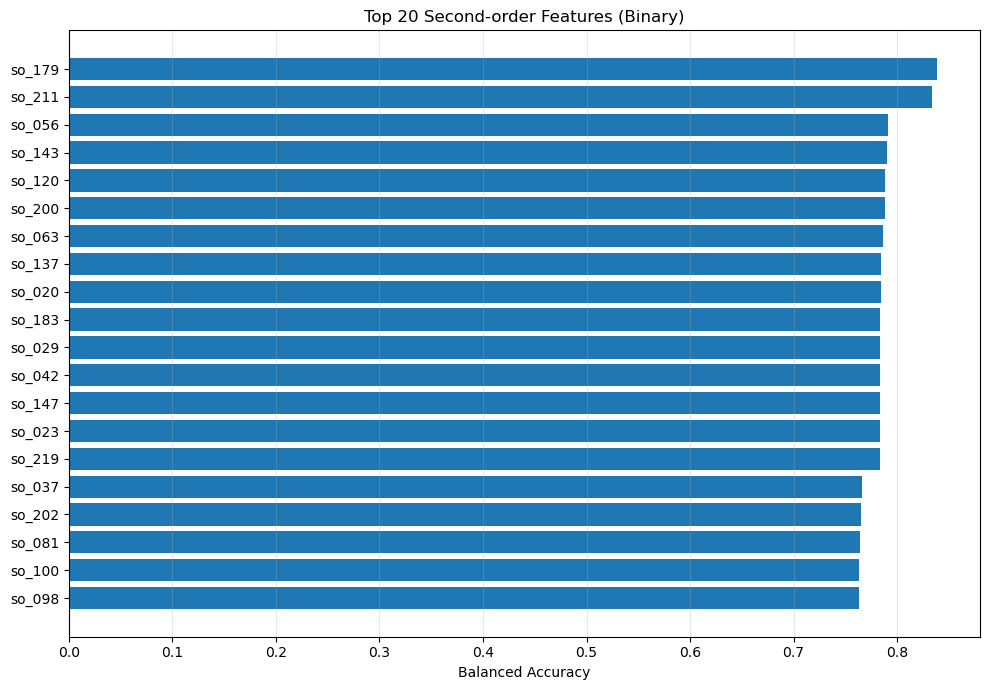

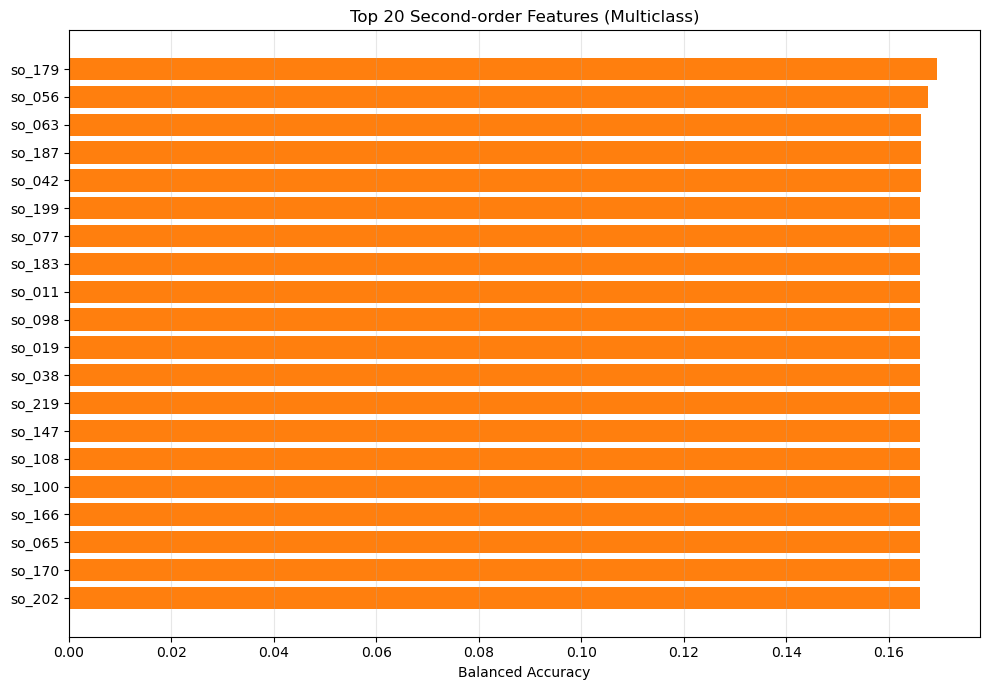

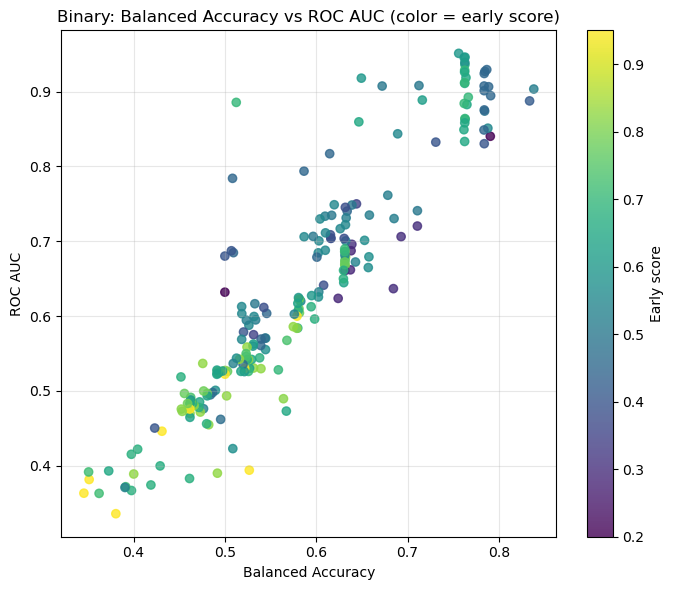

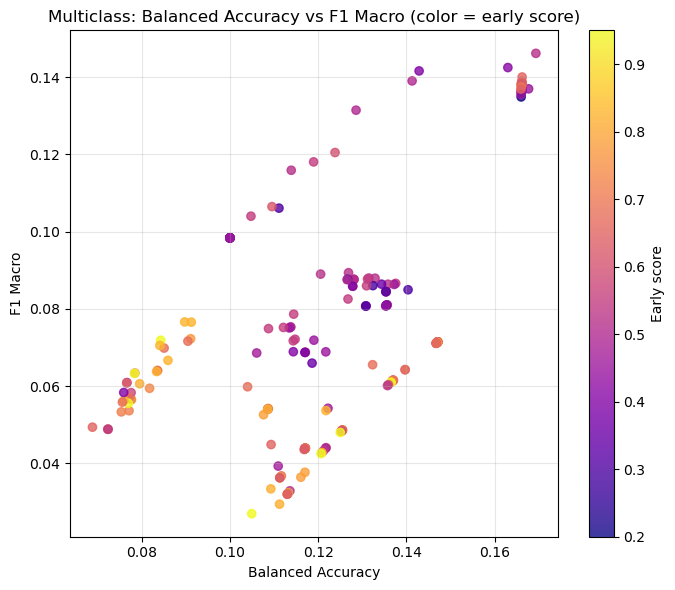

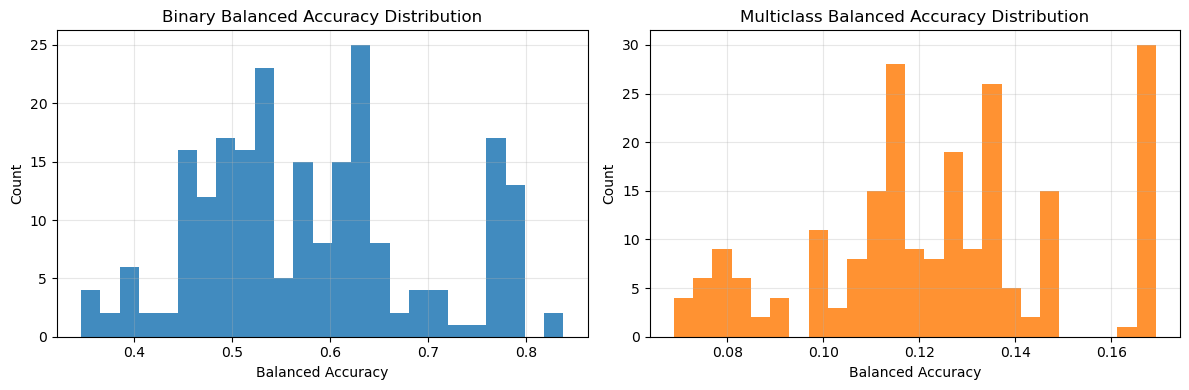

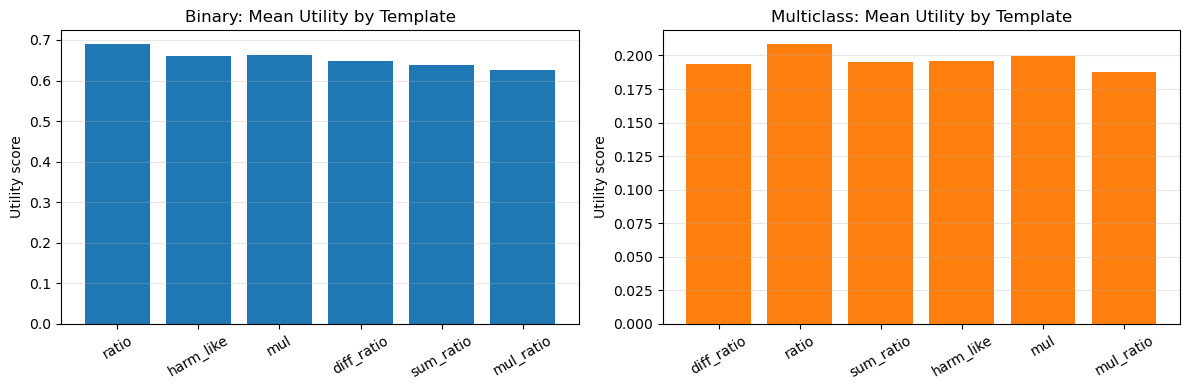

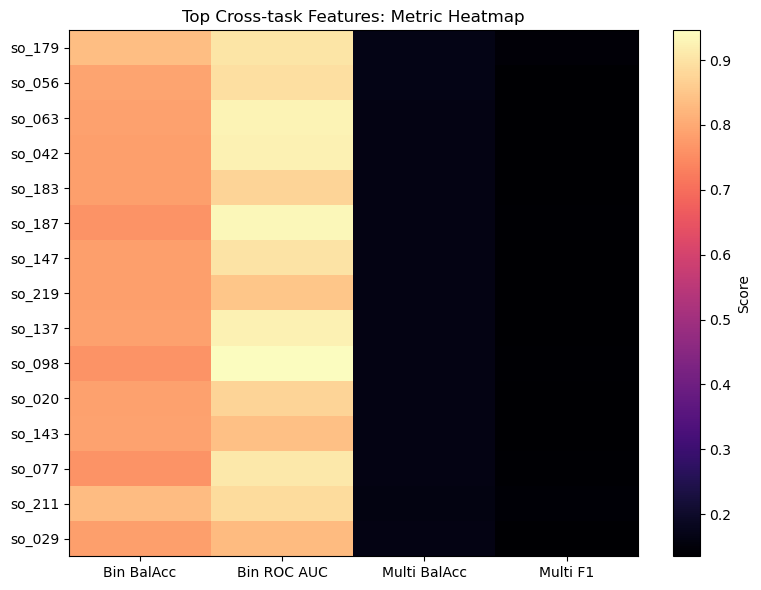

=== TABLE 9: Best original vs best second-order balanced accuracy ===


,task,best_original_bal_acc,best_second_order_bal_acc,delta
0,Binary,0.784277,0.838254,0.053976
1,Multiclass,0.543027,0.169312,-0.373715


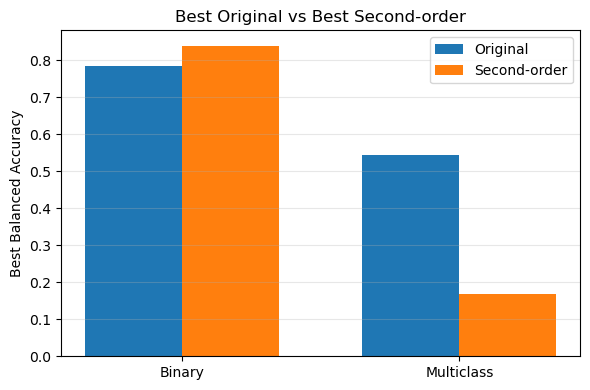

In [14]:
# Rich report for second-order feature results (tables + plots)

# --- Safety checks ---
required = ["second_order_results_binary", "second_order_results_multi"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Missing required variables: {missing}")

bin_df = second_order_results_binary.copy().sort_values("balanced_acc_mean", ascending=False).reset_index(drop=True)
mul_df = second_order_results_multi.copy().sort_values("balanced_acc_mean", ascending=False).reset_index(drop=True)

top_n = 20
pd.set_option("display.max_colwidth", 120)

print("=== TABLE 1: Top binary features by balanced accuracy ===")
display(bin_df.head(top_n)[
    ["feature", "expr", "template", "balanced_acc_mean", "roc_auc_mean", "early_score", "utility_score"]
])

print("=== TABLE 2: Top binary features by ROC AUC ===")
display(bin_df.sort_values("roc_auc_mean", ascending=False).head(top_n)[
    ["feature", "expr", "template", "balanced_acc_mean", "roc_auc_mean", "early_score", "utility_score"]
])

print("=== TABLE 3: Top multiclass features by balanced accuracy ===")
display(mul_df.head(top_n)[
    ["feature", "expr", "template", "balanced_acc_mean", "f1_macro_mean", "early_score", "utility_score"]
])

print("=== TABLE 4: Top multiclass features by F1-macro ===")
display(mul_df.sort_values("f1_macro_mean", ascending=False).head(top_n)[
    ["feature", "expr", "template", "balanced_acc_mean", "f1_macro_mean", "early_score", "utility_score"]
])

# --- Template-level summaries ---
tpl_bin = (
    bin_df.groupby("template", as_index=False)
    .agg(
        n_features=("feature", "count"),
        bal_acc_mean=("balanced_acc_mean", "mean"),
        roc_auc_mean=("roc_auc_mean", "mean"),
        utility_mean=("utility_score", "mean"),
        early_mean=("early_score", "mean"),
    )
    .sort_values("bal_acc_mean", ascending=False)
    .reset_index(drop=True)
)

tpl_mul = (
    mul_df.groupby("template", as_index=False)
    .agg(
        n_features=("feature", "count"),
        bal_acc_mean=("balanced_acc_mean", "mean"),
        f1_macro_mean=("f1_macro_mean", "mean"),
        utility_mean=("utility_score", "mean"),
        early_mean=("early_score", "mean"),
    )
    .sort_values("bal_acc_mean", ascending=False)
    .reset_index(drop=True)
)

print("=== TABLE 5: Template summary (binary) ===")
display(tpl_bin)

print("=== TABLE 6: Template summary (multiclass) ===")
display(tpl_mul)

# --- Cross-task overlap ---
join_df = bin_df.merge(
    mul_df[["feature", "balanced_acc_mean", "f1_macro_mean", "utility_score"]],
    on="feature",
    suffixes=("_bin", "_multi")
)
join_df["rank_bin"] = join_df["balanced_acc_mean_bin"].rank(ascending=False, method="min")
join_df["rank_multi"] = join_df["balanced_acc_mean_multi"].rank(ascending=False, method="min")
join_df["rank_sum"] = join_df["rank_bin"] + join_df["rank_multi"]

print("=== TABLE 7: Best overall features across binary + multiclass (low rank_sum is better) ===")
display(
    join_df.sort_values("rank_sum").head(top_n)[
        [
            "feature", "expr", "template",
            "balanced_acc_mean_bin", "roc_auc_mean",
            "balanced_acc_mean_multi", "f1_macro_mean",
            "early_score", "rank_bin", "rank_multi", "rank_sum"
        ]
    ]
)

# Optional: show top OVR discriminators if available
if "top_discriminators_by_type" in globals():
    print("=== TABLE 8: One-vs-rest top discriminators by object type (from OVR analysis) ===")
    display(top_discriminators_by_type.head(40))

# ----------------------------
# PLOTS
# ----------------------------

# Plot 1: Top binary balanced accuracy
plt.figure(figsize=(10, 7))
tmp = bin_df.head(top_n).iloc[::-1]
plt.barh(tmp["feature"], tmp["balanced_acc_mean"])
plt.xlabel("Balanced Accuracy")
plt.title(f"Top {top_n} Second-order Features (Binary)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Top multiclass balanced accuracy
plt.figure(figsize=(10, 7))
tmp = mul_df.head(top_n).iloc[::-1]
plt.barh(tmp["feature"], tmp["balanced_acc_mean"], color="tab:orange")
plt.xlabel("Balanced Accuracy")
plt.title(f"Top {top_n} Second-order Features (Multiclass)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Binary tradeoff scatter
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    bin_df["balanced_acc_mean"],
    bin_df["roc_auc_mean"],
    c=bin_df["early_score"],
    cmap="viridis",
    alpha=0.8
)
plt.xlabel("Balanced Accuracy")
plt.ylabel("ROC AUC")
plt.title("Binary: Balanced Accuracy vs ROC AUC (color = early score)")
plt.grid(alpha=0.3)
cbar = plt.colorbar(sc)
cbar.set_label("Early score")
plt.tight_layout()
plt.show()

# Plot 4: Multiclass tradeoff scatter
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    mul_df["balanced_acc_mean"],
    mul_df["f1_macro_mean"],
    c=mul_df["early_score"],
    cmap="plasma",
    alpha=0.8
)
plt.xlabel("Balanced Accuracy")
plt.ylabel("F1 Macro")
plt.title("Multiclass: Balanced Accuracy vs F1 Macro (color = early score)")
plt.grid(alpha=0.3)
cbar = plt.colorbar(sc)
cbar.set_label("Early score")
plt.tight_layout()
plt.show()

# Plot 5: Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(bin_df["balanced_acc_mean"], bins=25, alpha=0.85)
axes[0].set_title("Binary Balanced Accuracy Distribution")
axes[0].set_xlabel("Balanced Accuracy")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.3)

axes[1].hist(mul_df["balanced_acc_mean"], bins=25, alpha=0.85, color="tab:orange")
axes[1].set_title("Multiclass Balanced Accuracy Distribution")
axes[1].set_xlabel("Balanced Accuracy")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 6: Template-wise utility means
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(tpl_bin["template"], tpl_bin["utility_mean"])
ax[0].set_title("Binary: Mean Utility by Template")
ax[0].set_ylabel("Utility score")
ax[0].tick_params(axis="x", rotation=30)
ax[0].grid(axis="y", alpha=0.3)

ax[1].bar(tpl_mul["template"], tpl_mul["utility_mean"], color="tab:orange")
ax[1].set_title("Multiclass: Mean Utility by Template")
ax[1].set_ylabel("Utility score")
ax[1].tick_params(axis="x", rotation=30)
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 7: Top-overlap heatmap (binary + multiclass normalized)
top_overlap = join_df.sort_values("rank_sum").head(15).copy()
heat = np.c_[
    top_overlap["balanced_acc_mean_bin"].values,
    top_overlap["roc_auc_mean"].values,
    top_overlap["balanced_acc_mean_multi"].values,
    top_overlap["f1_macro_mean"].values
]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heat, aspect="auto", cmap="magma")
ax.set_yticks(np.arange(len(top_overlap)))
ax.set_yticklabels(top_overlap["feature"])
ax.set_xticks(np.arange(4))
ax.set_xticklabels(["Bin BalAcc", "Bin ROC AUC", "Multi BalAcc", "Multi F1"])
ax.set_title("Top Cross-task Features: Metric Heatmap")
plt.colorbar(im, ax=ax, label="Score")
plt.tight_layout()
plt.show()

# Optional: compare against original single metrics if available
if "binary_results" in globals() and "multi_results" in globals():
    orig_b_best = binary_results["balanced_acc_mean"].max()
    orig_m_best = multi_results["balanced_acc_mean"].max()
    so_b_best = bin_df["balanced_acc_mean"].max()
    so_m_best = mul_df["balanced_acc_mean"].max()

    compare = pd.DataFrame({
        "task": ["Binary", "Multiclass"],
        "best_original_bal_acc": [orig_b_best, orig_m_best],
        "best_second_order_bal_acc": [so_b_best, so_m_best],
    })
    compare["delta"] = compare["best_second_order_bal_acc"] - compare["best_original_bal_acc"]

    print("=== TABLE 9: Best original vs best second-order balanced accuracy ===")
    display(compare)

    plt.figure(figsize=(6, 4))
    x = np.arange(len(compare))
    w = 0.35
    plt.bar(x - w/2, compare["best_original_bal_acc"], width=w, label="Original")
    plt.bar(x + w/2, compare["best_second_order_bal_acc"], width=w, label="Second-order")
    plt.xticks(x, compare["task"])
    plt.ylabel("Best Balanced Accuracy")
    plt.title("Best Original vs Best Second-order")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Generated 220 third-order features.

Top third-order features (binary):


,feature,expr,template,early_score,balanced_acc_mean,roc_auc_mean,utility_score
0,to_179,sign(ztfg_fwhm*ztfg_fade_rate*ztfr_fwhm)*cuberoot(|...|),tri_signed_geom,0.283333,0.934376,0.953899,0.968376
1,to_003,ztfg_fade_hwhm*ztfg_fade_rate*ztfr_fade_hwhm,tri_mul,0.283333,0.903968,0.938897,0.937968
2,to_154,(ztfr_peak_gr_color*ztfg_fade_rate+ztfg_fade_rate*ztfi_peak_mag+ztfi_peak_mag*ztfr_peak_gr_color)/(|a|+|b|+|c|),tri_pairmix,0.450000,0.820052,0.934357,0.874052
3,to_165,(ztfg_peak_mag*ztfr_peak_ri_color+ztfr_peak_ri_color*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_mag)/(|a|+|b|+|c|),tri_pairmix,0.583333,0.789086,0.978695,0.859086
4,to_138,(ztfr_peak_gr_color*ztfi_peak_mag)/|ztfr_fade_rate|,tri_ratio_prod,0.450000,0.803317,0.944410,0.857317
5,to_004,(ztfr_peak_gr_color*ztfr_fade_hwhm)/|ztfg_fade_hwhm|,tri_ratio_prod,0.450000,0.802958,0.860337,0.856958
6,to_121,(ztfg_peak_mag*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_gi_color+ztfg_peak_gi_color*ztfg_peak_mag)/(|a|+|b|+|c|),tri_pairmix,0.583333,0.786561,0.972084,0.856561
7,to_098,(ztfi_peak_gi_color*ztfr_peak_gr_color+ztfr_peak_gr_color*ztfr_fade_rate+ztfr_fade_rate*ztfi_peak_gi_color)/(|a|+|b|...,tri_pairmix,0.483333,0.785488,0.953581,0.843488
8,to_084,ztfr_peak_gr_color*ztfg_peak_gr_color*ztfr_peak_ri_color,tri_mul,0.650000,0.763848,0.895572,0.841848
9,to_006,(ztfi_peak_mag+ztfr_peak_gr_color+ztfr_fade_rate)/3,tri_mean,0.450000,0.787189,0.986898,0.841189



Top third-order features (multiclass):


,feature,expr,template,early_score,balanced_acc_mean,f1_macro_mean,utility_score
0,to_084,ztfr_peak_gr_color*ztfg_peak_gr_color*ztfr_peak_ri_color,tri_mul,0.650000,0.165970,0.136650,0.243970
1,to_020,(ztfg_peak_gi_color*ztfr_peak_ri_color)/|ztfg_peak_mag|,tri_ratio_prod,0.616667,0.167648,0.138987,0.241648
2,to_063,(ztfr_peak_mag*ztfr_peak_ri_color+ztfr_peak_ri_color*ztfi_peak_gi_color+ztfi_peak_gi_color*ztfr_peak_mag)/(|a|+|b|+|c|),tri_pairmix,0.616667,0.166152,0.139092,0.240152
3,to_115,ztfr_peak_ri_color*ztfi_peak_ri_color*ztfi_peak_mag,tri_mul,0.616667,0.166121,0.139371,0.240121
4,to_165,(ztfg_peak_mag*ztfr_peak_ri_color+ztfr_peak_ri_color*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_mag)/(|a|+|b|+|c|),tri_pairmix,0.583333,0.166152,0.139036,0.236152
5,to_121,(ztfg_peak_mag*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_gi_color+ztfg_peak_gi_color*ztfg_peak_mag)/(|a|+|b|+|c|),tri_pairmix,0.583333,0.166091,0.138510,0.236091
6,to_202,ztfg_peak_mag*ztfr_peak_mag*ztfg_peak_gi_color,tri_mul,0.583333,0.166015,0.137133,0.236015
7,to_078,ztfi_rise_rate*ztfi_peak_gi_color*ztfi_peak_ri_color,tri_mul,0.733333,0.147117,0.071473,0.235117
8,to_060,sign(ztfg_peak_gi_color*ztfi_rise_rate*ztfr_peak_ri_color)*cuberoot(|...|),tri_signed_geom,0.733333,0.147102,0.071464,0.235102
9,to_172,(ztfi_rise_rate*ztfr_peak_gr_color+ztfr_peak_gr_color*ztfg_peak_gi_color+ztfg_peak_gi_color*ztfi_rise_rate)/(|a|+|b|...,tri_pairmix,0.733333,0.147011,0.071375,0.235011



Best balanced-accuracy comparison (third-order vs second-order):


,task,best_second_order_bal_acc,best_third_order_bal_acc,delta_third_minus_second
0,Binary,0.838254,0.934376,0.096122
1,Multiclass,0.169312,0.194048,0.024735


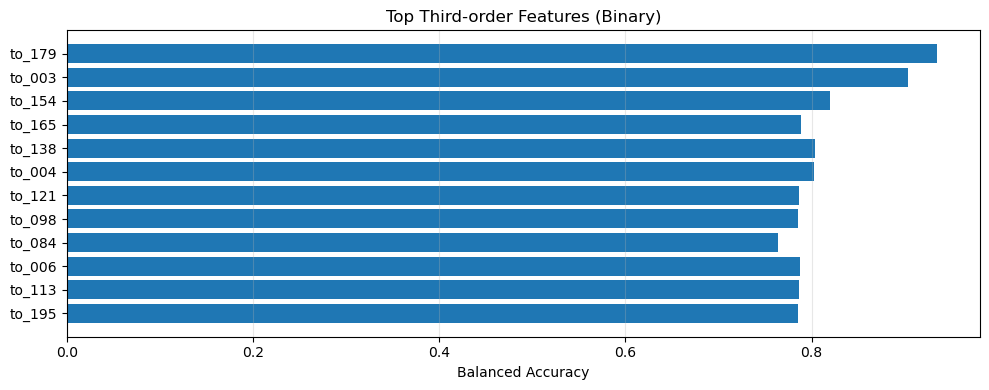

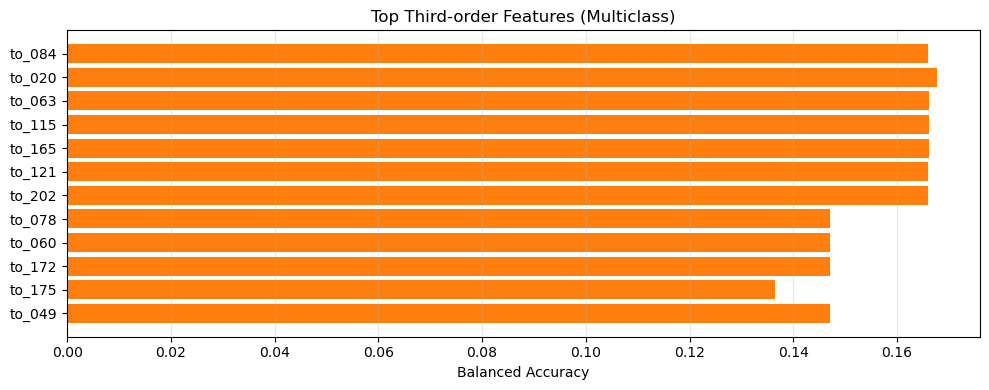

In [15]:
# Randomized third-order feature experiment
# Reuses existing notebook state: X_all, common_numeric, y_bin, y_multi, k, cross_val_score, etc.

eps = 1e-8
rng3 = np.random.default_rng(2027)
n_third_features = 220

base3 = X_all[common_numeric].copy()

# Reuse early-score heuristic if available
if "metric_early_score" in globals():
    early_score_fn = metric_early_score
else:
    def early_score_fn(name: str) -> float:
        n = str(name).lower()
        if "rise" in n:
            return 1.0
        if "peak" in n and "color" in n:
            return 0.75
        if "peak" in n:
            return 0.65
        if "fwhm" in n or "hwhm" in n:
            return 0.45
        if "fade" in n:
            return 0.25
        return 0.5

third_templates = [
    ("tri_mul", lambda a, b, c: a * b * c),
    ("tri_mean", lambda a, b, c: (a + b + c) / 3.0),
    ("tri_pairmix", lambda a, b, c: (a * b + b * c + c * a) / (np.abs(a) + np.abs(b) + np.abs(c) + eps)),
    ("tri_contrast", lambda a, b, c: ((a - b) * c) / (np.abs(a) + np.abs(b) + np.abs(c) + eps)),
    ("tri_ratio_prod", lambda a, b, c: (a * b) / (np.abs(c) + eps)),
    ("tri_signed_geom", lambda a, b, c: np.sign(a * b * c) * np.cbrt(np.abs(a * b * c) + eps)),
]

third_series = []
third_meta_rows = []
seen3 = set()

attempts = 0
max_attempts = n_third_features * 30

while len(third_series) < n_third_features and attempts < max_attempts:
    attempts += 1
    tname, tfunc = third_templates[rng3.integers(0, len(third_templates))]
    picked = list(rng3.choice(common_numeric, size=3, replace=False))
    key = (tname, tuple(sorted(picked)))
    if key in seen3:
        continue
    seen3.add(key)

    a = base3[picked[0]].astype(float)
    b = base3[picked[1]].astype(float)
    c = base3[picked[2]].astype(float)

    feat = pd.Series(tfunc(a, b, c), index=base3.index).replace([np.inf, -np.inf], np.nan)

    if feat.notna().sum() < 50:
        continue
    if np.nanstd(feat.values) < 1e-10:
        continue

    col = f"to_{len(third_series):03d}"
    expr = (
        f"{picked[0]}*{picked[1]}*{picked[2]}" if tname == "tri_mul" else
        f"({picked[0]}+{picked[1]}+{picked[2]})/3" if tname == "tri_mean" else
        f"({picked[0]}*{picked[1]}+{picked[1]}*{picked[2]}+{picked[2]}*{picked[0]})/(|a|+|b|+|c|)" if tname == "tri_pairmix" else
        f"(({picked[0]}-{picked[1]})*{picked[2]})/(|a|+|b|+|c|)" if tname == "tri_contrast" else
        f"({picked[0]}*{picked[1]})/|{picked[2]}|" if tname == "tri_ratio_prod" else
        f"sign({picked[0]}*{picked[1]}*{picked[2]})*cuberoot(|...|)"
    )

    third_series.append(feat.rename(col))
    early = np.mean([early_score_fn(m) for m in picked]) - 0.10  # mild penalty for 3-term complexity
    third_meta_rows.append(
        {
            "feature": col,
            "expr": expr,
            "template": tname,
            "n_terms": 3,
            "early_score": float(np.clip(early, 0, 1)),
            "m1": picked[0],
            "m2": picked[1],
            "m3": picked[2],
        }
    )

third_order_metrics = pd.concat(third_series, axis=1) if third_series else pd.DataFrame(index=base3.index)
third_order_meta = pd.DataFrame(third_meta_rows)

if third_order_metrics.shape[1] == 0:
    raise ValueError("No third-order features were generated.")

print(f"Generated {third_order_metrics.shape[1]} third-order features.")

# CV builder (reuse existing helper if present)
if "make_cv_local" in globals():
    cv3_bin = make_cv_local(y_bin, max_splits=5, n_repeats=3, random_state=99)
    cv3_multi = make_cv_local(y_multi, max_splits=5, n_repeats=3, random_state=99)
elif "make_repeated_cv" in globals():
    cv3_bin = make_repeated_cv(y_bin, max_splits=5, n_repeats=3, random_state=99)
    cv3_multi = make_repeated_cv(y_multi, max_splits=5, n_repeats=3, random_state=99)
else:
    min_count_bin = pd.Series(y_bin).value_counts().min()
    n_splits_bin = max(2, min(5, int(min_count_bin)))
    cv3_bin = sklearn.model_selection.RepeatedStratifiedKFold(n_splits=n_splits_bin, n_repeats=3, random_state=99)

    min_count_mul = pd.Series(y_multi).value_counts().min()
    n_splits_mul = max(2, min(5, int(min_count_mul)))
    cv3_multi = sklearn.model_selection.RepeatedStratifiedKFold(n_splits=n_splits_mul, n_repeats=3, random_state=99)

# Evaluator (reuse existing helper if available)
if "eval_single_feature_set" in globals():
    to_bin = eval_single_feature_set(third_order_metrics, y_bin, mode="binary", cv=cv3_bin)
    to_multi = eval_single_feature_set(third_order_metrics, y_multi, mode="multiclass", cv=cv3_multi)
else:
    def _eval_single_feature_set_local(X_df, y, mode="binary", cv=None):
        rows_local = []
        for col in X_df.columns:
            Xi = X_df[[col]]
            pipe = sklearn.pipeline.make_pipeline(
                SimpleImputer(strategy="median"),
                StandardScaler(),
                KNN(n_neighbors=k)
            )
            bal = cross_val_score(pipe, Xi, y, cv=cv, scoring="balanced_accuracy", error_score=np.nan)
            row = {
                "feature": col,
                "balanced_acc_mean": np.nanmean(bal),
                "balanced_acc_std": np.nanstd(bal),
            }
            if mode == "binary":
                aux = cross_val_score(pipe, Xi, y, cv=cv, scoring="roc_auc", error_score=np.nan)
                row["roc_auc_mean"] = np.nanmean(aux)
                row["roc_auc_std"] = np.nanstd(aux)
            else:
                aux = cross_val_score(pipe, Xi, y, cv=cv, scoring="f1_macro", error_score=np.nan)
                row["f1_macro_mean"] = np.nanmean(aux)
                row["f1_macro_std"] = np.nanstd(aux)
            rows_local.append(row)
        return pd.DataFrame(rows_local)

    to_bin = _eval_single_feature_set_local(third_order_metrics, y_bin, mode="binary", cv=cv3_bin)
    to_multi = _eval_single_feature_set_local(third_order_metrics, y_multi, mode="multiclass", cv=cv3_multi)

to_bin = to_bin.merge(third_order_meta, on="feature", how="left")
to_multi = to_multi.merge(third_order_meta, on="feature", how="left")

to_bin["utility_score"] = to_bin["balanced_acc_mean"] + 0.12 * to_bin["early_score"]
to_multi["utility_score"] = to_multi["balanced_acc_mean"] + 0.12 * to_multi["early_score"]

third_order_results_binary = to_bin.sort_values("utility_score", ascending=False).reset_index(drop=True)
third_order_results_multi = to_multi.sort_values("utility_score", ascending=False).reset_index(drop=True)

print("\nTop third-order features (binary):")
display(
    third_order_results_binary.head(15)[
        ["feature", "expr", "template", "early_score", "balanced_acc_mean", "roc_auc_mean", "utility_score"]
    ]
)

print("\nTop third-order features (multiclass):")
display(
    third_order_results_multi.head(15)[
        ["feature", "expr", "template", "early_score", "balanced_acc_mean", "f1_macro_mean", "utility_score"]
    ]
)

# Quick comparison to second-order best (if available)
if "second_order_results_binary" in globals() and "second_order_results_multi" in globals():
    cmp_df = pd.DataFrame(
        {
            "task": ["Binary", "Multiclass"],
            "best_second_order_bal_acc": [
                second_order_results_binary["balanced_acc_mean"].max(),
                second_order_results_multi["balanced_acc_mean"].max(),
            ],
            "best_third_order_bal_acc": [
                third_order_results_binary["balanced_acc_mean"].max(),
                third_order_results_multi["balanced_acc_mean"].max(),
            ],
        }
    )
    cmp_df["delta_third_minus_second"] = (
        cmp_df["best_third_order_bal_acc"] - cmp_df["best_second_order_bal_acc"]
    )
    print("\nBest balanced-accuracy comparison (third-order vs second-order):")
    display(cmp_df)

# Compact plots
top_n_view = 12

plt.figure(figsize=(10, 4))
plot_b = third_order_results_binary.head(top_n_view).iloc[::-1]
plt.barh(plot_b["feature"], plot_b["balanced_acc_mean"])
plt.xlabel("Balanced Accuracy")
plt.title("Top Third-order Features (Binary)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plot_m = third_order_results_multi.head(top_n_view).iloc[::-1]
plt.barh(plot_m["feature"], plot_m["balanced_acc_mean"], color="tab:orange")
plt.xlabel("Balanced Accuracy")
plt.title("Top Third-order Features (Multiclass)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# One-vs-rest single-feature analysis for each object type
# Reuses: X_all, all_types, common_numeric, k

top_n = 5
max_splits = 5
min_class_support = 2  # need at least 2 positives and 2 negatives for stratified CV

labels = all_types.fillna("Unknown").astype(str)
type_counts = labels.value_counts()

rows = []
skipped = []

for obj_type, support in type_counts.items():
    y_ovr = (labels == obj_type).astype(int).values
    pos = int(y_ovr.sum())
    neg = int((1 - y_ovr).sum())

    if min(pos, neg) < min_class_support:
        skipped.append((obj_type, pos, neg))
        continue

    n_splits = min(max_splits, pos, neg)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for col in common_numeric:
        Xi = X_all[[col]]
        pipe = sklearn.pipeline.make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            KNN(n_neighbors=k)
        )

        bal = cross_val_score(pipe, Xi, y_ovr, cv=cv, scoring="balanced_accuracy", error_score=np.nan)
        auc = cross_val_score(pipe, Xi, y_ovr, cv=cv, scoring="roc_auc", error_score=np.nan)

        rows.append({
            "object_type": obj_type,
            "support": pos,
            "metric": col,
            "balanced_acc_mean": np.nanmean(bal),
            "balanced_acc_std": np.nanstd(bal),
            "roc_auc_mean": np.nanmean(auc),
            "roc_auc_std": np.nanstd(auc),
            "n_splits": n_splits
        })

ovr_feature_results = pd.DataFrame(rows).sort_values(
    ["object_type", "balanced_acc_mean"], ascending=[True, False]
).reset_index(drop=True)

# Top discriminators per type
top_discriminators_by_type = (
    ovr_feature_results
    .groupby("object_type", group_keys=False)
    .head(top_n)
    .reset_index(drop=True)
)

print(f"Evaluated object types: {ovr_feature_results['object_type'].nunique()} / {labels.nunique()}")
if skipped:
    print("\nSkipped (insufficient positives/negatives for stratified CV):")
    for t, p, n in skipped:
        print(f"  - {t}: positives={p}, negatives={n}")

print(f"\nTop {top_n} single-feature discriminators per object type (one-vs-rest):")
display(top_discriminators_by_type)

# Optional compact view: best feature per type
best_feature_per_type = (
    ovr_feature_results
    .sort_values(["object_type", "balanced_acc_mean"], ascending=[True, False])
    .groupby("object_type", as_index=False)
    .first()[["object_type", "support", "metric", "balanced_acc_mean", "roc_auc_mean"]]
    .sort_values("balanced_acc_mean", ascending=False)
    .reset_index(drop=True)
)

print("\nBest single discriminator for each object type:")
display(best_feature_per_type)

Evaluated object types: 9 / 16

Skipped (insufficient positives/negatives for stratified CV):
  - Kilonova: positives=1, negatives=2271
  - AT2026brq: positives=1, negatives=2271
  - TDE: positives=1, negatives=2271
  - FBOT: positives=1, negatives=2271
  - IIP: positives=1, negatives=2271
  - AT2025ulz: positives=1, negatives=2271
  - ZTF25aceeneu: positives=1, negatives=2271

Top 5 single-feature discriminators per object type (one-vs-rest):


,object_type,support,metric,balanced_acc_mean,balanced_acc_std,roc_auc_mean,roc_auc_std,n_splits
0,Afterglow,7,ztfg_fade_hwhm,0.500000,0.000000,0.566998,0.266171,5
1,Afterglow,7,ztfg_fade_rate,0.500000,0.000000,0.832892,0.198850,5
2,Afterglow,7,ztfg_fwhm,0.500000,0.000000,0.547461,0.328481,5
3,Afterglow,7,ztfg_peak_gi_color,0.500000,0.000000,0.981236,0.010993,5
4,Afterglow,7,ztfg_peak_gr_color,0.500000,0.000000,0.826711,0.209873,5
5,Cataclysmic,11,ztfg_fade_hwhm,0.500000,0.000000,0.792259,0.098361,5
6,Cataclysmic,11,ztfg_fade_rate,0.500000,0.000000,0.649134,0.190521,5
7,Cataclysmic,11,ztfg_fwhm,0.500000,0.000000,0.803141,0.185481,5
8,Cataclysmic,11,ztfg_peak_gi_color,0.500000,0.000000,0.930351,0.097974,5
9,Cataclysmic,11,ztfg_peak_gr_color,0.500000,0.000000,0.851266,0.117404,5



Best single discriminator for each object type:


,object_type,support,metric,balanced_acc_mean,roc_auc_mean
0,bulla_kilonova_model,2200,ztfg_peak_mag,0.78381,0.951884
1,Afterglow,7,ztfg_fade_hwhm,0.50000,0.566998
2,Cataclysmic,11,ztfg_fade_hwhm,0.50000,0.792259
3,II,9,ztfg_fade_hwhm,0.50000,0.793479
4,IIb,21,ztfg_fade_hwhm,0.50000,0.874957
5,Ia,4,ztfg_fade_hwhm,0.50000,0.997575
6,Ib,3,ztfg_fade_hwhm,0.50000,0.495373
7,Ibn,3,ztfg_fade_hwhm,0.50000,0.828486
8,Novae,7,ztfg_fade_hwhm,0.50000,0.649007


<a id="rf"></a>
# Random Forest

note: this took like 4 hours to run on a macbook

Best RF binary params: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__n_estimators': 400} | best CV score: 1.0
Best RF multiclass params: {'rf__max_depth': 10, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 200} | best CV score: 0.5472

Top RF single-feature metrics (binary):


,feature,balanced_acc_mean,roc_auc_mean
0,ztfg_peak_mag,0.941819,0.942196
1,ztfg_fade_hwhm,0.915563,0.895346
2,ztfg_fwhm,0.915087,0.880813
3,ztfr_fade_hwhm,0.914625,0.898318
4,ztfi_peak_mag,0.905301,0.918242
5,ztfr_fwhm,0.894852,0.895005
6,ztfr_peak_mag,0.876470,0.896179
7,ztfg_peak_gi_color,0.852359,0.869062
8,ztfi_peak_gi_color,0.822597,0.879570
9,ztfr_peak_ri_color,0.794198,0.834639



Top RF single-feature metrics (multiclass):


,feature,balanced_acc_mean,f1_macro_mean
0,ztfg_peak_mag,0.545729,0.530954
1,ztfr_peak_mag,0.493597,0.449102
2,ztfr_fwhm,0.284656,0.271900
3,ztfg_fade_hwhm,0.278439,0.263307
4,ztfr_fade_hwhm,0.276674,0.254200
5,ztfg_fwhm,0.261905,0.259245
6,ztfi_peak_mag,0.260021,0.232983
7,ztfr_peak_gr_color,0.191229,0.176285
8,ztfi_fade_rate,0.188222,0.110287
9,ztfg_rise_hwhm,0.184271,0.173275



Top RF second-order features (binary):


...

,feature,balanced_acc_mean,balanced_acc_std,f1_macro_mean,f1_macro_std,expr,template,n_terms,early_score
0,so_008,0.516767,0.068622,0.497861,0.070216,ztfg_peak_mag*ztfr_peak_mag,mul,2,0.600000
1,so_211,0.369979,0.039481,0.318297,0.045303,(ztfr_fwhm+ztfr_peak_mag)/|ztfg_fwhm|,sum_ratio,3,0.416667
2,so_214,0.301326,0.037423,0.284892,0.044871,ztfg_fade_hwhm*ztfr_peak_mag,mul,2,0.500000
3,so_024,0.294745,0.051447,0.273572,0.031958,ztfr_fwhm*ztfr_peak_mag,mul,2,0.500000
4,so_179,0.278828,0.056721,0.266899,0.048874,(ztfg_peak_gr_color-ztfr_peak_mag)/|ztfg_fwhm|,diff_ratio,3,0.516667
5,so_056,0.251019,0.041000,0.186667,0.039399,(ztfi_peak_mag-ztfi_fade_rate)/|ztfi_peak_ri_color|,diff_ratio,3,0.450000
6,so_112,0.241396,0.053879,0.227206,0.042185,(ztfg_peak_gr_color+ztfr_fade_hwhm)/|ztfr_peak_mag|,sum_ratio,3,0.516667
7,so_116,0.240693,0.044146,0.236640,0.044915,ztfg_peak_mag/|ztfr_peak_mag|,ratio,2,0.600000
8,so_219,0.233214,0.051424,0.163922,0.051991,(ztfi_peak_gi_color-ztfg_peak_mag)/|ztfr_fade_rate|,diff_ratio,3,0.450000
9,so_147,0.233154,0.055888,0.170724,0.046102,"harm(ztfi_fade_rate,ztfr_peak_gr_color)",harm_like,2,0.450000



Top RF third-order features (binary):


,feature,balanced_acc_mean,balanced_acc_std,roc_auc_mean,roc_auc_std,expr,template,n_terms,early_score,m1,m2,m3
0,to_113,0.980505,0.021702,0.980705,0.021937,(ztfi_fade_rate+ztfi_peak_ri_color+ztfg_peak_mag)/3,tri_mean,3,0.450000,ztfi_fade_rate,ztfi_peak_ri_color,ztfg_peak_mag
1,to_006,0.972537,0.026359,0.973537,0.026943,(ztfi_peak_mag+ztfr_peak_gr_color+ztfr_fade_rate)/3,tri_mean,3,0.450000,ztfi_peak_mag,ztfr_peak_gr_color,ztfr_fade_rate
2,to_121,0.951728,0.033468,0.970521,0.023645,(ztfg_peak_mag*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_gi_color+ztfg_peak_gi_color*ztfg_peak_mag)/(|a|+|b|+|c|),tri_pairmix,3,0.583333,ztfg_peak_mag,ztfr_peak_mag,ztfg_peak_gi_color
3,to_165,0.949265,0.028452,0.963686,0.025938,(ztfg_peak_mag*ztfr_peak_ri_color+ztfr_peak_ri_color*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_mag)/(|a|+|b|+|c|),tri_pairmix,3,0.583333,ztfg_peak_mag,ztfr_peak_ri_color,ztfr_peak_mag
4,to_152,0.940596,0.031792,0.923314,0.050912,((ztfr_peak_mag-ztfg_peak_gr_color)*ztfg_fwhm)/(|a|+|b|+|c|),tri_contrast,3,0.516667,ztfr_peak_mag,ztfg_peak_gr_color,ztfg_fwhm
5,to_154,0.936466,0.036329,0.936763,0.036801,(ztfr_peak_gr_color*ztfg_fade_rate+ztfg_fade_rate*ztfi_peak_mag+ztfi_peak_mag*ztfr_peak_gr_color)/(|a|+|b|+|c|),tri_pairmix,3,0.450000,ztfr_peak_gr_color,ztfg_fade_rate,ztfi_peak_mag
6,to_003,0.935834,0.048413,0.956639,0.031562,ztfg_fade_hwhm*ztfg_fade_rate*ztfr_fade_hwhm,tri_mul,3,0.283333,ztfg_fade_hwhm,ztfg_fade_rate,ztfr_fade_hwhm
7,to_179,0.935455,0.050401,0.950652,0.036849,sign(ztfg_fwhm*ztfg_fade_rate*ztfr_fwhm)*cuberoot(|...|),tri_signed_geom,3,0.283333,ztfg_fwhm,ztfg_fade_rate,ztfr_fwhm
8,to_052,0.927457,0.040579,0.908565,0.058287,(ztfg_fade_hwhm*ztfg_fwhm+ztfg_fwhm*ztfg_peak_mag+ztfg_peak_mag*ztfg_fade_hwhm)/(|a|+|b|+|c|),tri_pairmix,3,0.416667,ztfg_fade_hwhm,ztfg_fwhm,ztfg_peak_mag
9,to_157,0.885195,0.047605,0.869698,0.071174,(ztfg_peak_gr_color+ztfg_fwhm+ztfr_peak_mag)/3,tri_mean,3,0.516667,ztfg_peak_gr_color,ztfg_fwhm,ztfr_peak_mag



Top RF third-order features (multiclass):


,feature,balanced_acc_mean,balanced_acc_std,f1_macro_mean,f1_macro_std,expr,template,n_terms,early_score,m1,m2,m3
0,to_185,0.346407,0.042102,0.342612,0.048262,(ztfr_fade_hwhm+ztfg_peak_gr_color+ztfg_peak_mag)/3,tri_mean,3,0.516667,ztfr_fade_hwhm,ztfg_peak_gr_color,ztfg_peak_mag
1,to_166,0.341324,0.038823,0.334868,0.029290,(ztfr_peak_mag+ztfg_fade_rate+ztfr_fade_hwhm)/3,tri_mean,3,0.350000,ztfr_peak_mag,ztfg_fade_rate,ztfr_fade_hwhm
2,to_165,0.329519,0.086556,0.274572,0.073297,(ztfg_peak_mag*ztfr_peak_ri_color+ztfr_peak_ri_color*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_mag)/(|a|+|b|+|c|),tri_pairmix,3,0.583333,ztfg_peak_mag,ztfr_peak_ri_color,ztfr_peak_mag
3,to_113,0.289425,0.043944,0.222926,0.045869,(ztfi_fade_rate+ztfi_peak_ri_color+ztfg_peak_mag)/3,tri_mean,3,0.450000,ztfi_fade_rate,ztfi_peak_ri_color,ztfg_peak_mag
4,to_152,0.276980,0.051483,0.261960,0.049042,((ztfr_peak_mag-ztfg_peak_gr_color)*ztfg_fwhm)/(|a|+|b|+|c|),tri_contrast,3,0.516667,ztfr_peak_mag,ztfg_peak_gr_color,ztfg_fwhm
5,to_137,0.276864,0.066756,0.222975,0.059590,(ztfr_fade_rate+ztfg_peak_mag+ztfi_fade_hwhm)/3,tri_mean,3,0.350000,ztfr_fade_rate,ztfg_peak_mag,ztfi_fade_hwhm
6,to_121,0.265427,0.076971,0.234656,0.067117,(ztfg_peak_mag*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_gi_color+ztfg_peak_gi_color*ztfg_peak_mag)/(|a|+|b|+|c|),tri_pairmix,3,0.583333,ztfg_peak_mag,ztfr_peak_mag,ztfg_peak_gi_color
7,to_133,0.264575,0.073968,0.252049,0.056258,((ztfr_fade_hwhm-ztfg_fwhm)*ztfr_peak_mag)/(|a|+|b|+|c|),tri_contrast,3,0.416667,ztfr_fade_hwhm,ztfg_fwhm,ztfr_peak_mag
8,to_138,0.264224,0.052085,0.192835,0.033301,(ztfr_peak_gr_color*ztfi_peak_mag)/|ztfr_fade_rate|,tri_ratio_prod,3,0.450000,ztfr_peak_gr_color,ztfi_peak_mag,ztfr_fade_rate
9,to_154,0.257456,0.050615,0.192814,0.042604,(ztfr_peak_gr_color*ztfg_fade_rate+ztfg_fade_rate*ztfi_peak_mag+ztfi_peak_mag*ztfr_peak_gr_color)/(|a|+|b|+|c|),tri_pairmix,3,0.450000,ztfr_peak_gr_color,ztfg_fade_rate,ztfi_peak_mag


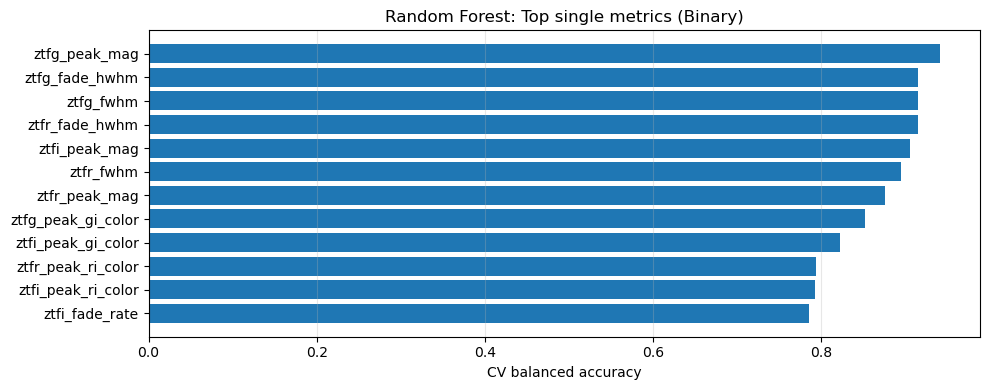

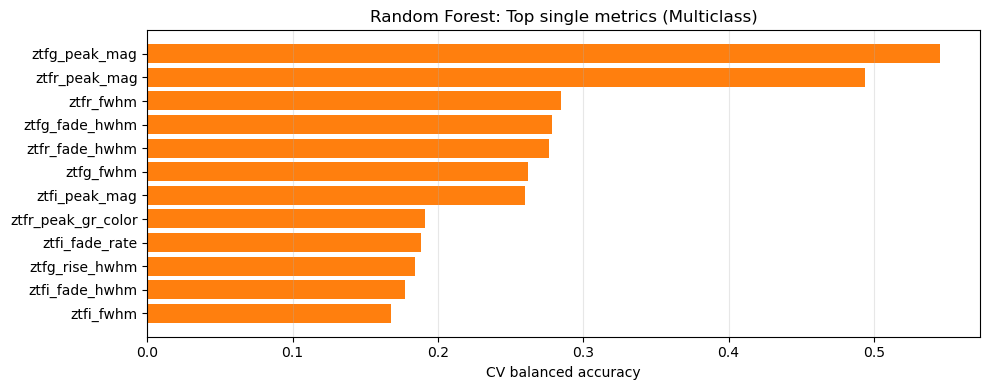

In [17]:
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Random Forest: tuned single-feature analysis (binary + multiclass)
# -----------------------------

def _make_cv_rf(y, max_splits=5, n_repeats=3, random_state=42):
    if "make_repeated_cv" in globals():
        return make_repeated_cv(y, max_splits=max_splits, n_repeats=n_repeats, random_state=random_state)
    min_count = pd.Series(y).value_counts().min()
    n_splits = max(2, min(max_splits, int(min_count)))
    return RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)

def _tune_rf(X_df, y, mode="binary", random_state=42):
    cv = _make_cv_rf(y, max_splits=5, n_repeats=2, random_state=random_state)

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            random_state=random_state,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ])

    param_grid = {
        "rf__n_estimators": [200, 400],
        "rf__max_depth": [None, 10, 20],
        "rf__min_samples_leaf": [1, 3, 5],
        "rf__max_features": ["sqrt", 0.5]
    }

    scoring = "roc_auc" if mode == "binary" else "balanced_accuracy"

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    gs.fit(X_df, y)
    return gs.best_params_, gs.best_score_

def _eval_single_feature_rf(X_df, y, rf_params, mode="binary", cv=None, random_state=42):
    clean_params = {k.replace("rf__", ""): v for k, v in rf_params.items()}

    rows = []
    for col in X_df.columns:
        Xi = X_df[[col]]
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("rf", RandomForestClassifier(
                random_state=random_state,
                n_jobs=-1,
                class_weight="balanced_subsample",
                **clean_params
            ))
        ])

        bal = cross_val_score(pipe, Xi, y, cv=cv, scoring="balanced_accuracy", error_score=np.nan)

        row = {
            "feature": col,
            "balanced_acc_mean": np.nanmean(bal),
            "balanced_acc_std": np.nanstd(bal),
        }

        if mode == "binary":
            aux = cross_val_score(pipe, Xi, y, cv=cv, scoring="roc_auc", error_score=np.nan)
            row["roc_auc_mean"] = np.nanmean(aux)
            row["roc_auc_std"] = np.nanstd(aux)
        else:
            aux = cross_val_score(pipe, Xi, y, cv=cv, scoring="f1_macro", error_score=np.nan)
            row["f1_macro_mean"] = np.nanmean(aux)
            row["f1_macro_std"] = np.nanstd(aux)

        rows.append(row)

    return pd.DataFrame(rows).sort_values("balanced_acc_mean", ascending=False).reset_index(drop=True)

# Base feature matrix
X_orig = X_all[common_numeric]

# Tune RF once per task
rf_best_bin_params, rf_best_bin_score = _tune_rf(X_orig, y_bin, mode="binary", random_state=42)
rf_best_multi_params, rf_best_multi_score = _tune_rf(X_orig, y_multi, mode="multiclass", random_state=42)

print("Best RF binary params:", rf_best_bin_params, "| best CV score:", round(rf_best_bin_score, 4))
print("Best RF multiclass params:", rf_best_multi_params, "| best CV score:", round(rf_best_multi_score, 4))

# Evaluate original single metrics
cv_bin = _make_cv_rf(y_bin, max_splits=5, n_repeats=3, random_state=123)
cv_multi = _make_cv_rf(y_multi, max_splits=5, n_repeats=3, random_state=123)

rf_binary_results = _eval_single_feature_rf(X_orig, y_bin, rf_best_bin_params, mode="binary", cv=cv_bin, random_state=42)
rf_multi_results = _eval_single_feature_rf(X_orig, y_multi, rf_best_multi_params, mode="multiclass", cv=cv_multi, random_state=42)

print("\nTop RF single-feature metrics (binary):")
display(rf_binary_results.head(15)[["feature", "balanced_acc_mean", "roc_auc_mean"]])

print("\nTop RF single-feature metrics (multiclass):")
display(rf_multi_results.head(15)[["feature", "balanced_acc_mean", "f1_macro_mean"]])

# Optional: second-order evaluation (if available)
if "second_order_metrics" in globals():
    rf_second_order_binary = _eval_single_feature_rf(
        second_order_metrics, y_bin, rf_best_bin_params, mode="binary", cv=cv_bin, random_state=42
    )
    rf_second_order_multi = _eval_single_feature_rf(
        second_order_metrics, y_multi, rf_best_multi_params, mode="multiclass", cv=cv_multi, random_state=42
    )

    if "second_order_meta" in globals():
        rf_second_order_binary = rf_second_order_binary.merge(second_order_meta, on="feature", how="left")
        rf_second_order_multi = rf_second_order_multi.merge(second_order_meta, on="feature", how="left")

    print("\nTop RF second-order features (binary):")
    display(rf_second_order_binary.head(10))

    print("\nTop RF second-order features (multiclass):")
    display(rf_second_order_multi.head(10))

# Optional: third-order evaluation (if available)
if "third_order_metrics" not in globals() and "third_series" in globals():
    third_order_metrics = pd.concat(third_series, axis=1)

if "third_order_metrics" in globals():
    rf_third_order_binary = _eval_single_feature_rf(
        third_order_metrics, y_bin, rf_best_bin_params, mode="binary", cv=cv_bin, random_state=42
    )
    rf_third_order_multi = _eval_single_feature_rf(
        third_order_metrics, y_multi, rf_best_multi_params, mode="multiclass", cv=cv_multi, random_state=42
    )

    if "third_order_meta" in globals():
        rf_third_order_binary = rf_third_order_binary.merge(third_order_meta, on="feature", how="left")
        rf_third_order_multi = rf_third_order_multi.merge(third_order_meta, on="feature", how="left")

    print("\nTop RF third-order features (binary):")
    display(rf_third_order_binary.head(10))

    print("\nTop RF third-order features (multiclass):")
    display(rf_third_order_multi.head(10))

# Compact plots
top_n = 12

plt.figure(figsize=(10, 4))
tmp = rf_binary_results.head(top_n).iloc[::-1]
plt.barh(tmp["feature"], tmp["balanced_acc_mean"])
plt.xlabel("CV balanced accuracy")
plt.title("Random Forest: Top single metrics (Binary)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
tmp = rf_multi_results.head(top_n).iloc[::-1]
plt.barh(tmp["feature"], tmp["balanced_acc_mean"], color="tab:orange")
plt.xlabel("CV balanced accuracy")
plt.title("Random Forest: Top single metrics (Multiclass)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
## save rf results for later use in a pkl file 
rf_results = {
    "binary": rf_binary_results,
    "multiclass": rf_multi_results,
    "second_order_binary": rf_second_order_binary if "rf_second_order_binary" in locals() else None,
    "second_order_multiclass": rf_second_order_multi if "rf_second_order_multi" in locals() else None,
    "third_order_binary": rf_third_order_binary if "rf_third_order_binary" in locals() else None,
    "third_order_multiclass": rf_third_order_multi if "rf_third_order_multi" in locals() else None,
}
import pickle
with open("artifacts/rf_single_feature_results.pkl", "wb") as f:
    pickle.dump(rf_results, f)
    

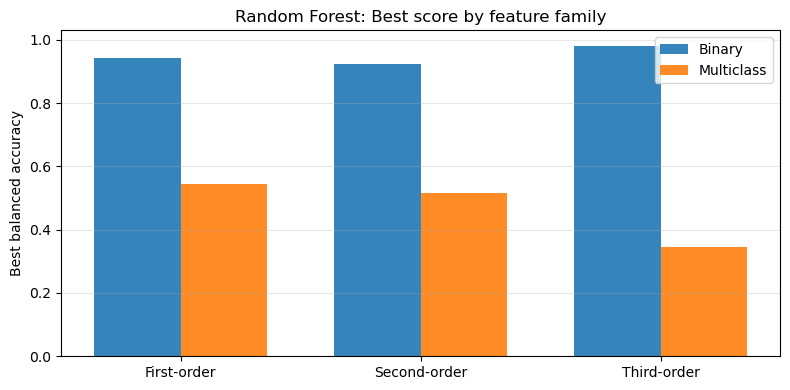

/var/folders/8_/ky643qs168ngjmhrpwcq1fdm0000gn/T/ipykernel_58070/197777593.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot(bin_data, labels=bin_labels, patch_artist=True)
/var/folders/8_/ky643qs168ngjmhrpwcq1fdm0000gn/T/ipykernel_58070/197777593.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(mul_data, labels=mul_labels, patch_artist=True)


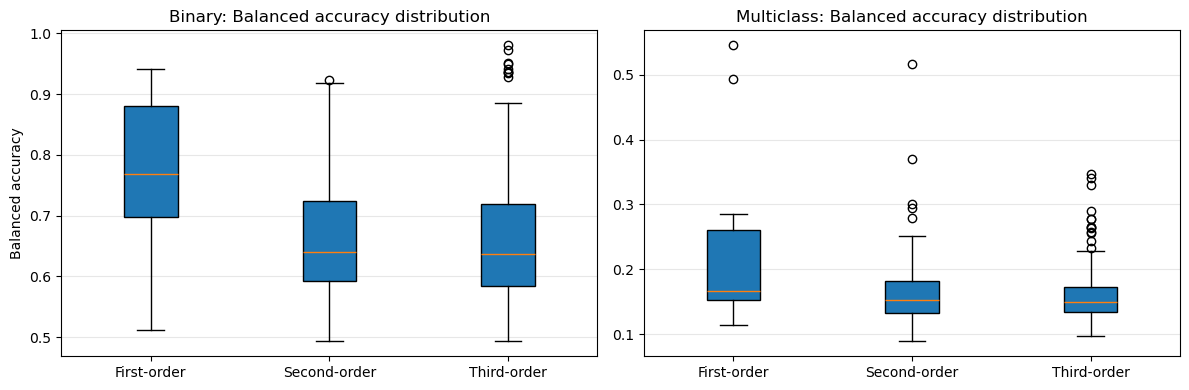

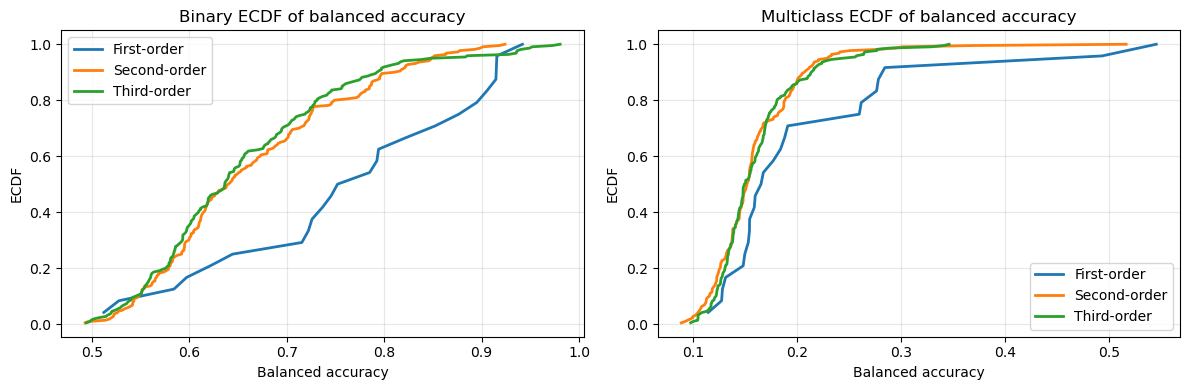

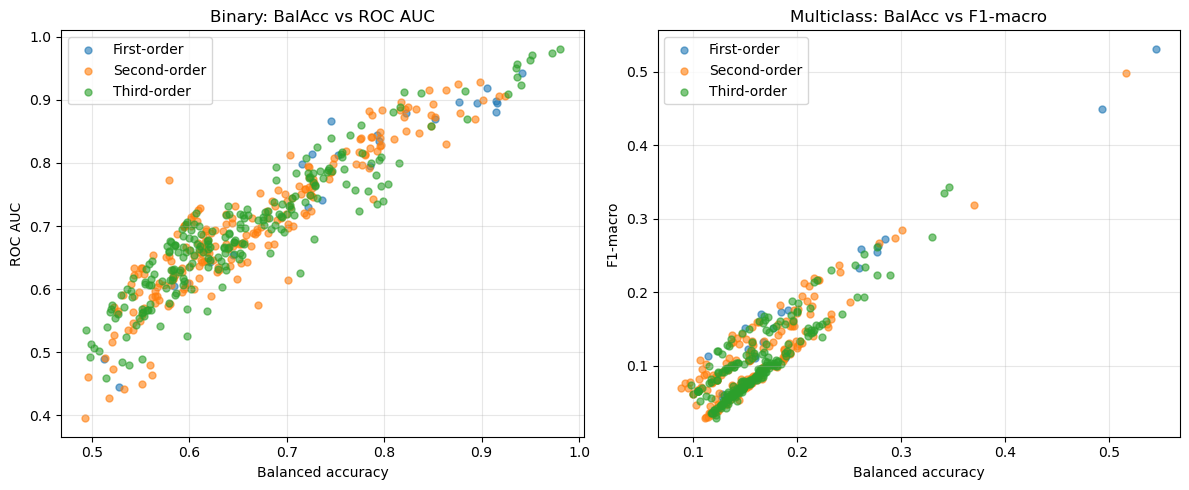

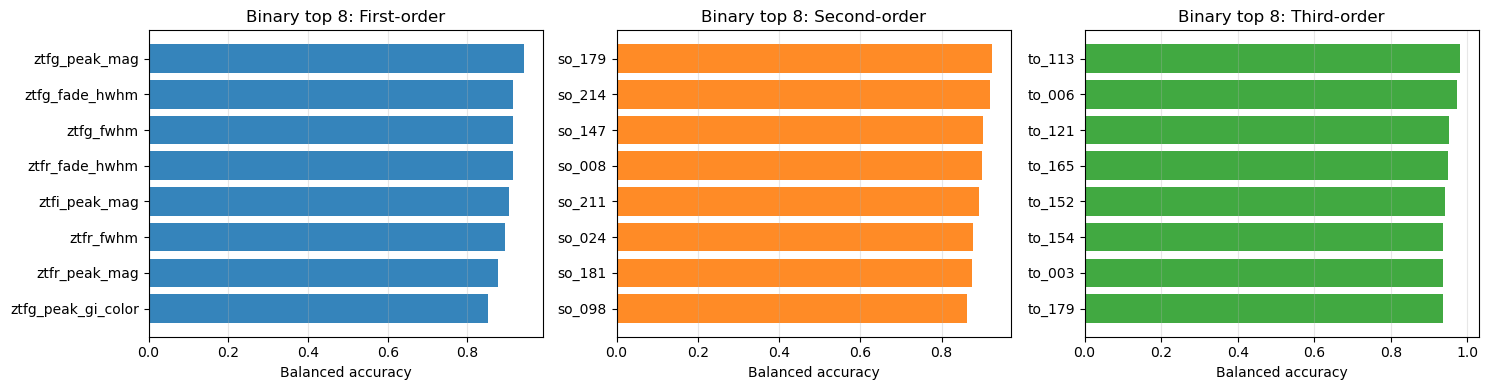

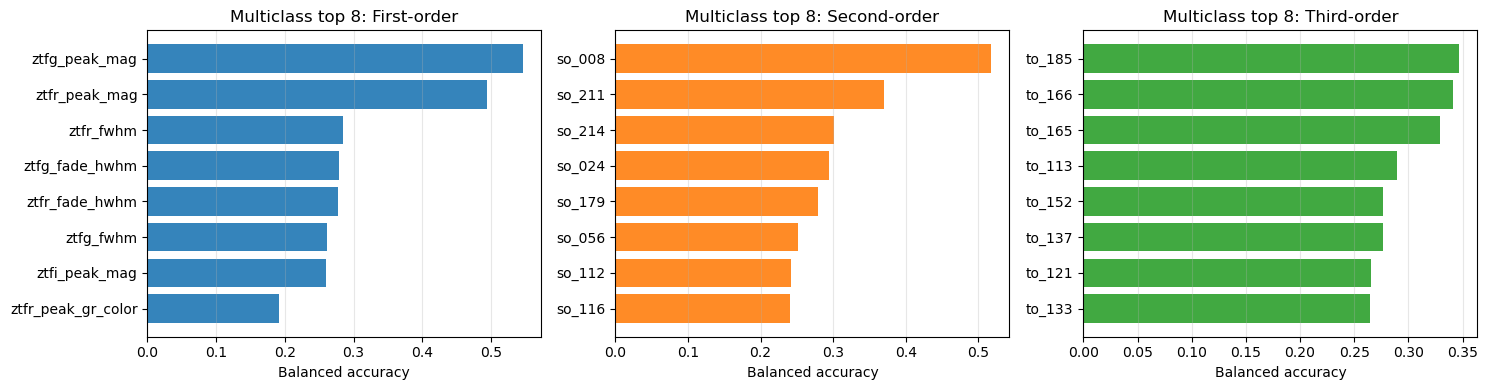

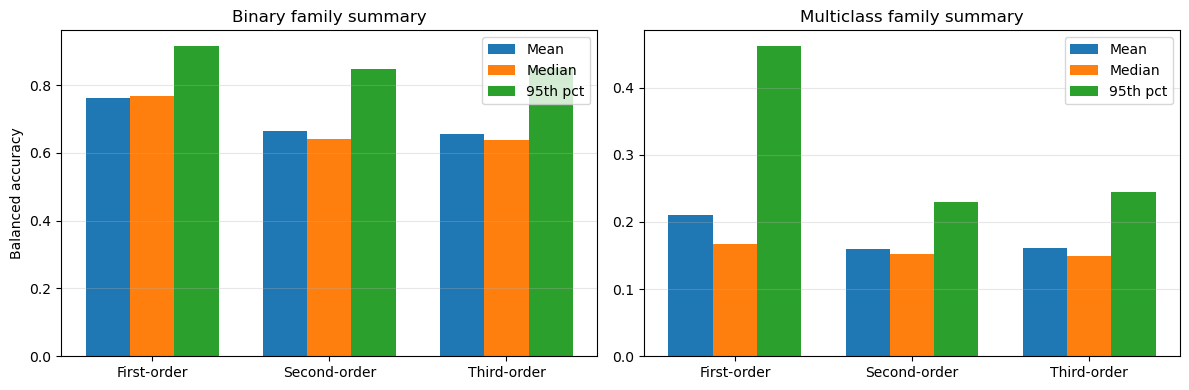

In [22]:
# Random Forest: comparison plots for first-, second-, and third-order metrics

required_rf = ["rf_binary_results", "rf_multi_results"]
missing_rf = [v for v in required_rf if v not in globals()]
if missing_rf:
    raise ValueError(f"Missing required RF results: {missing_rf}")

def _prep_family(df, family_name, task_name, aux_col):
    if df is None or len(df) == 0:
        return None
    d = df.copy()
    if "metric" in d.columns and "feature" not in d.columns:
        d = d.rename(columns={"metric": "feature"})
    if "feature" not in d.columns or "balanced_acc_mean" not in d.columns:
        return None
    if aux_col not in d.columns:
        d[aux_col] = np.nan
    if "expr" not in d.columns:
        d["expr"] = d["feature"]
    d["family"] = family_name
    d["task"] = task_name
    return d

# Build tidy comparison tables
bin_frames = [
    _prep_family(globals().get("rf_binary_results"), "First-order", "Binary", "roc_auc_mean"),
    _prep_family(globals().get("rf_second_order_binary"), "Second-order", "Binary", "roc_auc_mean"),
    _prep_family(globals().get("rf_third_order_binary"), "Third-order", "Binary", "roc_auc_mean"),
]
mul_frames = [
    _prep_family(globals().get("rf_multi_results"), "First-order", "Multiclass", "f1_macro_mean"),
    _prep_family(globals().get("rf_second_order_multi"), "Second-order", "Multiclass", "f1_macro_mean"),
    _prep_family(globals().get("rf_third_order_multi"), "Third-order", "Multiclass", "f1_macro_mean"),
]

rf_comp_binary = pd.concat([d for d in bin_frames if d is not None], ignore_index=True)
rf_comp_multi = pd.concat([d for d in mul_frames if d is not None], ignore_index=True)

if rf_comp_binary.empty or rf_comp_multi.empty:
    raise ValueError("No RF comparison data available for binary or multiclass task.")

family_order = ["First-order", "Second-order", "Third-order"]
colors = {"First-order": "tab:blue", "Second-order": "tab:orange", "Third-order": "tab:green"}

# ----------------------------
# Plot 1: Best score by family (both tasks)
# ----------------------------
best_bin = rf_comp_binary.groupby("family", as_index=False)["balanced_acc_mean"].max()
best_mul = rf_comp_multi.groupby("family", as_index=False)["balanced_acc_mean"].max()

best_bin["family"] = pd.Categorical(best_bin["family"], categories=family_order, ordered=True)
best_mul["family"] = pd.Categorical(best_mul["family"], categories=family_order, ordered=True)
best_bin = best_bin.sort_values("family")
best_mul = best_mul.sort_values("family")

x = np.arange(len(best_bin))
w = 0.36

plt.figure(figsize=(8, 4))
plt.bar(x - w/2, best_bin["balanced_acc_mean"], width=w, label="Binary", alpha=0.9)
plt.bar(x + w/2, best_mul["balanced_acc_mean"], width=w, label="Multiclass", alpha=0.9)
plt.xticks(x, best_bin["family"])
plt.ylabel("Best balanced accuracy")
plt.title("Random Forest: Best score by feature family")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: Boxplot distributions by family (binary + multiclass)
# ----------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

bin_data = [rf_comp_binary.loc[rf_comp_binary["family"] == f, "balanced_acc_mean"].dropna().values for f in family_order if f in rf_comp_binary["family"].unique()]
bin_labels = [f for f in family_order if f in rf_comp_binary["family"].unique()]
ax[0].boxplot(bin_data, labels=bin_labels, patch_artist=True)
ax[0].set_title("Binary: Balanced accuracy distribution")
ax[0].set_ylabel("Balanced accuracy")
ax[0].grid(axis="y", alpha=0.3)

mul_data = [rf_comp_multi.loc[rf_comp_multi["family"] == f, "balanced_acc_mean"].dropna().values for f in family_order if f in rf_comp_multi["family"].unique()]
mul_labels = [f for f in family_order if f in rf_comp_multi["family"].unique()]
ax[1].boxplot(mul_data, labels=mul_labels, patch_artist=True)
ax[1].set_title("Multiclass: Balanced accuracy distribution")
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 3: ECDF curves (binary + multiclass)
# ----------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for fam in family_order:
    d = rf_comp_binary.loc[rf_comp_binary["family"] == fam, "balanced_acc_mean"].dropna().values
    if len(d) == 0:
        continue
    xs = np.sort(d)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax[0].plot(xs, ys, label=fam, color=colors[fam], lw=2)
ax[0].set_title("Binary ECDF of balanced accuracy")
ax[0].set_xlabel("Balanced accuracy")
ax[0].set_ylabel("ECDF")
ax[0].grid(alpha=0.3)
ax[0].legend()

for fam in family_order:
    d = rf_comp_multi.loc[rf_comp_multi["family"] == fam, "balanced_acc_mean"].dropna().values
    if len(d) == 0:
        continue
    xs = np.sort(d)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax[1].plot(xs, ys, label=fam, color=colors[fam], lw=2)
ax[1].set_title("Multiclass ECDF of balanced accuracy")
ax[1].set_xlabel("Balanced accuracy")
ax[1].set_ylabel("ECDF")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 4: Balanced accuracy vs auxiliary metric
# ----------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for fam in family_order:
    d = rf_comp_binary[rf_comp_binary["family"] == fam]
    if len(d) == 0:
        continue
    ax[0].scatter(d["balanced_acc_mean"], d["roc_auc_mean"], alpha=0.6, s=25, label=fam, color=colors[fam])
ax[0].set_title("Binary: BalAcc vs ROC AUC")
ax[0].set_xlabel("Balanced accuracy")
ax[0].set_ylabel("ROC AUC")
ax[0].grid(alpha=0.3)
ax[0].legend()

for fam in family_order:
    d = rf_comp_multi[rf_comp_multi["family"] == fam]
    if len(d) == 0:
        continue
    ax[1].scatter(d["balanced_acc_mean"], d["f1_macro_mean"], alpha=0.6, s=25, label=fam, color=colors[fam])
ax[1].set_title("Multiclass: BalAcc vs F1-macro")
ax[1].set_xlabel("Balanced accuracy")
ax[1].set_ylabel("F1-macro")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 5: Top-k horizontal bars by family (binary)
# ----------------------------
k_show = 8
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)

for i, fam in enumerate(family_order):
    d = rf_comp_binary[rf_comp_binary["family"] == fam].sort_values("balanced_acc_mean", ascending=False).head(k_show).iloc[::-1]
    if len(d) == 0:
        axes[i].set_visible(False)
        continue
    axes[i].barh(d["feature"], d["balanced_acc_mean"], color=colors[fam], alpha=0.9)
    axes[i].set_title(f"Binary top {k_show}: {fam}")
    axes[i].set_xlabel("Balanced accuracy")
    axes[i].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 6: Top-k horizontal bars by family (multiclass)
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)

for i, fam in enumerate(family_order):
    d = rf_comp_multi[rf_comp_multi["family"] == fam].sort_values("balanced_acc_mean", ascending=False).head(k_show).iloc[::-1]
    if len(d) == 0:
        axes[i].set_visible(False)
        continue
    axes[i].barh(d["feature"], d["balanced_acc_mean"], color=colors[fam], alpha=0.9)
    axes[i].set_title(f"Multiclass top {k_show}: {fam}")
    axes[i].set_xlabel("Balanced accuracy")
    axes[i].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 7: Family-level summary bars (mean, median, 95th percentile)
# ----------------------------
def _family_summary(df):
    return (
        df.groupby("family", as_index=False)["balanced_acc_mean"]
        .agg(mean="mean", median="median", p95=lambda x: np.nanpercentile(x, 95))
    )

sum_bin = _family_summary(rf_comp_binary)
sum_mul = _family_summary(rf_comp_multi)

for s in [sum_bin, sum_mul]:
    s["family"] = pd.Categorical(s["family"], categories=family_order, ordered=True)
    s.sort_values("family", inplace=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

xb = np.arange(len(sum_bin))
ax[0].bar(xb - 0.25, sum_bin["mean"], width=0.25, label="Mean")
ax[0].bar(xb,         sum_bin["median"], width=0.25, label="Median")
ax[0].bar(xb + 0.25,  sum_bin["p95"], width=0.25, label="95th pct")
ax[0].set_xticks(xb)
ax[0].set_xticklabels(sum_bin["family"])
ax[0].set_title("Binary family summary")
ax[0].set_ylabel("Balanced accuracy")
ax[0].grid(axis="y", alpha=0.3)
ax[0].legend()

xm = np.arange(len(sum_mul))
ax[1].bar(xm - 0.25, sum_mul["mean"], width=0.25, label="Mean")
ax[1].bar(xm,         sum_mul["median"], width=0.25, label="Median")
ax[1].bar(xm + 0.25,  sum_mul["p95"], width=0.25, label="95th pct")
ax[1].set_xticks(xm)
ax[1].set_xticklabels(sum_mul["family"])
ax[1].set_title("Multiclass family summary")
ax[1].grid(axis="y", alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

# Keep summary tables for later cells
rf_family_summary_binary = sum_bin.reset_index(drop=True)
rf_family_summary_multi = sum_mul.reset_index(drop=True)

<a id="xgboost"></a>
# Extreme Gradient Boosting

Best XGB binary params: {'xgb__subsample': 0.7, 'xgb__reg_lambda': 3.0, 'xgb__n_estimators': 250, 'xgb__min_child_weight': 1, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.1, 'xgb__gamma': 0.25, 'xgb__colsample_bytree': 0.7} | best CV score: 0.9951
Best XGB multiclass params: {'xgb__subsample': 0.85, 'xgb__reg_lambda': 1.0, 'xgb__n_estimators': 600, 'xgb__min_child_weight': 1, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.08, 'xgb__gamma': 0.0, 'xgb__colsample_bytree': 0.85} | best CV score: 0.4135

Top XGBoost single-feature metrics (binary):


,feature,balanced_acc_mean,roc_auc_mean
0,ztfg_peak_mag,0.944250,0.968370
1,ztfi_peak_mag,0.915946,0.955583
2,ztfg_fade_hwhm,0.908370,0.954916
3,ztfr_peak_mag,0.903621,0.961162
4,ztfi_peak_gi_color,0.902263,0.954755
5,ztfg_fwhm,0.898745,0.950471
6,ztfr_fade_hwhm,0.875829,0.912399
7,ztfg_peak_gi_color,0.874857,0.946990
8,ztfr_fwhm,0.865945,0.927492
9,ztfr_peak_gr_color,0.862871,0.911351



Top XGBoost single-feature metrics (multiclass):


,feature,balanced_acc_mean,f1_macro_mean
0,ztfg_peak_mag,0.384565,0.317147
1,ztfr_peak_mag,0.383537,0.322971
2,ztfg_fade_hwhm,0.278571,0.255376
3,ztfr_fwhm,0.251455,0.237160
4,ztfr_fade_hwhm,0.236859,0.229716
5,ztfg_fwhm,0.212169,0.200666
6,ztfi_peak_mag,0.208397,0.174210
7,ztfi_peak_gi_color,0.178386,0.152156
8,ztfg_peak_gi_color,0.171232,0.143338
9,ztfr_peak_ri_color,0.166500,0.144373



Top XGBoost second-order features (binary):


...

,feature,balanced_acc_mean,balanced_acc_std,f1_macro_mean,f1_macro_std,expr,template,n_terms,early_score
0,so_008,0.338193,0.032052,0.294719,0.029624,ztfg_peak_mag*ztfr_peak_mag,mul,2,0.600000
1,so_024,0.318352,0.054898,0.270947,0.026693,ztfr_fwhm*ztfr_peak_mag,mul,2,0.500000
2,so_179,0.259062,0.013148,0.227424,0.028655,(ztfg_peak_gr_color-ztfr_peak_mag)/|ztfg_fwhm|,diff_ratio,3,0.516667
3,so_211,0.244852,0.016235,0.214236,0.020746,(ztfr_fwhm+ztfr_peak_mag)/|ztfg_fwhm|,sum_ratio,3,0.416667
4,so_209,0.230495,0.037338,0.210909,0.034436,(ztfr_fade_rate*ztfg_fade_hwhm)/|ztfg_fwhm|,mul_ratio,3,0.283333
5,so_214,0.229504,0.051886,0.203720,0.025156,ztfg_fade_hwhm*ztfr_peak_mag,mul,2,0.500000
6,so_082,0.212313,0.070547,0.189355,0.042359,ztfg_peak_gr_color/|ztfg_rise_hwhm|,ratio,2,0.825000
7,so_116,0.212176,0.034828,0.200421,0.029225,ztfg_peak_mag/|ztfr_peak_mag|,ratio,2,0.600000
8,so_124,0.211866,0.029650,0.208529,0.026208,(ztfg_peak_gr_color+ztfr_peak_gr_color)/|ztfr_peak_mag|,sum_ratio,3,0.616667
9,so_118,0.204732,0.076076,0.197081,0.064697,ztfg_rise_hwhm*ztfg_fwhm,mul,2,0.675000



Top XGBoost third-order features (binary):


,feature,balanced_acc_mean,balanced_acc_std,roc_auc_mean,roc_auc_std,expr,template,n_terms,early_score,m1,m2,m3
0,to_006,0.982617,0.017714,0.990508,0.010093,(ztfi_peak_mag+ztfr_peak_gr_color+ztfr_fade_rate)/3,tri_mean,3,0.450000,ztfi_peak_mag,ztfr_peak_gr_color,ztfr_fade_rate
1,to_113,0.975499,0.014628,0.991022,0.009593,(ztfi_fade_rate+ztfi_peak_ri_color+ztfg_peak_mag)/3,tri_mean,3,0.450000,ztfi_fade_rate,ztfi_peak_ri_color,ztfg_peak_mag
2,to_121,0.973909,0.022744,0.976158,0.024147,(ztfg_peak_mag*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_gi_color+ztfg_peak_gi_color*ztfg_peak_mag)/(|a|+|b|+|c|),tri_pairmix,3,0.583333,ztfg_peak_mag,ztfr_peak_mag,ztfg_peak_gi_color
3,to_165,0.967673,0.015064,0.983766,0.016652,(ztfg_peak_mag*ztfr_peak_ri_color+ztfr_peak_ri_color*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_mag)/(|a|+|b|+|c|),tri_pairmix,3,0.583333,ztfg_peak_mag,ztfr_peak_ri_color,ztfr_peak_mag
4,to_003,0.949128,0.043813,0.947997,0.044537,ztfg_fade_hwhm*ztfg_fade_rate*ztfr_fade_hwhm,tri_mul,3,0.283333,ztfg_fade_hwhm,ztfg_fade_rate,ztfr_fade_hwhm
5,to_179,0.945190,0.044547,0.960273,0.042071,sign(ztfg_fwhm*ztfg_fade_rate*ztfr_fwhm)*cuberoot(|...|),tri_signed_geom,3,0.283333,ztfg_fwhm,ztfg_fade_rate,ztfr_fwhm
6,to_152,0.939140,0.028882,0.977040,0.022607,((ztfr_peak_mag-ztfg_peak_gr_color)*ztfg_fwhm)/(|a|+|b|+|c|),tri_contrast,3,0.516667,ztfr_peak_mag,ztfg_peak_gr_color,ztfg_fwhm
7,to_154,0.927236,0.038093,0.943401,0.043847,(ztfr_peak_gr_color*ztfg_fade_rate+ztfg_fade_rate*ztfi_peak_mag+ztfi_peak_mag*ztfr_peak_gr_color)/(|a|+|b|+|c|),tri_pairmix,3,0.450000,ztfr_peak_gr_color,ztfg_fade_rate,ztfi_peak_mag
8,to_138,0.924946,0.034241,0.926453,0.041458,(ztfr_peak_gr_color*ztfi_peak_mag)/|ztfr_fade_rate|,tri_ratio_prod,3,0.450000,ztfr_peak_gr_color,ztfi_peak_mag,ztfr_fade_rate
9,to_098,0.921296,0.036379,0.973993,0.020920,(ztfi_peak_gi_color*ztfr_peak_gr_color+ztfr_peak_gr_color*ztfr_fade_rate+ztfr_fade_rate*ztfi_peak_gi_color)/(|a|+|b|...,tri_pairmix,3,0.483333,ztfi_peak_gi_color,ztfr_peak_gr_color,ztfr_fade_rate



Top XGBoost third-order features (multiclass):


,feature,balanced_acc_mean,balanced_acc_std,f1_macro_mean,f1_macro_std,expr,template,n_terms,early_score,m1,m2,m3
0,to_166,0.332668,0.039812,0.275347,0.016042,(ztfr_peak_mag+ztfg_fade_rate+ztfr_fade_hwhm)/3,tri_mean,3,0.350000,ztfr_peak_mag,ztfg_fade_rate,ztfr_fade_hwhm
1,to_185,0.308964,0.045889,0.254475,0.026775,(ztfr_fade_hwhm+ztfg_peak_gr_color+ztfg_peak_mag)/3,tri_mean,3,0.516667,ztfr_fade_hwhm,ztfg_peak_gr_color,ztfg_peak_mag
2,to_157,0.279701,0.044566,0.240692,0.035025,(ztfg_peak_gr_color+ztfg_fwhm+ztfr_peak_mag)/3,tri_mean,3,0.516667,ztfg_peak_gr_color,ztfg_fwhm,ztfr_peak_mag
3,to_152,0.247146,0.037702,0.213749,0.020971,((ztfr_peak_mag-ztfg_peak_gr_color)*ztfg_fwhm)/(|a|+|b|+|c|),tri_contrast,3,0.516667,ztfr_peak_mag,ztfg_peak_gr_color,ztfg_fwhm
4,to_052,0.241795,0.038475,0.213294,0.022872,(ztfg_fade_hwhm*ztfg_fwhm+ztfg_fwhm*ztfg_peak_mag+ztfg_peak_mag*ztfg_fade_hwhm)/(|a|+|b|+|c|),tri_pairmix,3,0.416667,ztfg_fade_hwhm,ztfg_fwhm,ztfg_peak_mag
5,to_112,0.225306,0.041293,0.219749,0.039844,ztfr_peak_gr_color*ztfr_peak_mag*ztfr_fwhm,tri_mul,3,0.516667,ztfr_peak_gr_color,ztfr_peak_mag,ztfr_fwhm
6,to_006,0.219916,0.022989,0.175511,0.017518,(ztfi_peak_mag+ztfr_peak_gr_color+ztfr_fade_rate)/3,tri_mean,3,0.450000,ztfi_peak_mag,ztfr_peak_gr_color,ztfr_fade_rate
7,to_113,0.218480,0.022247,0.177587,0.015972,(ztfi_fade_rate+ztfi_peak_ri_color+ztfg_peak_mag)/3,tri_mean,3,0.450000,ztfi_fade_rate,ztfi_peak_ri_color,ztfg_peak_mag
8,to_121,0.217815,0.035735,0.173992,0.024634,(ztfg_peak_mag*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_gi_color+ztfg_peak_gi_color*ztfg_peak_mag)/(|a|+|b|+|c|),tri_pairmix,3,0.583333,ztfg_peak_mag,ztfr_peak_mag,ztfg_peak_gi_color
9,to_165,0.210808,0.037143,0.174689,0.028204,(ztfg_peak_mag*ztfr_peak_ri_color+ztfr_peak_ri_color*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_mag)/(|a|+|b|+|c|),tri_pairmix,3,0.583333,ztfg_peak_mag,ztfr_peak_ri_color,ztfr_peak_mag


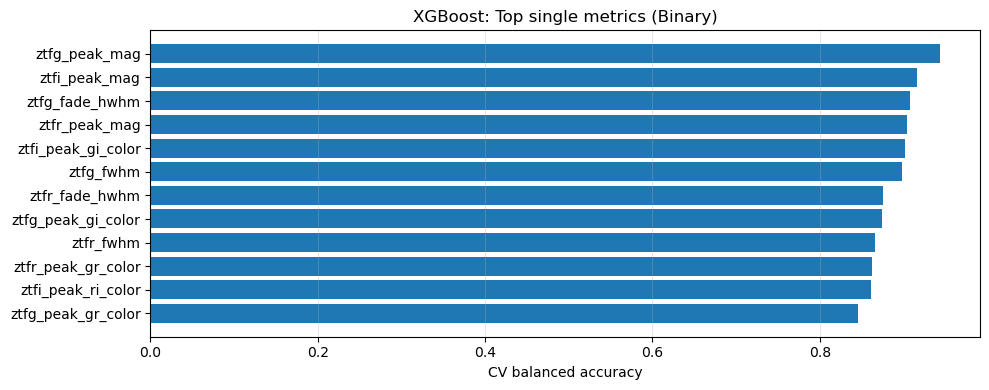

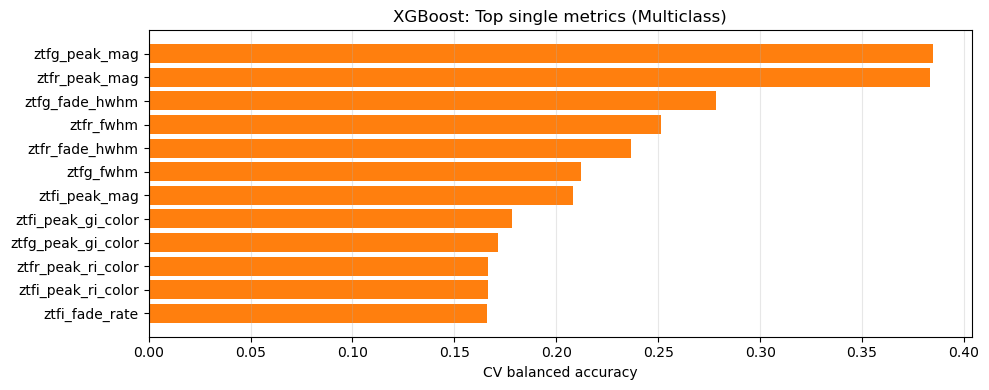


Best balanced-accuracy comparison:


,model,task,best_balanced_acc
0,XGBoost,Binary,0.944250
1,RandomForest,Binary,0.941819
2,KNN,Binary,0.784277
3,RandomForest,Multiclass,0.545729
4,KNN,Multiclass,0.543027
5,XGBoost,Multiclass,0.384565


In [20]:
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# XGBoost: tuned single-feature analysis (binary + multiclass), with optional 2nd/3rd-order evaluation



def _make_cv_xgb(y, max_splits=5, n_repeats=3, random_state=42):
    min_count = pd.Series(y).value_counts().min()
    n_splits = max(2, min(max_splits, int(min_count)))
    return RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)


def _base_xgb(mode="binary", random_state=42, scale_pos_weight=1.0, num_class=None):
    params = dict(
        tree_method="hist",
        n_jobs=-1,
        random_state=random_state,
        learning_rate=0.05,
        n_estimators=400,
        max_depth=4,
        min_child_weight=1,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        gamma=0.0
    )
    if mode == "binary":
        params.update(objective="binary:logistic", eval_metric="auc", scale_pos_weight=scale_pos_weight)
    else:
        params.update(objective="multi:softprob", eval_metric="mlogloss", num_class=num_class)
    return XGBClassifier(**params)


def _tune_xgb(X_df, y, mode="binary", random_state=42):
    cv = _make_cv_xgb(y, max_splits=5, n_repeats=2, random_state=random_state)

    if mode == "binary":
        pos = int(np.sum(np.asarray(y) == 1))
        neg = int(np.sum(np.asarray(y) == 0))
        spw = (neg / max(pos, 1))
        model = _base_xgb(mode="binary", random_state=random_state, scale_pos_weight=spw)
        scoring = "roc_auc"
    else:
        n_cls = int(pd.Series(y).nunique())
        model = _base_xgb(mode="multiclass", random_state=random_state, num_class=n_cls)
        scoring = "balanced_accuracy"

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", model)
    ])

    # Randomized search for efficiency vs full grid
    param_dist = {
        "xgb__n_estimators": [250, 400, 600],
        "xgb__max_depth": [3, 4, 5, 6],
        "xgb__learning_rate": [0.03, 0.05, 0.08, 0.1],
        "xgb__min_child_weight": [1, 3, 5],
        "xgb__subsample": [0.7, 0.85, 1.0],
        "xgb__colsample_bytree": [0.7, 0.85, 1.0],
        "xgb__gamma": [0.0, 0.25, 1.0],
        "xgb__reg_lambda": [1.0, 3.0, 10.0],
    }

    rs = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=24,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        random_state=random_state,
        refit=True
    )
    rs.fit(X_df, y)
    return rs.best_params_, rs.best_score_


def _eval_single_feature_xgb(X_df, y, mode, best_params, random_state=42):
    if mode == "binary":
        pos = int(np.sum(np.asarray(y) == 1))
        neg = int(np.sum(np.asarray(y) == 0))
        base_model = _base_xgb(mode="binary", random_state=random_state, scale_pos_weight=(neg / max(pos, 1)))
        scoring = {"bal_acc": "balanced_accuracy", "roc_auc": "roc_auc"}
        cv = _make_cv_xgb(y, max_splits=5, n_repeats=3, random_state=123)
    else:
        n_cls = int(pd.Series(y).nunique())
        base_model = _base_xgb(mode="multiclass", random_state=random_state, num_class=n_cls)
        scoring = {"bal_acc": "balanced_accuracy", "f1_macro": "f1_macro"}
        cv = _make_cv_xgb(y, max_splits=5, n_repeats=3, random_state=123)

    tuned = {k.replace("xgb__", ""): v for k, v in best_params.items()}
    base_model.set_params(**tuned)

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", base_model)
    ])

    rows = []
    for col in X_df.columns:
        scores = cross_validate(
            pipe,
            X_df[[col]],
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            error_score=np.nan
        )

        row = {
            "feature": col,
            "balanced_acc_mean": np.nanmean(scores["test_bal_acc"]),
            "balanced_acc_std": np.nanstd(scores["test_bal_acc"]),
        }

        if mode == "binary":
            row["roc_auc_mean"] = np.nanmean(scores["test_roc_auc"])
            row["roc_auc_std"] = np.nanstd(scores["test_roc_auc"])
        else:
            row["f1_macro_mean"] = np.nanmean(scores["test_f1_macro"])
            row["f1_macro_std"] = np.nanstd(scores["test_f1_macro"])

        rows.append(row)

    return pd.DataFrame(rows).sort_values("balanced_acc_mean", ascending=False).reset_index(drop=True)


# -----------------------------
# 1) Tune on original features
# -----------------------------
X_orig = X_all[common_numeric].copy()
y_bin_local = np.asarray(y_bin).astype(int)

le_multi = LabelEncoder()
y_multi_enc = le_multi.fit_transform(y_multi.astype(str))

xgb_best_bin_params, xgb_best_bin_score = _tune_xgb(X_orig, y_bin_local, mode="binary", random_state=42)
xgb_best_multi_params, xgb_best_multi_score = _tune_xgb(X_orig, y_multi_enc, mode="multiclass", random_state=42)

print("Best XGB binary params:", xgb_best_bin_params, "| best CV score:", round(xgb_best_bin_score, 4))
print("Best XGB multiclass params:", xgb_best_multi_params, "| best CV score:", round(xgb_best_multi_score, 4))

# -----------------------------
# 2) Evaluate original metrics
# -----------------------------
xgb_binary_results = _eval_single_feature_xgb(
    X_orig, y_bin_local, mode="binary", best_params=xgb_best_bin_params, random_state=42
)
xgb_multi_results = _eval_single_feature_xgb(
    X_orig, y_multi_enc, mode="multiclass", best_params=xgb_best_multi_params, random_state=42
)

print("\nTop XGBoost single-feature metrics (binary):")
display(xgb_binary_results.head(15)[["feature", "balanced_acc_mean", "roc_auc_mean"]])

print("\nTop XGBoost single-feature metrics (multiclass):")
display(xgb_multi_results.head(15)[["feature", "balanced_acc_mean", "f1_macro_mean"]])

# -----------------------------
# 3) Optional: second-order features
# -----------------------------
if "second_order_metrics" in globals():
    xgb_second_order_binary = _eval_single_feature_xgb(
        second_order_metrics, y_bin_local, mode="binary", best_params=xgb_best_bin_params, random_state=42
    )
    xgb_second_order_multi = _eval_single_feature_xgb(
        second_order_metrics, y_multi_enc, mode="multiclass", best_params=xgb_best_multi_params, random_state=42
    )

    if "second_order_meta" in globals():
        xgb_second_order_binary = xgb_second_order_binary.merge(second_order_meta, on="feature", how="left")
        xgb_second_order_multi = xgb_second_order_multi.merge(second_order_meta, on="feature", how="left")

    print("\nTop XGBoost second-order features (binary):")
    display(xgb_second_order_binary.head(10))

    print("\nTop XGBoost second-order features (multiclass):")
    display(xgb_second_order_multi.head(10))

# -----------------------------
# 4) Optional: third-order features
# -----------------------------
if "third_order_metrics" in globals():
    xgb_third_order_binary = _eval_single_feature_xgb(
        third_order_metrics, y_bin_local, mode="binary", best_params=xgb_best_bin_params, random_state=42
    )
    xgb_third_order_multi = _eval_single_feature_xgb(
        third_order_metrics, y_multi_enc, mode="multiclass", best_params=xgb_best_multi_params, random_state=42
    )

    if "third_order_meta" in globals():
        xgb_third_order_binary = xgb_third_order_binary.merge(third_order_meta, on="feature", how="left")
        xgb_third_order_multi = xgb_third_order_multi.merge(third_order_meta, on="feature", how="left")

    print("\nTop XGBoost third-order features (binary):")
    display(xgb_third_order_binary.head(10))

    print("\nTop XGBoost third-order features (multiclass):")
    display(xgb_third_order_multi.head(10))

# -----------------------------
# 5) Compact plots
# -----------------------------
top_n = 12

plt.figure(figsize=(10, 4))
tmp = xgb_binary_results.head(top_n).iloc[::-1]
plt.barh(tmp["feature"], tmp["balanced_acc_mean"])
plt.xlabel("CV balanced accuracy")
plt.title("XGBoost: Top single metrics (Binary)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
tmp = xgb_multi_results.head(top_n).iloc[::-1]
plt.barh(tmp["feature"], tmp["balanced_acc_mean"], color="tab:orange")
plt.xlabel("CV balanced accuracy")
plt.title("XGBoost: Top single metrics (Multiclass)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Optional: quick method comparison at best-balanced-accuracy level
# -----------------------------
compare_rows = []

if "binary_results" in globals():
    compare_rows.append(("KNN", "Binary", float(binary_results["balanced_acc_mean"].max())))
if "rf_binary_results" in globals():
    compare_rows.append(("RandomForest", "Binary", float(rf_binary_results["balanced_acc_mean"].max())))
compare_rows.append(("XGBoost", "Binary", float(xgb_binary_results["balanced_acc_mean"].max())))

if "multi_results" in globals():
    compare_rows.append(("KNN", "Multiclass", float(multi_results["balanced_acc_mean"].max())))
if "rf_multi_results" in globals():
    compare_rows.append(("RandomForest", "Multiclass", float(rf_multi_results["balanced_acc_mean"].max())))
compare_rows.append(("XGBoost", "Multiclass", float(xgb_multi_results["balanced_acc_mean"].max())))

method_comparison = pd.DataFrame(compare_rows, columns=["model", "task", "best_balanced_acc"])
print("\nBest balanced-accuracy comparison:")
display(method_comparison.sort_values(["task", "best_balanced_acc"], ascending=[True, False]).reset_index(drop=True))

=== XGBoost family summary: Binary ===


,family,n_features,bal_mean,bal_median,bal_p95,aux_mean,early_mean,best_bal
0,First-order,24,0.779998,0.835465,0.914809,0.825086,0.662500,0.944250
1,Second-order,220,0.693353,0.672788,0.887646,0.743218,0.610189,0.948156
2,Third-order,220,0.671344,0.645121,0.892086,0.719535,0.549924,0.982617


=== XGBoost family summary: Multiclass ===


,family,n_features,bal_mean,bal_median,bal_p95,aux_mean,early_mean,best_bal
0,First-order,24,0.180028,0.166182,0.367792,0.165137,0.662500,0.384565
1,Second-order,220,0.133777,0.121589,0.202620,0.126339,0.610189,0.338193
2,Third-order,220,0.130985,0.118473,0.207222,0.124516,0.549924,0.332668


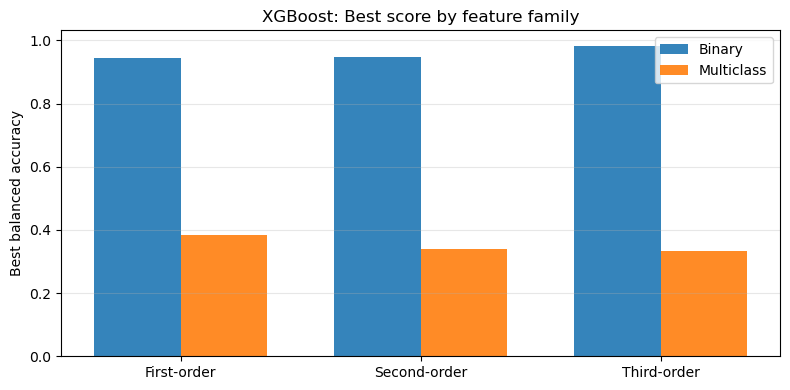

/var/folders/8_/ky643qs168ngjmhrpwcq1fdm0000gn/T/ipykernel_58070/1439441667.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot(bin_data, labels=bin_labels, patch_artist=True)
/var/folders/8_/ky643qs168ngjmhrpwcq1fdm0000gn/T/ipykernel_58070/1439441667.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(mul_data, labels=mul_labels, patch_artist=True)


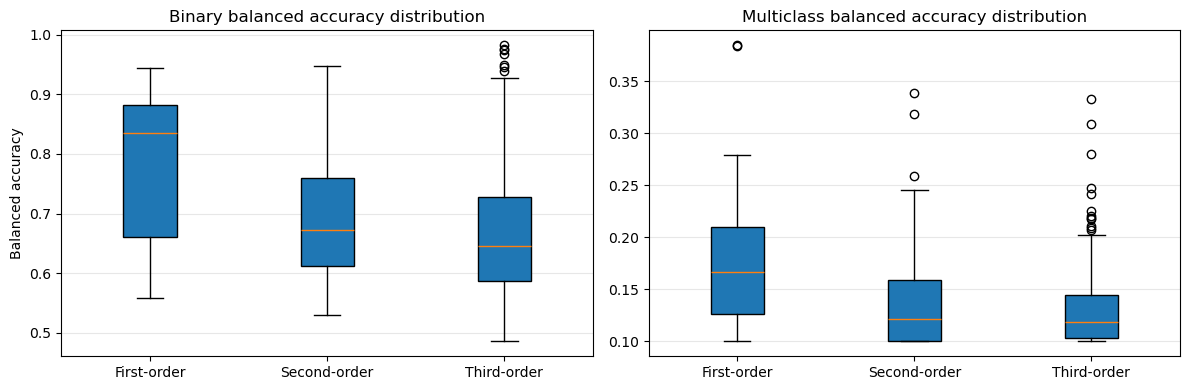

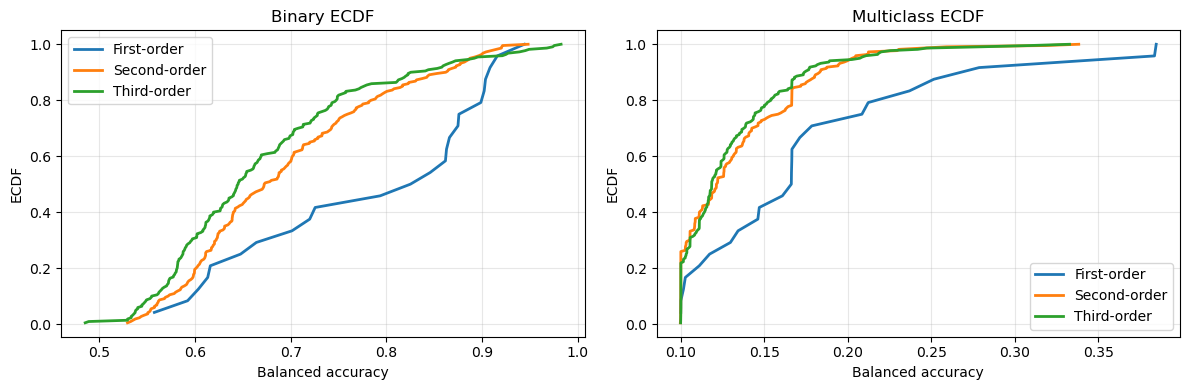

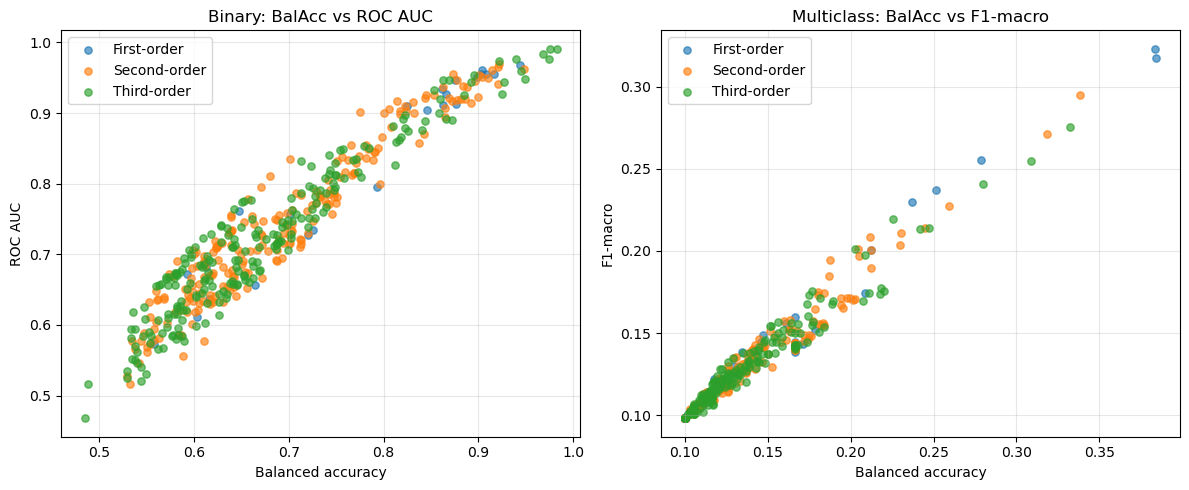

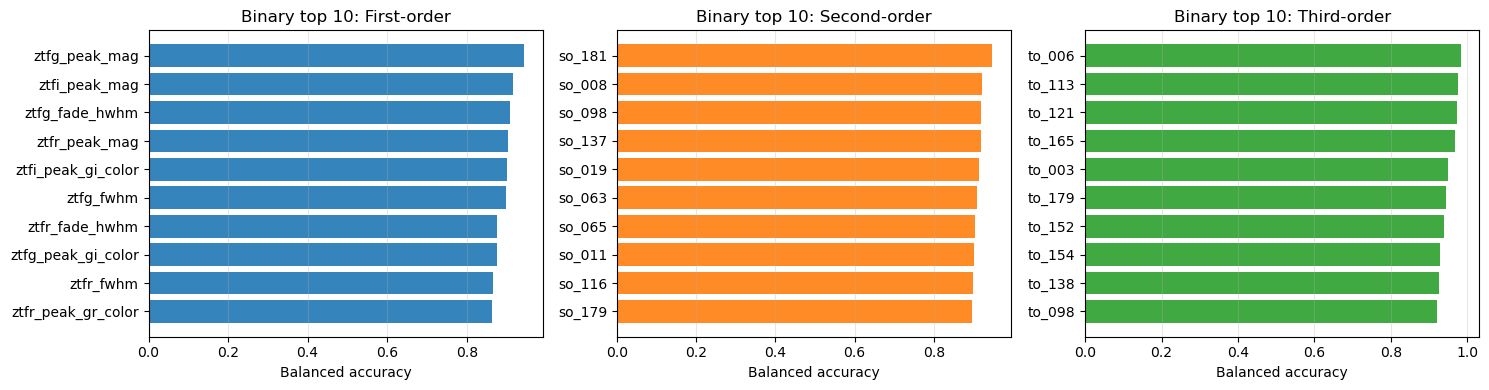

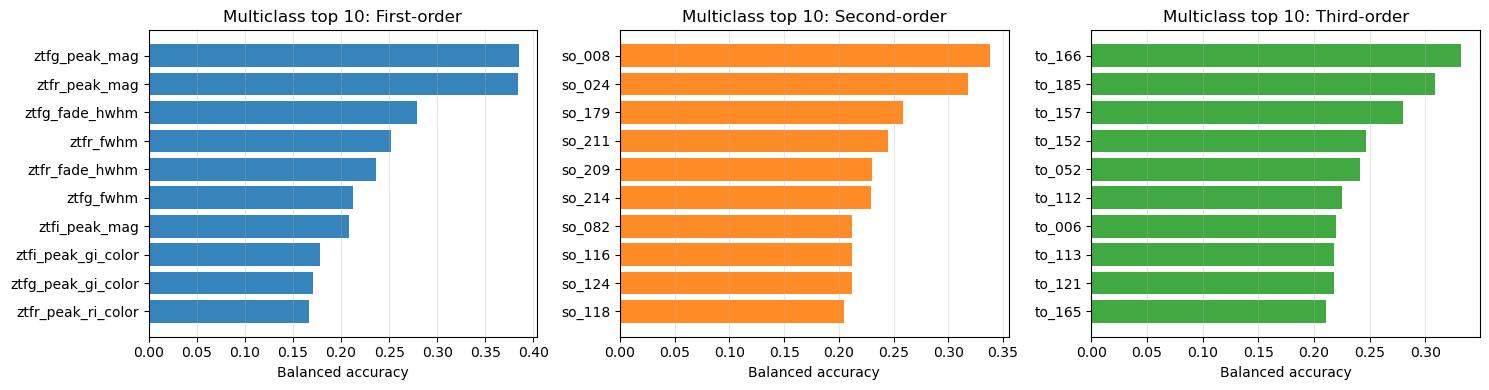

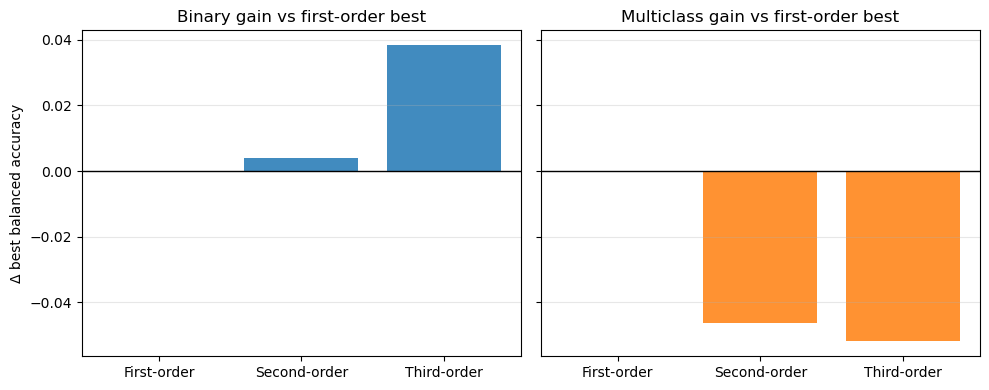

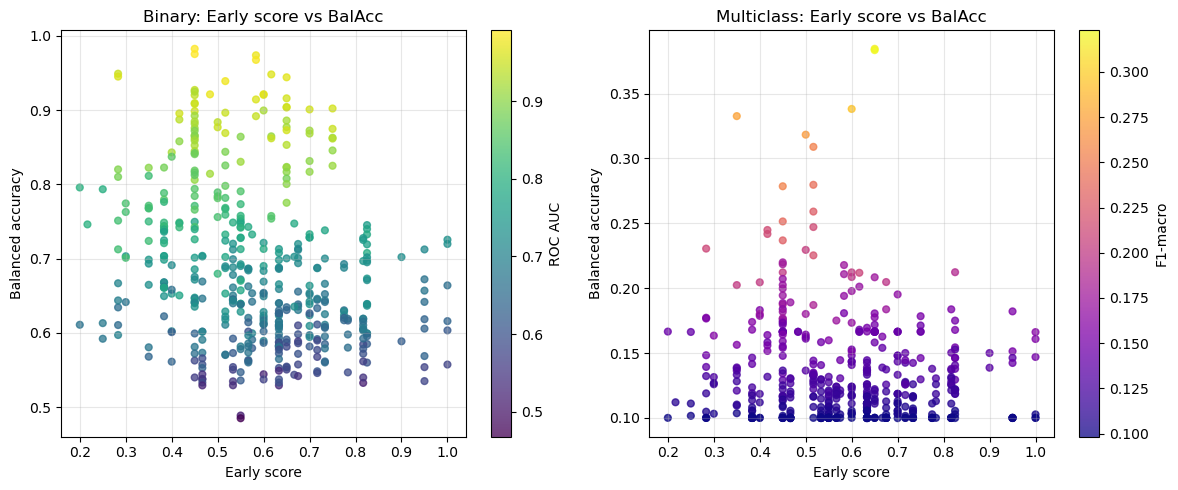

In [23]:
# XGBoost: deep comparison plots for first-, second-, and third-order single-feature metrics

required = ["xgb_binary_results", "xgb_multi_results"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Missing required XGBoost results: {missing}")

def _prep_xgb_family(df, family_name, task_name, aux_col):
    if df is None or len(df) == 0:
        return None
    d = df.copy()

    if "metric" in d.columns and "feature" not in d.columns:
        d = d.rename(columns={"metric": "feature"})
    if "feature" not in d.columns or "balanced_acc_mean" not in d.columns:
        return None

    if aux_col not in d.columns:
        d[aux_col] = np.nan
    if "expr" not in d.columns:
        d["expr"] = d["feature"]

    # Fill early_score for first-order if heuristic exists
    if "early_score" not in d.columns:
        if "metric_early_score" in globals():
            d["early_score"] = d["feature"].map(metric_early_score).astype(float)
        else:
            d["early_score"] = np.nan

    d["family"] = family_name
    d["task"] = task_name
    return d

# Build tidy frames
bin_frames = [
    _prep_xgb_family(globals().get("xgb_binary_results"), "First-order", "Binary", "roc_auc_mean"),
    _prep_xgb_family(globals().get("xgb_second_order_binary"), "Second-order", "Binary", "roc_auc_mean"),
    _prep_xgb_family(globals().get("xgb_third_order_binary"), "Third-order", "Binary", "roc_auc_mean"),
]
mul_frames = [
    _prep_xgb_family(globals().get("xgb_multi_results"), "First-order", "Multiclass", "f1_macro_mean"),
    _prep_xgb_family(globals().get("xgb_second_order_multi"), "Second-order", "Multiclass", "f1_macro_mean"),
    _prep_xgb_family(globals().get("xgb_third_order_multi"), "Third-order", "Multiclass", "f1_macro_mean"),
]

xgb_comp_binary = pd.concat([d for d in bin_frames if d is not None], ignore_index=True)
xgb_comp_multi = pd.concat([d for d in mul_frames if d is not None], ignore_index=True)

if xgb_comp_binary.empty or xgb_comp_multi.empty:
    raise ValueError("Need at least first-order + one higher-order XGB result set for comparison.")

family_order = ["First-order", "Second-order", "Third-order"]
colors = {"First-order": "tab:blue", "Second-order": "tab:orange", "Third-order": "tab:green"}

# ---------- Table: family summaries ----------
def _summary(df, aux_col):
    return (
        df.groupby("family", as_index=False)
        .agg(
            n_features=("feature", "count"),
            bal_mean=("balanced_acc_mean", "mean"),
            bal_median=("balanced_acc_mean", "median"),
            bal_p95=("balanced_acc_mean", lambda x: np.nanpercentile(x, 95)),
            aux_mean=(aux_col, "mean"),
            early_mean=("early_score", "mean"),
            best_bal=("balanced_acc_mean", "max"),
        )
    )

xgb_sum_bin = _summary(xgb_comp_binary, "roc_auc_mean")
xgb_sum_mul = _summary(xgb_comp_multi, "f1_macro_mean")

for s in [xgb_sum_bin, xgb_sum_mul]:
    s["family"] = pd.Categorical(s["family"], categories=family_order, ordered=True)
    s.sort_values("family", inplace=True)

print("=== XGBoost family summary: Binary ===")
display(xgb_sum_bin.reset_index(drop=True))
print("=== XGBoost family summary: Multiclass ===")
display(xgb_sum_mul.reset_index(drop=True))

# ---------- Plot 1: best balanced accuracy by family (binary + multiclass) ----------
best_bin = xgb_comp_binary.groupby("family", as_index=False)["balanced_acc_mean"].max()
best_mul = xgb_comp_multi.groupby("family", as_index=False)["balanced_acc_mean"].max()
best_bin["family"] = pd.Categorical(best_bin["family"], categories=family_order, ordered=True)
best_mul["family"] = pd.Categorical(best_mul["family"], categories=family_order, ordered=True)
best_bin = best_bin.sort_values("family")
best_mul = best_mul.sort_values("family")

x = np.arange(len(best_bin))
w = 0.36
plt.figure(figsize=(8, 4))
plt.bar(x - w/2, best_bin["balanced_acc_mean"], width=w, label="Binary", alpha=0.9)
plt.bar(x + w/2, best_mul["balanced_acc_mean"], width=w, label="Multiclass", alpha=0.9)
plt.xticks(x, best_bin["family"])
plt.ylabel("Best balanced accuracy")
plt.title("XGBoost: Best score by feature family")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Plot 2: boxplots of balanced accuracy ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bin_data = [xgb_comp_binary.loc[xgb_comp_binary["family"] == f, "balanced_acc_mean"].dropna().values for f in family_order if f in xgb_comp_binary["family"].unique()]
bin_labels = [f for f in family_order if f in xgb_comp_binary["family"].unique()]
mul_data = [xgb_comp_multi.loc[xgb_comp_multi["family"] == f, "balanced_acc_mean"].dropna().values for f in family_order if f in xgb_comp_multi["family"].unique()]
mul_labels = [f for f in family_order if f in xgb_comp_multi["family"].unique()]

ax[0].boxplot(bin_data, labels=bin_labels, patch_artist=True)
ax[0].set_title("Binary balanced accuracy distribution")
ax[0].set_ylabel("Balanced accuracy")
ax[0].grid(axis="y", alpha=0.3)

ax[1].boxplot(mul_data, labels=mul_labels, patch_artist=True)
ax[1].set_title("Multiclass balanced accuracy distribution")
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- Plot 3: ECDF curves ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for fam in family_order:
    d = xgb_comp_binary.loc[xgb_comp_binary["family"] == fam, "balanced_acc_mean"].dropna().values
    if len(d):
        xs = np.sort(d)
        ys = np.arange(1, len(xs) + 1) / len(xs)
        ax[0].plot(xs, ys, label=fam, color=colors[fam], lw=2)
ax[0].set_title("Binary ECDF")
ax[0].set_xlabel("Balanced accuracy")
ax[0].set_ylabel("ECDF")
ax[0].grid(alpha=0.3)
ax[0].legend()

for fam in family_order:
    d = xgb_comp_multi.loc[xgb_comp_multi["family"] == fam, "balanced_acc_mean"].dropna().values
    if len(d):
        xs = np.sort(d)
        ys = np.arange(1, len(xs) + 1) / len(xs)
        ax[1].plot(xs, ys, label=fam, color=colors[fam], lw=2)
ax[1].set_title("Multiclass ECDF")
ax[1].set_xlabel("Balanced accuracy")
ax[1].set_ylabel("ECDF")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

# ---------- Plot 4: main metric vs auxiliary metric ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for fam in family_order:
    d = xgb_comp_binary[xgb_comp_binary["family"] == fam]
    if len(d):
        ax[0].scatter(d["balanced_acc_mean"], d["roc_auc_mean"], s=28, alpha=0.65, color=colors[fam], label=fam)
ax[0].set_title("Binary: BalAcc vs ROC AUC")
ax[0].set_xlabel("Balanced accuracy")
ax[0].set_ylabel("ROC AUC")
ax[0].grid(alpha=0.3)
ax[0].legend()

for fam in family_order:
    d = xgb_comp_multi[xgb_comp_multi["family"] == fam]
    if len(d):
        ax[1].scatter(d["balanced_acc_mean"], d["f1_macro_mean"], s=28, alpha=0.65, color=colors[fam], label=fam)
ax[1].set_title("Multiclass: BalAcc vs F1-macro")
ax[1].set_xlabel("Balanced accuracy")
ax[1].set_ylabel("F1-macro")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

# ---------- Plot 5: top-k bar charts by family (binary) ----------
k_show = 10
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, fam in enumerate(family_order):
    d = xgb_comp_binary[xgb_comp_binary["family"] == fam].sort_values("balanced_acc_mean", ascending=False).head(k_show).iloc[::-1]
    if len(d) == 0:
        axes[i].set_visible(False)
        continue
    axes[i].barh(d["feature"], d["balanced_acc_mean"], color=colors[fam], alpha=0.9)
    axes[i].set_title(f"Binary top {k_show}: {fam}")
    axes[i].set_xlabel("Balanced accuracy")
    axes[i].grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- Plot 6: top-k bar charts by family (multiclass) ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, fam in enumerate(family_order):
    d = xgb_comp_multi[xgb_comp_multi["family"] == fam].sort_values("balanced_acc_mean", ascending=False).head(k_show).iloc[::-1]
    if len(d) == 0:
        axes[i].set_visible(False)
        continue
    axes[i].barh(d["feature"], d["balanced_acc_mean"], color=colors[fam], alpha=0.9)
    axes[i].set_title(f"Multiclass top {k_show}: {fam}")
    axes[i].set_xlabel("Balanced accuracy")
    axes[i].grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- Plot 7: complexity gain vs first-order best ----------
base_bin_best = xgb_comp_binary.loc[xgb_comp_binary["family"] == "First-order", "balanced_acc_mean"].max()
base_mul_best = xgb_comp_multi.loc[xgb_comp_multi["family"] == "First-order", "balanced_acc_mean"].max()

gain_bin = xgb_sum_bin.copy()
gain_mul = xgb_sum_mul.copy()
gain_bin["gain_vs_first_best"] = gain_bin["best_bal"] - base_bin_best
gain_mul["gain_vs_first_best"] = gain_mul["best_bal"] - base_mul_best

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax[0].bar(gain_bin["family"].astype(str), gain_bin["gain_vs_first_best"], color="tab:blue", alpha=0.85)
ax[0].axhline(0, color="k", lw=1)
ax[0].set_title("Binary gain vs first-order best")
ax[0].set_ylabel("Δ best balanced accuracy")
ax[0].grid(axis="y", alpha=0.3)

ax[1].bar(gain_mul["family"].astype(str), gain_mul["gain_vs_first_best"], color="tab:orange", alpha=0.85)
ax[1].axhline(0, color="k", lw=1)
ax[1].set_title("Multiclass gain vs first-order best")
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- Plot 8: early-score tradeoff ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sc1 = ax[0].scatter(
    xgb_comp_binary["early_score"], xgb_comp_binary["balanced_acc_mean"],
    c=xgb_comp_binary["roc_auc_mean"], cmap="viridis", alpha=0.75, s=24
)
ax[0].set_title("Binary: Early score vs BalAcc")
ax[0].set_xlabel("Early score")
ax[0].set_ylabel("Balanced accuracy")
ax[0].grid(alpha=0.3)
plt.colorbar(sc1, ax=ax[0], label="ROC AUC")

sc2 = ax[1].scatter(
    xgb_comp_multi["early_score"], xgb_comp_multi["balanced_acc_mean"],
    c=xgb_comp_multi["f1_macro_mean"], cmap="plasma", alpha=0.75, s=24
)
ax[1].set_title("Multiclass: Early score vs BalAcc")
ax[1].set_xlabel("Early score")
ax[1].set_ylabel("Balanced accuracy")
ax[1].grid(alpha=0.3)
plt.colorbar(sc2, ax=ax[1], label="F1-macro")

plt.tight_layout()
plt.show()

# Keep for later cells
xgb_family_summary_binary = xgb_sum_bin.reset_index(drop=True)
xgb_family_summary_multi = xgb_sum_mul.reset_index(drop=True)

<a id="comparison"></a>
# Method Comparison and Feature Importance Analysis

=== Method comparison (original single-feature metrics) ===


,model,task,best_bal_acc,top5_mean_bal_acc,best_aux
0,XGBoost,Binary,0.944250,0.914890,0.968370
1,RandomForest,Binary,0.941819,0.918479,0.942196
2,KNN,Binary,0.784277,0.770207,0.952442
3,RandomForest,Multiclass,0.545729,0.375819,0.530954
4,KNN,Multiclass,0.543027,0.380095,0.522845
5,XGBoost,Multiclass,0.384565,0.306998,0.322971


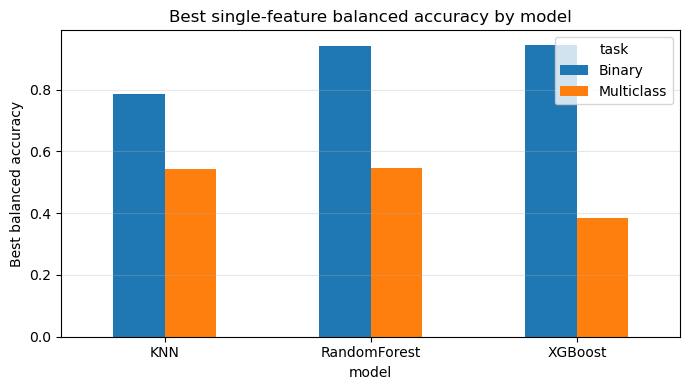

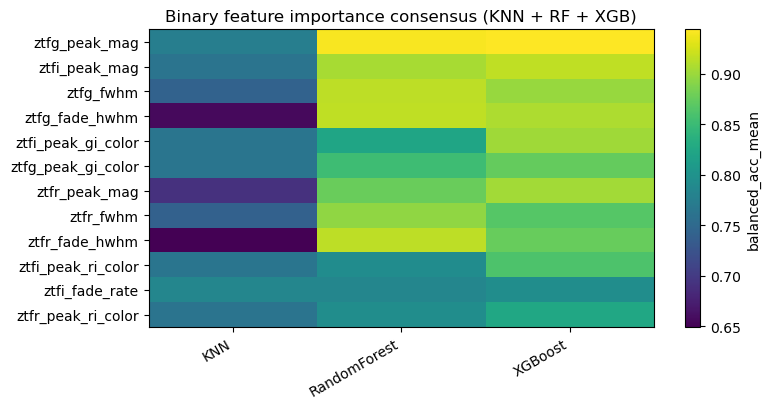

=== Top consensus features (binary) ===


,feature,mean_rank,score_mean,KNN_score,RandomForest_score,XGBoost_score
0,ztfg_peak_mag,1.333333,0.887261,0.775714,0.941819,0.944250
1,ztfi_peak_mag,4.666667,0.861289,0.762620,0.905301,0.915946
2,ztfg_fwhm,5.666667,0.851912,0.741905,0.915087,0.898745
3,ztfg_fade_hwhm,6.000000,0.826708,0.656190,0.915563,0.908370
4,ztfi_peak_gi_color,6.166667,0.829463,0.763529,0.822597,0.902263
5,ztfg_peak_gi_color,6.833333,0.830248,0.763529,0.852359,0.874857
6,ztfr_peak_mag,7.333333,0.823840,0.691429,0.876470,0.903621
7,ztfr_fwhm,8.000000,0.833917,0.740952,0.894852,0.865945
8,ztfr_fade_hwhm,8.333333,0.813167,0.649048,0.914625,0.875829
9,ztfi_peak_ri_color,8.333333,0.806061,0.763984,0.792445,0.861753


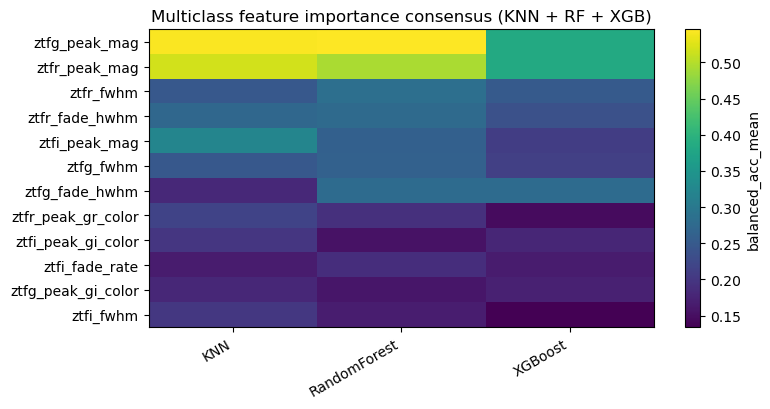

=== Top consensus features (multiclass) ===


,feature,mean_rank,score_mean,KNN_score,RandomForest_score,XGBoost_score
0,ztfg_peak_mag,1.000000,0.491107,0.543027,0.545729,0.384565
1,ztfr_peak_mag,2.000000,0.464959,0.517742,0.493597,0.383537
2,ztfr_fwhm,4.333333,0.260979,0.246825,0.284656,0.251455
3,ztfr_fade_hwhm,4.666667,0.261519,0.271024,0.276674,0.236859
4,ztfi_peak_mag,5.666667,0.263096,0.320871,0.260021,0.208397
5,ztfg_fwhm,5.666667,0.240628,0.247811,0.261905,0.212169
6,ztfg_fade_hwhm,6.000000,0.246051,0.181141,0.278439,0.278571
7,ztfr_peak_gr_color,10.333333,0.184774,0.216994,0.191229,0.146099
8,ztfi_peak_gi_color,11.000000,0.177248,0.198864,0.154495,0.178386
9,ztfi_fade_rate,12.000000,0.173463,0.165939,0.188222,0.166227


=== Binary score correlation across models ===


,KNN_score,RandomForest_score,XGBoost_score
KNN_score,1.000000,0.721183,0.725968
RandomForest_score,0.721183,1.000000,0.944348
XGBoost_score,0.725968,0.944348,1.000000


=== Multiclass score correlation across models ===


,KNN_score,RandomForest_score,XGBoost_score
KNN_score,1.000000,0.843478,0.713043
RandomForest_score,0.843478,1.000000,0.783478
XGBoost_score,0.713043,0.783478,1.000000


=== Best balanced accuracy by model/task/feature family ===


,model,task,feature_family,best_balanced_acc
2,KNN,Binary,Third-order,0.934376
1,KNN,Binary,Second-order,0.838254
0,KNN,Binary,Original,0.784277
8,RandomForest,Binary,Third-order,0.980505
6,RandomForest,Binary,Original,0.941819
7,RandomForest,Binary,Second-order,0.923936
14,XGBoost,Binary,Third-order,0.982617
13,XGBoost,Binary,Second-order,0.948156
12,XGBoost,Binary,Original,0.944250
3,KNN,Multiclass,Original,0.543027


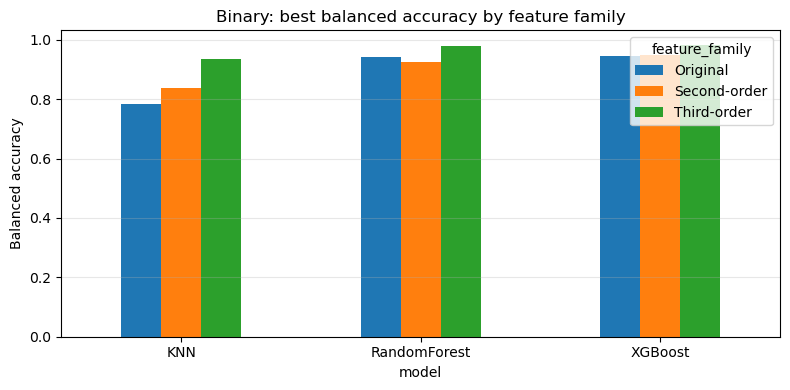

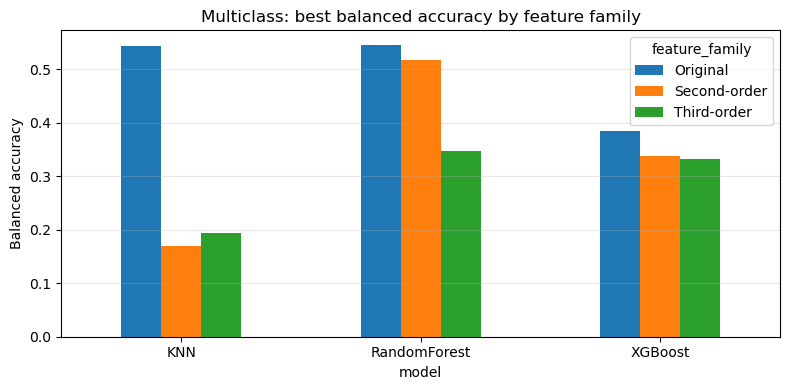

=== OVR-based feature importance (how often a feature is top-per-type) ===


,metric,n_types_selected,mean_bal_acc,mean_roc_auc
0,ztfg_fade_hwhm,8,0.500000,0.749767
1,ztfg_fade_rate,8,0.500000,0.619000
2,ztfg_fwhm,8,0.500000,0.834655
3,ztfg_peak_gi_color,8,0.500000,0.839015
4,ztfg_peak_gr_color,8,0.500000,0.730350
5,ztfg_peak_mag,1,0.783810,0.951884
6,ztfi_fade_rate,1,0.779264,0.788106
7,ztfr_peak_ri_color,1,0.758994,0.864534
8,ztfi_peak_gi_color,1,0.758312,0.935964
9,ztfi_peak_mag,1,0.758084,0.922614


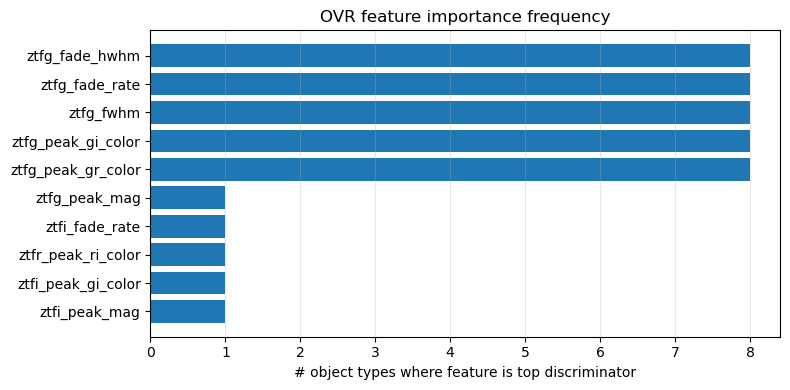

In [21]:
# -----------------------------
# Method comparison + feature importance analysis
# -----------------------------

# ---------- Helpers ----------
def _std_feature_col(df):
    if df is None or len(df) == 0:
        return None
    d = df.copy()
    if "metric" in d.columns and "feature" not in d.columns:
        d = d.rename(columns={"metric": "feature"})
    return d

def _best_score(df, col="balanced_acc_mean"):
    if df is None or len(df) == 0 or col not in df.columns:
        return np.nan
    return float(df[col].max())

def _topk_mean(df, col="balanced_acc_mean", k=5):
    if df is None or len(df) == 0 or col not in df.columns:
        return np.nan
    return float(df[col].nlargest(min(k, len(df))).mean())

def _build_consensus(dfs_by_model, score_col="balanced_acc_mean", top_n=12, title="Consensus"):
    valid = {}
    for model, df in dfs_by_model.items():
        d = _std_feature_col(df)
        if d is not None and "feature" in d.columns and score_col in d.columns:
            valid[model] = d[["feature", score_col]].copy()

    if len(valid) < 2:
        print(f"{title}: not enough model outputs for consensus.")
        return None, None

    merged = None
    for model, d in valid.items():
        d = d.rename(columns={score_col: f"{model}_score"})
        merged = d if merged is None else merged.merge(d, on="feature", how="inner")

    score_cols = [c for c in merged.columns if c.endswith("_score")]
    for c in score_cols:
        merged[c.replace("_score", "_rank")] = merged[c].rank(ascending=False, method="average")

    rank_cols = [c for c in merged.columns if c.endswith("_rank")]
    merged["mean_rank"] = merged[rank_cols].mean(axis=1)
    merged["score_mean"] = merged[score_cols].mean(axis=1)
    merged = merged.sort_values(["mean_rank", "score_mean"], ascending=[True, False]).reset_index(drop=True)

    top = merged.head(top_n).copy()

    # Heatmap
    heat = top.set_index("feature")[score_cols]
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(heat))))
    im = ax.imshow(heat.values, aspect="auto", cmap="viridis")
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels([c.replace("_score", "") for c in heat.columns], rotation=30, ha="right")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label=score_col)
    plt.tight_layout()
    plt.show()

    return merged, top


# ---------- 1) Compare models on original single-feature sets ----------
knn_bin = _std_feature_col(binary_results) if "binary_results" in globals() else None
rf_bin = _std_feature_col(rf_binary_results) if "rf_binary_results" in globals() else None
xgb_bin = _std_feature_col(xgb_binary_results) if "xgb_binary_results" in globals() else None

knn_mul = _std_feature_col(multi_results) if "multi_results" in globals() else None
rf_mul = _std_feature_col(rf_multi_results) if "rf_multi_results" in globals() else None
xgb_mul = _std_feature_col(xgb_multi_results) if "xgb_multi_results" in globals() else None

method_rows = []
for model, bdf, mdf in [
    ("KNN", knn_bin, knn_mul),
    ("RandomForest", rf_bin, rf_mul),
    ("XGBoost", xgb_bin, xgb_mul),
]:
    method_rows.append({
        "model": model,
        "task": "Binary",
        "best_bal_acc": _best_score(bdf, "balanced_acc_mean"),
        "top5_mean_bal_acc": _topk_mean(bdf, "balanced_acc_mean", k=5),
        "best_aux": _best_score(bdf, "roc_auc_mean"),
    })
    method_rows.append({
        "model": model,
        "task": "Multiclass",
        "best_bal_acc": _best_score(mdf, "balanced_acc_mean"),
        "top5_mean_bal_acc": _topk_mean(mdf, "balanced_acc_mean", k=5),
        "best_aux": _best_score(mdf, "f1_macro_mean"),
    })

method_comparison_full = pd.DataFrame(method_rows)
print("=== Method comparison (original single-feature metrics) ===")
display(method_comparison_full.sort_values(["task", "best_bal_acc"], ascending=[True, False]).reset_index(drop=True))

# Plot: best balanced accuracy by model/task
plot_df = method_comparison_full.pivot(index="model", columns="task", values="best_bal_acc")
plot_df = plot_df.reindex(["KNN", "RandomForest", "XGBoost"])
ax = plot_df.plot(kind="bar", figsize=(7, 4))
ax.set_ylabel("Best balanced accuracy")
ax.set_title("Best single-feature balanced accuracy by model")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ---------- 2) Consensus feature importance (across models) ----------
bin_consensus_all, bin_top = _build_consensus(
    {"KNN": knn_bin, "RandomForest": rf_bin, "XGBoost": xgb_bin},
    score_col="balanced_acc_mean",
    top_n=12,
    title="Binary feature importance consensus (KNN + RF + XGB)"
)
if bin_top is not None:
    print("=== Top consensus features (binary) ===")
    display(bin_top[["feature", "mean_rank", "score_mean"] + [c for c in bin_top.columns if c.endswith("_score")]])

mul_consensus_all, mul_top = _build_consensus(
    {"KNN": knn_mul, "RandomForest": rf_mul, "XGBoost": xgb_mul},
    score_col="balanced_acc_mean",
    top_n=12,
    title="Multiclass feature importance consensus (KNN + RF + XGB)"
)
if mul_top is not None:
    print("=== Top consensus features (multiclass) ===")
    display(mul_top[["feature", "mean_rank", "score_mean"] + [c for c in mul_top.columns if c.endswith("_score")]])

# Agreement diagnostics
if bin_consensus_all is not None:
    bin_score_cols = [c for c in bin_consensus_all.columns if c.endswith("_score")]
    print("=== Binary score correlation across models ===")
    display(bin_consensus_all[bin_score_cols].corr(method="spearman"))

if mul_consensus_all is not None:
    mul_score_cols = [c for c in mul_consensus_all.columns if c.endswith("_score")]
    print("=== Multiclass score correlation across models ===")
    display(mul_consensus_all[mul_score_cols].corr(method="spearman"))


# ---------- 3) Original vs 2nd-order vs 3rd-order (best balanced accuracy) ----------
complexity_rows = []

# KNN
if "binary_results" in globals():
    complexity_rows.append(("KNN", "Binary", "Original", _best_score(_std_feature_col(binary_results))))
if "second_order_results_binary" in globals():
    complexity_rows.append(("KNN", "Binary", "Second-order", _best_score(_std_feature_col(second_order_results_binary))))
if "third_order_results_binary" in globals():
    complexity_rows.append(("KNN", "Binary", "Third-order", _best_score(_std_feature_col(third_order_results_binary))))

if "multi_results" in globals():
    complexity_rows.append(("KNN", "Multiclass", "Original", _best_score(_std_feature_col(multi_results))))
if "second_order_results_multi" in globals():
    complexity_rows.append(("KNN", "Multiclass", "Second-order", _best_score(_std_feature_col(second_order_results_multi))))
if "third_order_results_multi" in globals():
    complexity_rows.append(("KNN", "Multiclass", "Third-order", _best_score(_std_feature_col(third_order_results_multi))))

# RF
if "rf_binary_results" in globals():
    complexity_rows.append(("RandomForest", "Binary", "Original", _best_score(_std_feature_col(rf_binary_results))))
if "rf_second_order_binary" in globals():
    complexity_rows.append(("RandomForest", "Binary", "Second-order", _best_score(_std_feature_col(rf_second_order_binary))))
if "rf_third_order_binary" in globals():
    complexity_rows.append(("RandomForest", "Binary", "Third-order", _best_score(_std_feature_col(rf_third_order_binary))))

if "rf_multi_results" in globals():
    complexity_rows.append(("RandomForest", "Multiclass", "Original", _best_score(_std_feature_col(rf_multi_results))))
if "rf_second_order_multi" in globals():
    complexity_rows.append(("RandomForest", "Multiclass", "Second-order", _best_score(_std_feature_col(rf_second_order_multi))))
if "rf_third_order_multi" in globals():
    complexity_rows.append(("RandomForest", "Multiclass", "Third-order", _best_score(_std_feature_col(rf_third_order_multi))))

# XGB
if "xgb_binary_results" in globals():
    complexity_rows.append(("XGBoost", "Binary", "Original", _best_score(_std_feature_col(xgb_binary_results))))
if "xgb_second_order_binary" in globals():
    complexity_rows.append(("XGBoost", "Binary", "Second-order", _best_score(_std_feature_col(xgb_second_order_binary))))
if "xgb_third_order_binary" in globals():
    complexity_rows.append(("XGBoost", "Binary", "Third-order", _best_score(_std_feature_col(xgb_third_order_binary))))

if "xgb_multi_results" in globals():
    complexity_rows.append(("XGBoost", "Multiclass", "Original", _best_score(_std_feature_col(xgb_multi_results))))
if "xgb_second_order_multi" in globals():
    complexity_rows.append(("XGBoost", "Multiclass", "Second-order", _best_score(_std_feature_col(xgb_second_order_multi))))
if "xgb_third_order_multi" in globals():
    complexity_rows.append(("XGBoost", "Multiclass", "Third-order", _best_score(_std_feature_col(xgb_third_order_multi))))

complexity_comparison = pd.DataFrame(
    complexity_rows, columns=["model", "task", "feature_family", "best_balanced_acc"]
)
print("=== Best balanced accuracy by model/task/feature family ===")
display(complexity_comparison.sort_values(["task", "model", "best_balanced_acc"], ascending=[True, True, False]))

for task_name in ["Binary", "Multiclass"]:
    sub = complexity_comparison[complexity_comparison["task"] == task_name]
    if len(sub) == 0:
        continue
    pvt = sub.pivot(index="model", columns="feature_family", values="best_balanced_acc")
    pvt = pvt.reindex(["KNN", "RandomForest", "XGBoost"])
    ax = pvt.plot(kind="bar", figsize=(8, 4))
    ax.set_title(f"{task_name}: best balanced accuracy by feature family")
    ax.set_ylabel("Balanced accuracy")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ---------- 4) One-vs-rest feature importance summary (if available) ----------
if "top_discriminators_by_type" in globals():
    ovr = top_discriminators_by_type.copy()
    if "metric" in ovr.columns:
        ovr_importance = (
            ovr.groupby("metric", as_index=False)
            .agg(
                n_types_selected=("object_type", "nunique"),
                mean_bal_acc=("balanced_acc_mean", "mean"),
                mean_roc_auc=("roc_auc_mean", "mean")
            )
            .sort_values(["n_types_selected", "mean_bal_acc"], ascending=[False, False])
            .reset_index(drop=True)
        )
        print("=== OVR-based feature importance (how often a feature is top-per-type) ===")
        display(ovr_importance.head(15))

        plt.figure(figsize=(8, 4))
        t = ovr_importance.head(12).iloc[::-1]
        plt.barh(t["metric"], t["n_types_selected"])
        plt.xlabel("# object types where feature is top discriminator")
        plt.title("OVR feature importance frequency")
        plt.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()

=== TABLE A: Family-level summary (First vs Second vs Third order) ===


,task,model,family,n_features,bal_mean,bal_median,bal_p90,bal_best,aux_mean,aux_best
0,Binary,KNN,Third-order,220,0.568536,0.547707,0.711556,0.934376,0.616260,0.986898
1,Binary,RandomForest,First-order,464,0.665353,0.640701,0.813401,0.980505,0.698558,0.980705
2,Binary,RandomForest,Second-order,220,0.663513,0.640763,0.810789,0.923936,0.697775,0.928729
3,Binary,RandomForest,Third-order,220,0.656615,0.636433,0.792679,0.980505,0.690293,0.980705
4,Binary,XGBoost,First-order,24,0.779998,0.835465,0.906945,0.944250,0.825086,0.968370
5,Binary,XGBoost,Second-order,220,0.693353,0.672788,0.862336,0.948156,0.743218,0.969453
6,Binary,XGBoost,Third-order,220,0.671344,0.645121,0.827076,0.982617,0.719535,0.991022
7,Multiclass,KNN,Third-order,220,0.123689,0.121705,0.147088,0.194048,0.071229,0.161469
8,Multiclass,RandomForest,First-order,464,0.162977,0.153265,0.214273,0.545729,0.106999,0.530954
9,Multiclass,RandomForest,Second-order,220,0.159576,0.152171,0.207163,0.516767,0.104061,0.497861


=== TABLE B: Top 10 features per model/task/family ===


,task,model,family,feature,balanced_acc_mean,aux_mean,expr
0,Binary,KNN,Third-order,to_179,0.934376,0.953899,sign(ztfg_fwhm*ztfg_fade_rate*ztfr_fwhm)*cuberoot(|...|)
1,Binary,KNN,Third-order,to_003,0.903968,0.938897,ztfg_fade_hwhm*ztfg_fade_rate*ztfr_fade_hwhm
2,Binary,KNN,Third-order,to_154,0.820052,0.934357,(ztfr_peak_gr_color*ztfg_fade_rate+ztfg_fade_rate*ztfi_peak_mag+ztfi_peak_mag*ztfr_peak_gr_color)/(|a|+|b|+|c|)
3,Binary,KNN,Third-order,to_138,0.803317,0.944410,(ztfr_peak_gr_color*ztfi_peak_mag)/|ztfr_fade_rate|
4,Binary,KNN,Third-order,to_004,0.802958,0.860337,(ztfr_peak_gr_color*ztfr_fade_hwhm)/|ztfg_fade_hwhm|
...,...,...,...,...,...,...,...
135,Multiclass,XGBoost,Third-order,to_112,0.225306,0.219749,ztfr_peak_gr_color*ztfr_peak_mag*ztfr_fwhm
136,Multiclass,XGBoost,Third-order,to_006,0.219916,0.175511,(ztfi_peak_mag+ztfr_peak_gr_color+ztfr_fade_rate)/3
137,Multiclass,XGBoost,Third-order,to_113,0.218480,0.177587,(ztfi_fade_rate+ztfi_peak_ri_color+ztfg_peak_mag)/3
138,Multiclass,XGBoost,Third-order,to_121,0.217815,0.173992,(ztfg_peak_mag*ztfr_peak_mag+ztfr_peak_mag*ztfg_peak_gi_color+ztfg_peak_gi_color*ztfg_peak_mag)/(|a|+|b|+|c|)


=== TABLE C: Best balanced accuracy, with family deltas ===


...

,feature,RandomForest_rank,XGBoost_rank,mean_rank,models_present,mean_bal_acc
0,ztfg_peak_mag,1.0,1.0,1.0,2,0.465147
1,ztfr_peak_mag,3.0,2.0,2.5,2,0.438567
2,so_008,2.0,3.0,2.5,2,0.427480
3,to_166,6.0,4.0,5.0,2,0.336996
4,to_185,5.0,6.0,5.5,2,0.327686
5,so_024,9.0,5.0,7.0,2,0.306548
6,so_211,4.0,12.0,8.0,2,0.307416
7,ztfg_fade_hwhm,13.0,8.0,10.5,2,0.278505
8,so_179,12.0,9.0,10.5,2,0.268945
9,ztfr_fwhm,11.0,10.0,10.5,2,0.268056



--- Multiclass | Second-order ---


,feature,RandomForest_rank,XGBoost_rank,mean_rank,models_present,mean_bal_acc
0,so_008,1.0,1.0,1.0,2,0.427480
1,so_211,2.0,4.0,3.0,2,0.307416
2,so_024,4.0,2.0,3.0,2,0.306548
3,so_179,5.0,3.0,4.0,2,0.268945
4,so_214,3.0,6.0,4.5,2,0.265415
5,so_116,8.0,8.0,8.0,2,0.226435
6,so_056,6.0,14.0,10.0,2,0.225358
7,so_219,9.0,12.0,10.5,2,0.217867
8,so_124,13.0,9.0,11.0,2,0.216418
9,so_112,7.0,20.0,13.5,2,0.214201



--- Multiclass | Third-order ---


,feature,KNN_rank,RandomForest_rank,XGBoost_rank,mean_rank,models_present,mean_bal_acc
0,to_165,8.0,3.0,10.0,7.000000,3,0.235493
1,to_052,6.0,11.0,5.0,7.333333,3,0.221582
2,to_154,3.0,10.0,12.0,8.333333,3,0.211794
3,to_006,7.0,12.0,7.0,8.666667,3,0.209942
4,to_121,11.0,7.0,9.0,9.000000,3,0.216444
5,to_113,16.0,4.0,8.0,9.333333,3,0.224635
6,to_152,19.0,5.0,4.0,9.333333,3,0.224444
7,to_157,18.0,13.0,3.0,11.333333,3,0.223871
8,to_166,37.0,2.0,1.0,13.333333,3,0.272812
9,to_138,13.5,9.0,24.0,15.500000,3,0.201196


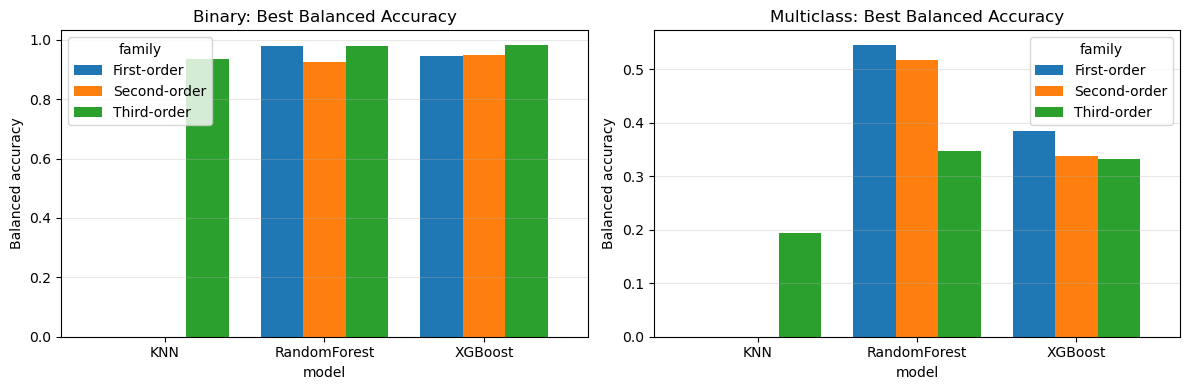

/var/folders/8_/ky643qs168ngjmhrpwcq1fdm0000gn/T/ipykernel_58070/3090826131.py:233: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[ax_i].boxplot(vals, labels=labels, patch_artist=True)
/var/folders/8_/ky643qs168ngjmhrpwcq1fdm0000gn/T/ipykernel_58070/3090826131.py:233: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[ax_i].boxplot(vals, labels=labels, patch_artist=True)


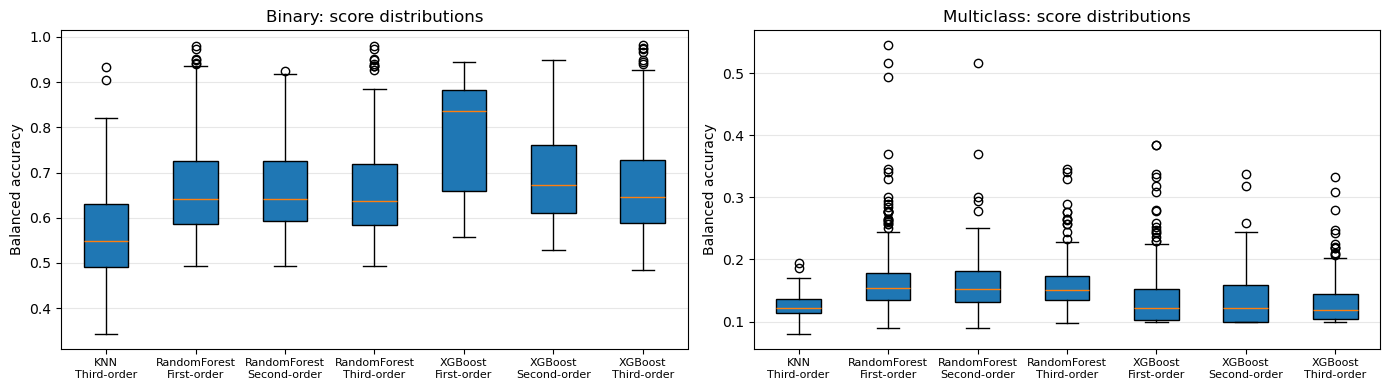

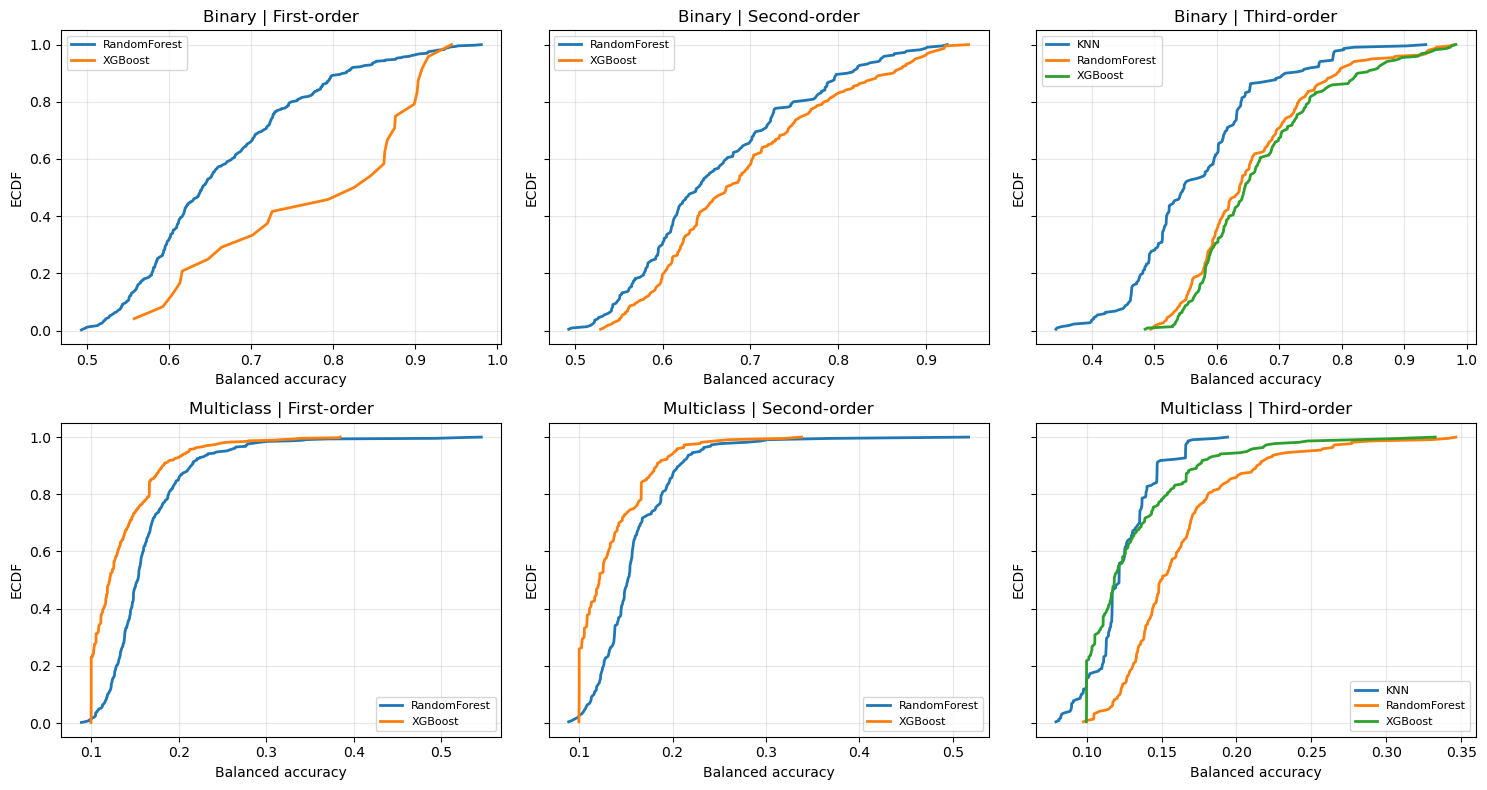

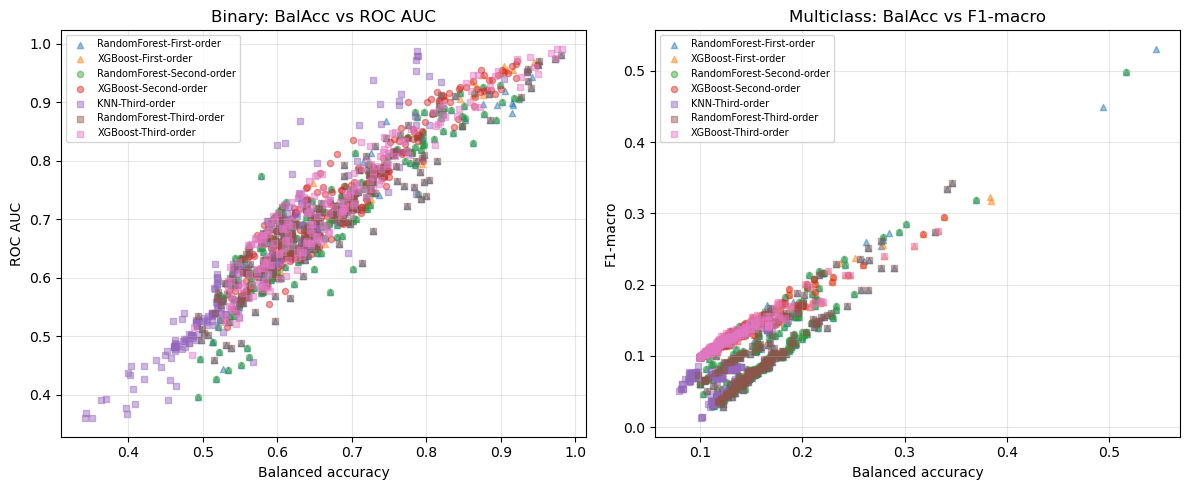

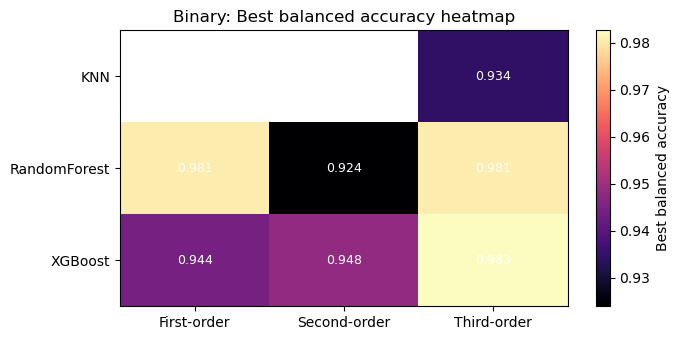

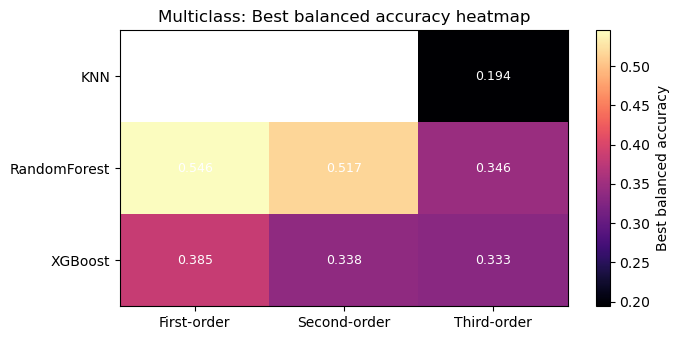

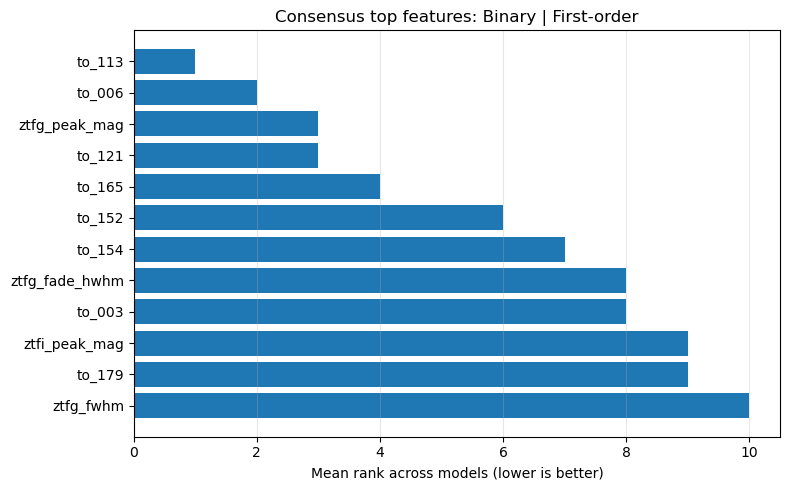

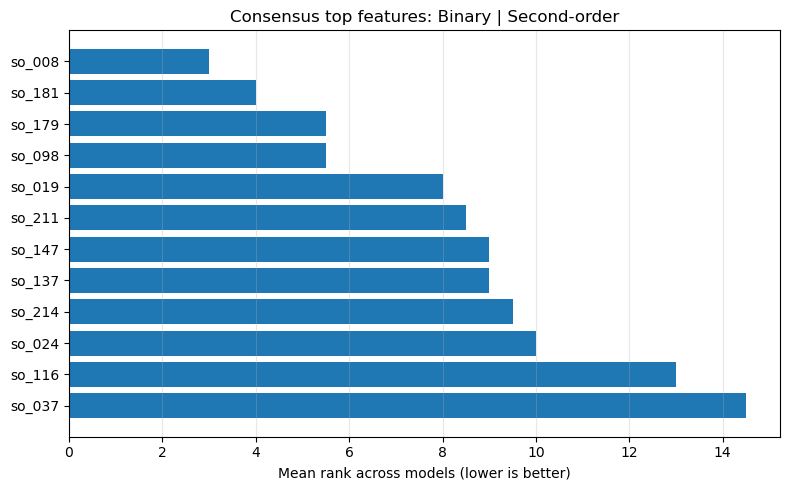

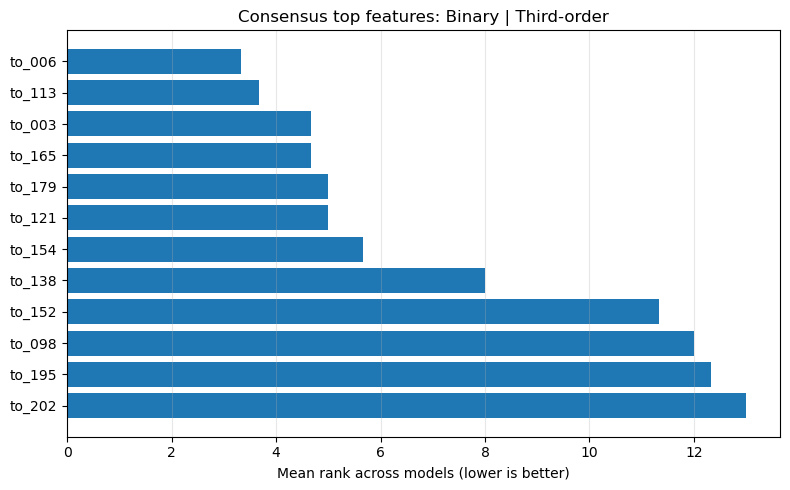

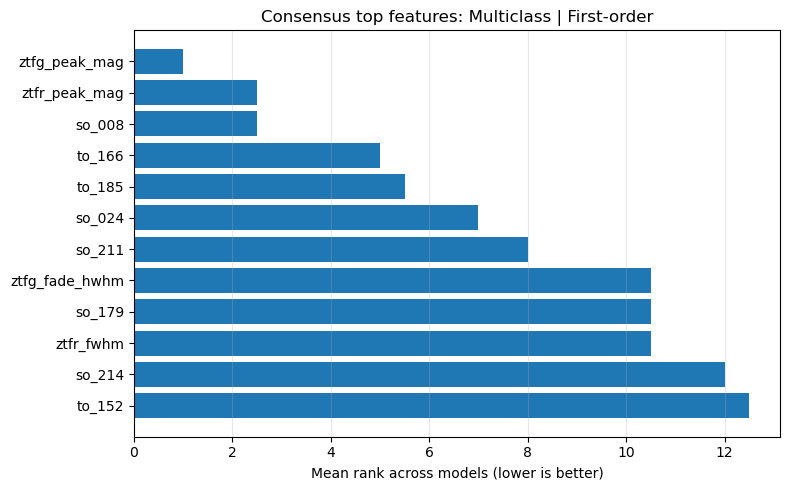

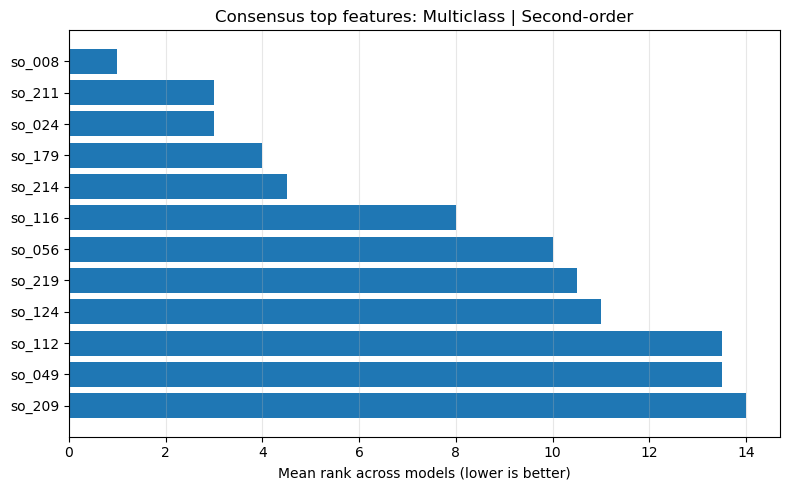

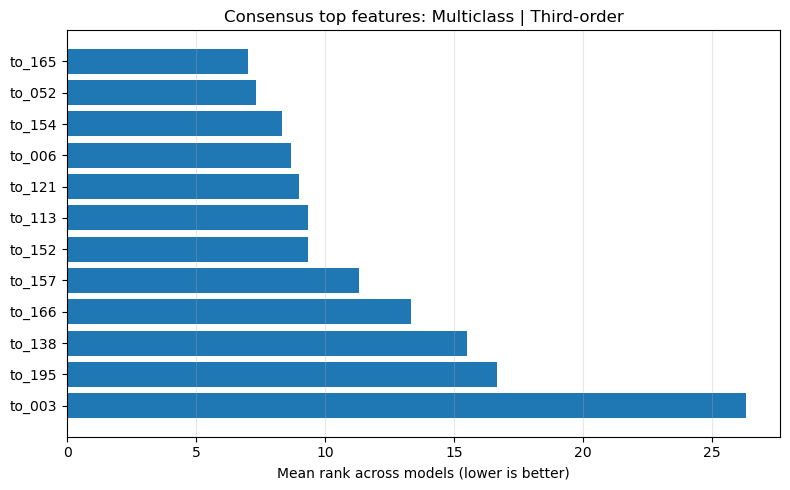

In [25]:
# Comprehensive comparison of FIRST-, SECOND-, and THIRD-order metrics across KNN, RF, and XGBoost
# Focus: descriptive tables + readable plots for Binary and Multiclass tasks

# -----------------------------
# 0) Collect and standardize inputs
# -----------------------------
def _std_df(df, model, family, task):
    if df is None or len(df) == 0:
        return None
    d = df.copy()

    if "metric" in d.columns and "feature" not in d.columns:
        d = d.rename(columns={"metric": "feature"})
    if "feature" not in d.columns or "balanced_acc_mean" not in d.columns:
        return None

    aux_col = "roc_auc_mean" if task == "Binary" else "f1_macro_mean"
    if aux_col not in d.columns:
        d[aux_col] = np.nan
    if "expr" not in d.columns:
        d["expr"] = d["feature"]

    keep = ["feature", "expr", "balanced_acc_mean", aux_col]
    for c in keep:
        if c not in d.columns:
            d[c] = np.nan

    d = d[keep].copy()
    d["model"] = model
    d["family"] = family
    d["task"] = task
    d = d.rename(columns={aux_col: "aux_mean"})
    return d


def _pick_df(*names, family=None, task=None):
    for name in names:
        df = globals().get(name)
        if df is None or len(df) == 0:
            continue
        d = df.copy()
        if family is not None and "family" in d.columns:
            d = d[d["family"] == family]
        if task is not None and "task" in d.columns:
            d = d[d["task"] == task]
        if len(d):
            return d
    return None


frames = [
    # KNN
    _std_df(_pick_df("knn_first_order_binary", "first_order_results_binary", "knn_comp_binary"), "KNN", "First-order", "Binary"),
    _std_df(_pick_df("knn_third_order_binary", "third_order_results_binary", "knn_comp_binary"), "KNN", "Third-order", "Binary"),
    _std_df(_pick_df("knn_first_order_multi", "first_order_results_multi", "knn_comp_multi"), "KNN", "First-order", "Multiclass"),
    _std_df(_pick_df("knn_third_order_multi", "third_order_results_multi", "knn_comp_multi"), "KNN", "Third-order", "Multiclass"),

    # RandomForest
    _std_df(_pick_df("rf_first_order_binary", "rf_comp_binary"), "RandomForest", "First-order", "Binary"),
    _std_df(_pick_df("rf_second_order_binary", "rf_second_order_binary", "rf_comp_binary"), "RandomForest", "Second-order", "Binary"),
    _std_df(_pick_df("rf_third_order_binary", "rf_third_order_binary", "rf_comp_binary"), "RandomForest", "Third-order", "Binary"),
    _std_df(_pick_df("rf_first_order_multi", "rf_comp_multi"), "RandomForest", "First-order", "Multiclass"),
    _std_df(_pick_df("rf_second_order_multi", "rf_second_order_multi", "rf_comp_multi"), "RandomForest", "Second-order", "Multiclass"),
    _std_df(_pick_df("rf_third_order_multi", "rf_third_order_multi", "rf_comp_multi"), "RandomForest", "Third-order", "Multiclass"),

    # XGBoost
    _std_df(_pick_df("xgb_bin", "xgb_first_order_binary", "xgb_comp_binary"), "XGBoost", "First-order", "Binary"),
    _std_df(_pick_df("xgb_second_order_binary", "xgb_comp_binary"), "XGBoost", "Second-order", "Binary"),
    _std_df(_pick_df("xgb_third_order_binary", "xgb_comp_binary"), "XGBoost", "Third-order", "Binary"),
    _std_df(_pick_df("xgb_multi", "xgb_first_order_multi", "xgb_comp_multi"), "XGBoost", "First-order", "Multiclass"),
    _std_df(_pick_df("xgb_second_order_multi", "xgb_comp_multi"), "XGBoost", "Second-order", "Multiclass"),
    _std_df(_pick_df("xgb_third_order_multi", "xgb_comp_multi"), "XGBoost", "Third-order", "Multiclass"),
]

comp = pd.concat([f for f in frames if f is not None], ignore_index=True)
if comp.empty:
    raise ValueError("No first/second/third-order result tables found.")

model_order = ["KNN", "RandomForest", "XGBoost"]
family_order = ["First-order", "Second-order", "Third-order"]
task_order = ["Binary", "Multiclass"]

comp["model"] = pd.Categorical(comp["model"], categories=model_order, ordered=True)
comp["family"] = pd.Categorical(comp["family"], categories=family_order, ordered=True)
comp["task"] = pd.Categorical(comp["task"], categories=task_order, ordered=True)

# -----------------------------
# 1) Tables
# -----------------------------
family_summary = (
    comp.groupby(["task", "model", "family"], as_index=False)
    .agg(
        n_features=("feature", "count"),
        bal_mean=("balanced_acc_mean", "mean"),
        bal_median=("balanced_acc_mean", "median"),
        bal_p90=("balanced_acc_mean", lambda x: np.nanpercentile(x, 90)),
        bal_best=("balanced_acc_mean", "max"),
        aux_mean=("aux_mean", "mean"),
        aux_best=("aux_mean", "max"),
    )
    .sort_values(["task", "model", "family"])
    .reset_index(drop=True)
)

print("=== TABLE A: Family-level summary (First vs Second vs Third order) ===")
display(family_summary)

top_k = 10
top_features = (
    comp.sort_values(["task", "model", "family", "balanced_acc_mean"], ascending=[True, True, True, False])
    .groupby(["task", "model", "family"], as_index=False, group_keys=False)
    .head(top_k)
    .reset_index(drop=True)
)

print(f"=== TABLE B: Top {top_k} features per model/task/family ===")
display(top_features[["task", "model", "family", "feature", "balanced_acc_mean", "aux_mean", "expr"]])

best_by_family = (
    comp.groupby(["task", "model", "family"], as_index=False)["balanced_acc_mean"]
    .max()
    .pivot_table(index=["task", "model"], columns="family", values="balanced_acc_mean", aggfunc="max")
    .reset_index()
)

for a, b, name in [
    ("Second-order", "First-order", "delta_second_minus_first"),
    ("Third-order", "Second-order", "delta_third_minus_second"),
    ("Third-order", "First-order", "delta_third_minus_first"),
]:
    if a in best_by_family.columns and b in best_by_family.columns:
        best_by_family[name] = best_by_family[a] - best_by_family[b]

print("=== TABLE C: Best balanced accuracy, with family deltas ===")
display(best_by_family)

def _top_set(df, k=20):
    return set(df.sort_values("balanced_acc_mean", ascending=False).head(k)["feature"].astype(str).tolist())

rows = []
k_overlap = 20
for task in task_order:
    for family in family_order:
        d = comp[(comp["task"] == task) & (comp["family"] == family)]
        if d.empty:
            continue
        sets = {m: _top_set(d[d["model"] == m], k=k_overlap) for m in model_order if len(d[d["model"] == m]) > 0}
        keys = list(sets.keys())
        for i in range(len(keys)):
            for j in range(i + 1, len(keys)):
                a, b = keys[i], keys[j]
                inter = len(sets[a] & sets[b])
                union = len(sets[a] | sets[b])
                rows.append({
                    "task": task,
                    "family": family,
                    "model_a": a,
                    "model_b": b,
                    "top_k": k_overlap,
                    "intersection": inter,
                    "union": union,
                    "jaccard": inter / union if union else np.nan
                })

overlap_df = pd.DataFrame(rows).sort_values(["task", "family", "jaccard"], ascending=[True, True, False])

print(f"=== TABLE D: Top-{k_overlap} feature overlap across models (Jaccard) ===")
display(overlap_df)

consensus_tables = {}
for task in task_order:
    for family in family_order:
        d = comp[(comp["task"] == task) & (comp["family"] == family)].copy()
        if d.empty:
            continue

        rank_parts = []
        for m in model_order:
            dm = d[d["model"] == m][["feature", "balanced_acc_mean"]].copy()
            if dm.empty:
                continue
            dm[f"{m}_rank"] = dm["balanced_acc_mean"].rank(ascending=False, method="average")
            dm = dm[["feature", f"{m}_rank"]]
            rank_parts.append(dm)

        if len(rank_parts) < 2:
            continue

        merged = rank_parts[0]
        for rp in rank_parts[1:]:
            merged = merged.merge(rp, on="feature", how="outer")

        rank_cols = [c for c in merged.columns if c.endswith("_rank")]
        merged["mean_rank"] = merged[rank_cols].mean(axis=1, skipna=True)
        merged["models_present"] = merged[rank_cols].notna().sum(axis=1)

        score_ref = d.groupby("feature", as_index=False)["balanced_acc_mean"].mean().rename(columns={"balanced_acc_mean": "mean_bal_acc"})
        merged = merged.merge(score_ref, on="feature", how="left")
        merged = merged.sort_values(["mean_rank", "models_present", "mean_bal_acc"], ascending=[True, False, False]).reset_index(drop=True)

        consensus_tables[f"{task} | {family}"] = merged

print("=== TABLE E: Consensus top features (first 12 per task/family) ===")
for key, tab in consensus_tables.items():
    print(f"\n--- {key} ---")
    display(tab.head(12))

# -----------------------------
# 2) Plots
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax_i, task in enumerate(task_order):
    dd = family_summary[family_summary["task"] == task]
    p = dd.pivot(index="model", columns="family", values="bal_best").reindex(model_order)
    p.plot(kind="bar", ax=axes[ax_i], width=0.8)
    axes[ax_i].set_title(f"{task}: Best Balanced Accuracy")
    axes[ax_i].set_ylabel("Balanced accuracy")
    axes[ax_i].grid(axis="y", alpha=0.3)
    axes[ax_i].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
for ax_i, task in enumerate(task_order):
    d = comp[comp["task"] == task]
    labels, vals = [], []
    for m in model_order:
        for f in family_order:
            v = d[(d["model"] == m) & (d["family"] == f)]["balanced_acc_mean"].dropna().values
            if len(v):
                labels.append(f"{m}\n{f}")
                vals.append(v)
    axes[ax_i].boxplot(vals, labels=labels, patch_artist=True)
    axes[ax_i].set_title(f"{task}: score distributions")
    axes[ax_i].set_ylabel("Balanced accuracy")
    axes[ax_i].tick_params(axis="x", rotation=0, labelsize=8)
    axes[ax_i].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(task_order), len(family_order), figsize=(15, 8), sharex=False, sharey=True)
if len(task_order) == 1:
    axes = np.array([axes])
for i, task in enumerate(task_order):
    for j, fam in enumerate(family_order):
        ax = axes[i, j]
        for m in model_order:
            v = comp[(comp["task"] == task) & (comp["family"] == fam) & (comp["model"] == m)]["balanced_acc_mean"].dropna().values
            if len(v) == 0:
                continue
            xs = np.sort(v)
            ys = np.arange(1, len(xs) + 1) / len(xs)
            ax.plot(xs, ys, label=m, lw=2)
        ax.set_title(f"{task} | {fam}")
        ax.set_xlabel("Balanced accuracy")
        ax.set_ylabel("ECDF")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
markers = {"First-order": "^", "Second-order": "o", "Third-order": "s"}

for fam in family_order:
    d = comp[(comp["task"] == "Binary") & (comp["family"] == fam)]
    for m in model_order:
        dm = d[d["model"] == m]
        if dm.empty:
            continue
        axes[0].scatter(dm["balanced_acc_mean"], dm["aux_mean"], alpha=0.45, s=20, marker=markers[fam], label=f"{m}-{fam}")
axes[0].set_title("Binary: BalAcc vs ROC AUC")
axes[0].set_xlabel("Balanced accuracy")
axes[0].set_ylabel("ROC AUC")
axes[0].grid(alpha=0.3)

for fam in family_order:
    d = comp[(comp["task"] == "Multiclass") & (comp["family"] == fam)]
    for m in model_order:
        dm = d[d["model"] == m]
        if dm.empty:
            continue
        axes[1].scatter(dm["balanced_acc_mean"], dm["aux_mean"], alpha=0.45, s=20, marker=markers[fam], label=f"{m}-{fam}")
axes[1].set_title("Multiclass: BalAcc vs F1-macro")
axes[1].set_xlabel("Balanced accuracy")
axes[1].set_ylabel("F1-macro")
axes[1].grid(alpha=0.3)

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), fontsize=7, loc="best")
plt.tight_layout()
plt.show()

heat_rows = []
for task in task_order:
    for m in model_order:
        for fam in family_order:
            vv = comp[(comp["task"] == task) & (comp["model"] == m) & (comp["family"] == fam)]["balanced_acc_mean"]
            heat_rows.append({"task": task, "model": m, "family": fam, "best_bal": np.nanmax(vv) if len(vv) else np.nan})
heat_df = pd.DataFrame(heat_rows)

for task in task_order:
    mat = (
        heat_df[heat_df["task"] == task]
        .pivot(index="model", columns="family", values="best_bal")
        .reindex(index=model_order, columns=family_order)
    )
    plt.figure(figsize=(7, 3.5))
    im = plt.imshow(mat.values, aspect="auto", cmap="magma")
    plt.xticks(np.arange(len(mat.columns)), mat.columns)
    plt.yticks(np.arange(len(mat.index)), mat.index)
    plt.title(f"{task}: Best balanced accuracy heatmap")
    plt.colorbar(im, label="Best balanced accuracy")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            txt = "nan" if np.isnan(v) else f"{v:.3f}"
            plt.text(j, i, txt, ha="center", va="center", color="white", fontsize=9)
    plt.tight_layout()
    plt.show()

for key, tab in consensus_tables.items():
    t = tab.head(12).iloc[::-1]
    plt.figure(figsize=(8, 5))
    plt.barh(t["feature"], t["mean_rank"])
    plt.xlabel("Mean rank across models (lower is better)")
    plt.title(f"Consensus top features: {key}")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

second_third_method_comparison = comp
second_third_family_summary = family_summary
second_third_top_features = top_features
second_third_best_delta = best_by_family
second_third_overlap = overlap_df
second_third_consensus = consensus_tables